In [1]:
# @title Install

# !pip uninstall -y tensorflow jax jaxlib

# !pip install pytorch-ignite
# !pip install ipynbname
# !pip install lightning
# !pip install torch_tb_profiler
# !pip install colormaps
# !pip install captum


In [68]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap
import shap
import joblib

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import FastICA
from sklearn.metrics import r2_score

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import wilcoxon
from scipy.stats import norm, ttest_rel
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging
import random

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
rng = np.random.default_rng(seed)

torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [69]:
# @title Configuration

RESULTS: str = "./results_new/"            
FIGURES: str = "./figures_new/"  

def ensure_dirs() -> None:
    """Create the results/ and figures/ output directories if absent."""
    os.makedirs(RESULTS, exist_ok=True)
    os.makedirs(FIGURES, exist_ok=True)

def seed_everything(seed, deterministic=True):
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.set_float32_matmul_precision("highest")
    torch.use_deterministic_algorithms(deterministic, warn_only=False)

SEED = 1
seed_everything(SEED)

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "seed": SEED,
    "paths": {
        "data": "data_new.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 18,
    "device": device,
    "training": {
        "batch_size": 124,
        "max_epoch": 500,
        "min_delta": 1e-4,
        "patience": 10,
        "n_seeds": 10,          # number of random seeds per fold for stability testing
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 16,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
        "cov": {
            "n_latent": 32, # 32
            "n_hidden": 2,
            "n_heads": 1,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
    },
    "optimization": {
        "optimizer_type": {
            "name": "Adam",
            "Adam": {
                "lr": 0.01,
                "weight_decay": 0,
            },
            "AdamW": {
                "lr": 0.01,
                "weight_decay": 0,
            },
        },
        "scheduler_type": {
            "name": "Reduce",
            "Reduce": {
                "factor": 0.5,
                "patience":5,
                "min_lr": 1e-10,
            },
            "Cosine": {
                "T_mult": 1,
                "eta_min": 1e-5,
                "last_epoch": -1,
            }
        }
    }
})

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Allow PyTorch to safely unpickle the Conf dict inside checkpoints
import torch
if hasattr(torch.serialization, 'add_safe_globals'):
    torch.serialization.add_safe_globals([DotDict])


In [70]:
# @title Model

class Model(nn.Module):
    def __init__(self, Conf=None, **kwargs):
        super().__init__()
        self.n_position_vars = Conf.data.n_position_vars
        self.n_dense_vars = Conf.data.n_dense_vars
        self.n_sparse_vars = Conf.data.n_sparse_vars
        self.n_vars = Conf.data.n_vars
        self.n_bins = Conf.data.n_bins
        self.n_units = Conf.data.n_units
        self.device = Conf.device


class Time2Vec(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(n_hidden - 1))
        self.b = nn.Parameter(torch.randn(n_hidden - 1))

    def forward(self, t):
        t = t.unsqueeze(-1)
        linear = self.w0 * t + self.b0
        periodic = torch.sin(self.w * t + self.b)
        return torch.cat([linear, periodic], dim=-1)


class Time2VecPositionalEncoding(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.t2v = Time2Vec(n_hidden)

    def forward(self, n_bins, device):
        t = torch.arange(n_bins, device=device).float()
        enc = self.t2v(t)
        return enc.unsqueeze(0)


class Transformer():
    def __init__(self, Conf=None, **kwargs):
        super().__init__(Conf=Conf, **kwargs)
        self.n_hidden = Conf.model_type[Conf.model_type.name].n_hidden
        self.n_heads = Conf.model_type[Conf.model_type.name].n_heads
        self.n_layers = Conf.model_type[Conf.model_type.name].n_layers
        self.nonlinearity = Conf.model_type[Conf.model_type.name].nonlinearity
        self.dropout = Conf.model_type[Conf.model_type.name].dropout

        self.vars_proj = nn.Linear(self.n_vars, self.n_hidden)
        
        self.positional_encoding = Time2VecPositionalEncoding(self.n_hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.n_hidden,
            nhead=self.n_heads,
            dim_feedforward=self.n_hidden * 4,
            dropout=self.dropout,
            activation=self.nonlinearity,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.n_layers)
        self.dropout_layer = nn.Dropout(self.dropout)
        

    def forward_transformer(self, x):
        x_position_vars, x_dense_vars, x_sparse_vars = x
        
        dense_vars = x_dense_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        sparse_vars = x_sparse_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        stacked = torch.cat([x_position_vars, dense_vars, sparse_vars], dim=2)
        stacked = self.vars_proj(stacked)
        
        pos_enc = self.positional_encoding(self.n_bins, stacked.device)
        combined = stacked + pos_enc
        transformed = self.transformer_encoder(combined)
        transformed = self.dropout_layer(transformed)
        return transformed


class MeanModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)


class ZeroMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batchsize = x[0].size(0)
        return torch.zeros(batchsize, self.n_bins, self.n_units, device=x[0].device, dtype=x[0].dtype)


class BaselineMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.theta = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.theta, mean=0, std=1e-1)
            
    def forward(self, x):
        batch_size = x[0].size(0)
        mean = self.theta
        return mean.view(1, self.n_bins, self.n_units).expand(batch_size, -1, -1)


class ConditionalMeanModel(Transformer, MeanModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "mean"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean
             

class CovModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.n_latent = Conf.model_type.cov.n_latent
        
        self.register_buffer("I", torch.eye(self.n_bins * self.n_units, dtype=torch.float32, device=self.device))
        self.length_scales = nn.Parameter(torch.empty(self.n_latent, device=self.device))
        self.noise = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            ls0 = math.log(math.expm1(0.5))
            self.length_scales.fill_(ls0)
            nn.init.normal_(self.length_scales, mean=ls0, std=1)
            nn.init.normal_(self.noise, mean=-20.0, std=1)

    def kernel(self, fun, n_samples1, n_samples2, l):
        i_grid = torch.arange(n_samples1, dtype=torch.float32, device=l.device).view(-1, 1)
        j_grid = torch.arange(n_samples2, dtype=torch.float32, device=l.device).view(1, -1)
        return fun(i_grid, j_grid, l)

    def squared_exponential_kernel(self, x1, x2, l):
        distances = (x2 - x1).unsqueeze(0)
        frac = distances / l.unsqueeze(-1).unsqueeze(-1)
        return torch.exp(-0.5 * (frac**2))
    
    def build_covariance_matrix(self, lambda_matrix):
        l = F.softplus(self.length_scales)
        K = self.kernel(self.squared_exponential_kernel, self.n_bins, self.n_bins, l=l)
    
        blocks = torch.einsum('btok,kts,bsuk->btosu', lambda_matrix, K, lambda_matrix)
        cov = blocks.reshape(
            lambda_matrix.size(0),
            self.n_bins * self.n_units,
            self.n_bins * self.n_units
        )
    
        cov = cov + self.I.unsqueeze(0)
        noise_diag = torch.sigmoid(self.noise.flatten())
        cov.diagonal(dim1=-2, dim2=-1).add_(noise_diag)
    
        L = torch.linalg.cholesky(cov)
        return L


class IdentityCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        L = self.I.unsqueeze(0)
        return L
            

class SharedCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        
        self.lambda_matrix = nn.Parameter(torch.empty(self.n_bins, self.n_units, self.n_latent, device=self.device))
        with torch.no_grad():
            nn.init.normal_(self.lambda_matrix, mean=0.0, std=1e-1)

    def forward(self, x):
        L = self.build_covariance_matrix(self.lambda_matrix.unsqueeze(0))
        return L


class FullModel(Model):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__(Conf)
        if mean_model == 'zero':
            self.mean_model = ZeroMeanModel(Conf)
        elif mean_model == 'baseline':
            self.mean_model = BaselineMeanModel(Conf)
        elif mean_model == 'conditional':
            self.mean_model = ConditionalMeanModel(Conf)

        if cov_model == 'identity':
            self.cov_model = IdentityCovModel(Conf)
        elif cov_model == 'shared':
            self.cov_model = SharedCovModel(Conf)
    
    def forward(self, x):
        mean = self.mean_model(x)
        L = self.cov_model(x)
        return mean, L


class ConditionalGaussian(Model): 
    def __init__(self, Conf, variant):
        super().__init__(Conf)
        self.variant = variant

    def predict(self, mean, cov, y, **kwargs):
        if self.variant == 'mean':
            return mean
        elif self.variant == 'past':
            return self.__predict_by_past(mean, cov, y)
        elif self.variant == 'others':
            return self.__predict_by_others(mean, cov, y)
        elif self.variant == 'past_and_others':
            return self.__predict_by_past_and_others(mean, cov, y)
        elif self.variant == 'all':
            return self.__predict_by_all(mean, cov, y)
        elif self.variant == 'all':
            return self.__predict_by_all(mean, cov, y)
        else:
            raise ValueError(f'Variant is not supported: {self.variant}')

    def predict_with_lambda(self, mean, Lambda, y):
        """Like predict(varient='all') but accepts a pre-computed precision matrix
        Lambda = inv(Sigma) instead of recomputing it. Used to avoid repeated
        matrix inversion when the covariance is shared across batches.
        mean, y : (B, n_bins, n_units)  Lambda : (1, N, N)  — all CPU tensors."""
        is_batched = mean.dim() == 3
        if not is_batched:
            mean   = mean.unsqueeze(0)
            Lambda = Lambda.unsqueeze(0) if Lambda.dim() == 2 else Lambda
            y      = y.unsqueeze(0)

        B = mean.size(0)
        N = self.n_bins * self.n_units
        y_flat    = y.reshape(B, N, 1)
        mean_flat = mean.reshape(B, N, 1)

        Lambda_b    = Lambda.expand(B, -1, -1)                                  # (B, N, N)
        Lambda_diag = torch.diagonal(Lambda_b, dim1=-2, dim2=-1).unsqueeze(-1)  # (B, N, 1)
        Lambda_off  = Lambda_b.clone()
        torch.diagonal(Lambda_off, dim1=-2, dim2=-1).zero_()

        diff   = y_flat - mean_flat
        update = -torch.matmul(Lambda_off, diff) / (Lambda_diag + 1e-8)

        conditioned_mean = (mean_flat + update).reshape(B, self.n_bins, self.n_units)

        if not is_batched:
            conditioned_mean = conditioned_mean.squeeze(0)
        return conditioned_mean
    
    def __predict_by_past(self, mean, cov, y, max_t_past_prediction=None):
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(1, conditioned_mean.shape[0]):
            conditioned_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            I = conditioned_indices.unsqueeze(-1)
            J = conditioned_indices.unsqueeze(-2)
            partial_cov = cov[I, J]
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean

    def __predict_by_all(self, mean, cov, y, max_t_past_prediction=None):
        # Add batching support if mean is (batch, bins, units)
        is_batched = mean.dim() == 3
        if not is_batched:
            mean = mean.unsqueeze(0)
            if cov.dim() == 2:
                cov = cov.unsqueeze(0)
            y = y.unsqueeze(0)
            
        B = mean.size(0)
        N = self.n_bins * self.n_units
        y_flat = y.reshape(B, N, 1)
        mean_flat = mean.reshape(B, N, 1)
        
        is_cov_shared = (cov.shape[0] == 1) or (cov.dim() == 2)
        cov_to_use = cov[0:1] if is_cov_shared else cov

        # 1. Compute Precision Matrix (\Lambda = \Sigma^{-1}) ONLY ONCE per batch!
        # Memory footprint drops from 1.29 GiB -> ~25 MB!
        Lambda = torch.linalg.inv(cov_to_use) # shape: (1 or B, N, N)
        
        # 2. Extract diagonal precision values (\Lambda_{kk})
        Lambda_diag = torch.diagonal(Lambda, dim1=-2, dim2=-1).unsqueeze(-1)
        
        # 3. Zero out the diagonal to isolate off-diagonal interactions (\Lambda_{k, -k})
        Lambda_off = Lambda.clone()
        torch.diagonal(Lambda_off, dim1=-2, dim2=-1).zero_()
        
        # 4. Apply conditioning formula in one single matrix multiplication:
        #    update = - (1 / \Lambda_{kk}) * \Lambda_{k, -k} (y_{-k} - \mu_{-k})
        diff = y_flat - mean_flat
        update = -torch.matmul(Lambda_off, diff) / (Lambda_diag + 1e-8)
        
        conditioned_mean = (mean_flat + update).reshape(B, self.n_bins, self.n_units)
        
        if not is_batched:
            conditioned_mean = conditioned_mean.squeeze(0)
            
        return conditioned_mean

def eval_mean_model(module):
    if not any(p.requires_grad for p in module.full_model.mean_model.parameters()):
        module.full_model.mean_model.eval()


class LitModel(L.LightningModule):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__()
        self.save_hyperparameters(ignore=["optimizer_type", "scheduler_type", "data", "model_params"])        
        self.optimizer_name = Conf.optimization.optimizer_type.name
        self.optimizer_params = Conf.optimization.optimizer_type[self.optimizer_name]
        self.scheduler_name = Conf.optimization.scheduler_type.name
        if self.scheduler_name != None:
            self.scheduler_params = Conf.optimization.scheduler_type[self.scheduler_name]

        self.full_model = FullModel(Conf, mean_model, cov_model)
        self.mvn_nll_loss = MVNNLLLoss()
        self.anscombe = Anscombe()
     
    def forward(self, x):
        return self.full_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        if not loss.requires_grad:
            loss.requires_grad_(True)

        # --- MSE Calculation ---
        pred_mean = out[0] if isinstance(out, (tuple, list)) else out
        mse = F.mse_loss(pred_mean, y)

        self.log("train_loss_step", loss, on_step=True, on_epoch=False, logger=False, prog_bar=False)
        self.log("train_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("train_mse_epoch", mse, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("learning_rate_step", self.trainer.optimizers[0].param_groups[0]['lr'],
                on_step=False, on_epoch=True, logger=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        # --- MSE Calculation ---
        pred_mean = out[0] if isinstance(out, (tuple, list)) else out
        mse = F.mse_loss(pred_mean, y)

        self.log("valid_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("valid_mse_epoch", mse, on_step=False, on_epoch=True, logger=False, prog_bar=True)
    
    def on_validation_epoch_end(self):
        loss = self.trainer.callback_metrics.get('valid_loss_epoch')
        if loss is not None and self.scheduler_name == 'CosineReduce':
            self.scheduler.step_on_plateau(loss.item())

    def configure_optimizers(self):
        params = [p for p in self.parameters() if p.requires_grad]

        if self.optimizer_name == "Adam":
            optimizer = torch.optim.Adam(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )
        elif self.optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )

        if self.scheduler_name == None:
            return optimizer

        elif self.scheduler_name == 'Reduce':
            scheduler = ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=self.scheduler_params.factor,
                patience=self.scheduler_params.patience,
                min_lr=self.scheduler_params.min_lr
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

        elif self.scheduler_name == 'Cosine':
            scheduler = CosineAnnealingWarmRestarts(
                optimizer,
                T_0=1,
                T_mult=self.scheduler_params.T_mult,
                eta_min=self.scheduler_params.eta_min,
                last_epoch=self.scheduler_params.last_epoch
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }


### Gaussian Conditioning: `variant = 'all'`

This variant performs full Bayesian sequence conditioning. For a given neural unit $i$ at time step $t$, it predicts its activity by conditioning on **literally everything else** in the sequence. 

**Specifically, it conditions on:**
1. All **past** time steps for all units.
2. All **future** time steps for all units.
3. All **other** units at the current time step $t$.

**How it works mathematically:**
Given a sequence of length $T$ with $U$ units, we have a total of $N = T \times U$ variables. To predict a single variable $y_{i,t}$, we partition the joint multivariate Gaussian distribution (provided by the `SharedCovModel` and `ConditionalMeanModel`) into two sets:
- **Set A (Target):** The single variable $y_{i,t}$ we want to predict.
- **Set B (Conditioning):** The remaining $N - 1$ observed variables.

The conditioned mean for the target variable is computed using the standard Gaussian update rule:
$$ \mu_{A|B} = \mu_A + \Sigma_{AB} \Sigma_{BB}^{-1} (\mathbf{y}_B - \mu_B) $$

Where:
- $\mu_A$: The base mean prediction for unit $i$ at time $t$.
- $\Sigma_{AB}$: The cross-covariance vector (size $1 \times (N-1)$) between the target and all other variables.
- $\Sigma_{BB}^{-1}$: The inverse of the partial covariance matrix (size $(N-1) \times (N-1)$) of all other variables.
- $(\mathbf{y}_B - \mu_B)$: The observed prediction errors of all other variables.

This allows the model to maximally leverage the learned correlation structure—propagating information both forward and backward through time, and across all units simultaneously.


In [79]:
# @title Training & Evaluation Loop Function

import copy
import os
import numpy as np
import pandas as pd
import torch
import lightning as L
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from tqdm.auto import tqdm


class EpochProgressBar(L.Callback):
    def __init__(self, max_epochs, model_name):
        super().__init__()
        self.max_epochs = max_epochs
        self.model_name = model_name
        self.pbar = None

    def on_fit_start(self, trainer, pl_module):
        # Initialize tqdm progress bar
        self.pbar = tqdm(total=self.max_epochs, desc=f"Training {self.model_name}", leave=True)

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        
        train_loss = metrics.get("train_loss_epoch")
        val_loss = metrics.get("valid_loss_epoch")
        
        postfix = {}
        if train_loss is not None:
            postfix["train_loss"] = f"{train_loss.item():.4f}"
        if val_loss is not None:
            postfix["val_loss"] = f"{val_loss.item():.4f}"
            
        self.pbar.set_postfix(postfix)
        self.pbar.update(1)

    def on_fit_end(self, trainer, pl_module):
        if self.pbar is not None:
            self.pbar.close()


def run_model_comparisons(
    training_datasets: dict, 
    x_position_vars: np.ndarray, 
    x_dense_vars: np.ndarray, 
    x_sparse_vars: np.ndarray, 
    Conf, 
    device,
    model_variants=None,
    n_splits=10,
    force_retrain=False,
    plot_stability=False,
    use_multi_seed=False,
    allowed_vars_dict=None
):

    """
    Iterates over datasets and model variants, performing K-Fold CV.
    Normalizes data, trains the models, extracts histories, computes 
    per-unit Pearson correlations and MSE on training and validation sets.
    Will skip models that are already saved in the CSVs unless force_retrain=True.
    
    allowed_vars_dict: dict mapping condition to list of allowed variable names.
    If a condition is not in the dict or maps to None, all variables are used.
    """

    if model_variants is None:
        model_variants = [
            ('zero', 'identity'),
            ('baseline', 'identity'),
            ('baseline', 'shared'),
            ('conditional', 'identity'),
            ('conditional', 'shared')
        ]
        

    def compute_trial_metrics_numpy(all_targets, all_preds):
        import numpy as np
        n_units = all_preds.shape[2]
        mses_trials = np.mean((all_preds - all_targets)**2, axis=1).T
        ss_res = np.sum((all_targets - all_preds)**2, axis=1)
        y_mean = np.mean(all_targets, axis=1, keepdims=True)
        ss_tot = np.sum((all_targets - y_mean)**2, axis=1)
        r2s_trials = np.zeros_like(ss_res)
        valid_mask = ss_tot > 1e-8
        r2s_trials[valid_mask] = 1 - (ss_res[valid_mask] / ss_tot[valid_mask])
        r2s_trials = r2s_trials.T
        y_true_centered = all_targets - y_mean
        y_pred_centered = all_preds - np.mean(all_preds, axis=1, keepdims=True)
        cov = np.sum(y_true_centered * y_pred_centered, axis=1)
        var_true = np.sum(y_true_centered**2, axis=1)
        var_pred = np.sum(y_pred_centered**2, axis=1)
        pearsons_trials = np.zeros_like(cov)
        valid_mask_p = (var_true > 1e-8) & (var_pred > 1e-8)
        pearsons_trials[valid_mask_p] = cov[valid_mask_p] / np.sqrt(var_true[valid_mask_p] * var_pred[valid_mask_p])
        pearsons_trials = pearsons_trials.T
        return None, (pearsons_trials, mses_trials, r2s_trials)

    history_path = RESULTS + "training_history_full.csv"
    units_path = RESULTS + "unit_metrics_full.csv"
    seed_summary_path = RESULTS + "seed_stability_summary.csv"
    
    all_history_dfs = []
    unit_results_list = []
    all_seed_summary_dfs = []
    _pretrained_mean_state_dicts = {}
    
    existing_history_df = pd.DataFrame()
    existing_units_df = pd.DataFrame()
    
    if not force_retrain and os.path.exists(history_path) and os.path.exists(units_path):
        print("Loading existing progress from CSVs...")
        existing_history_df = pd.read_csv(history_path)
        existing_units_df = pd.read_csv(units_path)
        all_history_dfs.append(existing_history_df)
        unit_results_list.append(existing_units_df)
        
        if os.path.exists(seed_summary_path):
            existing_seed_summary = pd.read_csv(seed_summary_path)
            all_seed_summary_dfs.append(existing_seed_summary)
        else:
            existing_seed_summary = pd.DataFrame()
    else:
        existing_seed_summary = pd.DataFrame()

    sample_Y = next(iter(training_datasets.values()))
    random_seed = getattr(Conf, 'seed', 42)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    folds_indices = list(kf.split(sample_Y))
    
    for condition, Y_current in training_datasets.items():
        print(f"\n{'='*40}\nTraining on {condition}\n{'='*40}")
        
        # ---> FEATURE PREPARATION & DYNAMIC VARIABLE FILTERING
        cur_x_pos = x_position_vars.copy()
        cur_x_den = x_dense_vars.copy()
        cur_x_spa = x_sparse_vars.copy()

        allowed_vars = allowed_vars_dict.get(condition, None) if allowed_vars_dict else None
            
        active_var_names = []
        try:
            t_names = list(task_var_names) if 'task_var_names' in globals() else list(prep['task_var_names'])
            dense_idx_list = list(dense) if 'dense' in globals() else list(prep.get('dense_indices', []))
            sparse_idx_list = list(sparse) if 'sparse' in globals() else list(prep.get('sparse_indices', []))
            
            if allowed_vars is not None:
                print(f"  [FEATURE FILTERING] Condition {condition}: restricting features to {allowed_vars}...")
                new_x_den_cols = []
                new_x_spa_cols = []
                
                for col_idx, orig_idx in enumerate(dense_idx_list):
                    var_name = t_names[orig_idx]
                    if var_name in allowed_vars:
                        new_x_den_cols.append(col_idx)
                        active_var_names.append(var_name)
                
                for col_idx, orig_idx in enumerate(sparse_idx_list):
                    var_name = t_names[orig_idx]
                    if var_name in allowed_vars:
                        new_x_spa_cols.append(col_idx)
                        active_var_names.append(var_name)
                
                cur_x_den = cur_x_den[:, new_x_den_cols]
                cur_x_spa = cur_x_spa[:, new_x_spa_cols]
                print(f"    -> Active task features: {active_var_names}")
            else:
                active_var_names = [t_names[i] for i in dense_idx_list] + [t_names[i] for i in sparse_idx_list]
                
        except Exception as e:
            print(f"  [FEATURE FILTERING] Warning: Could not inspect task_var_names/dense/sparse in scope: {e}")

        active_pos_names = list(position_var_names) if 'position_var_names' in globals() else [f"Pos_{i}" for i in range(cur_x_pos.shape[2])]
        all_active_var_names = active_pos_names + active_var_names

        current_Conf = copy.deepcopy(Conf)
        current_Conf.data.n_dense_vars = cur_x_den.shape[1]
        current_Conf.data.n_sparse_vars = cur_x_spa.shape[1]
        current_Conf.data.n_vars = current_Conf.data.n_position_vars + current_Conf.data.n_dense_vars + current_Conf.data.n_sparse_vars
        
        for mean_type, cov_type in model_variants:
            model_label = f"{mean_type.capitalize()} / {cov_type.capitalize()}"
            
            if not existing_history_df.empty and not existing_units_df.empty:
                hist_folds = existing_history_df[(existing_history_df['condition'] == condition) & (existing_history_df['model'] == model_label)]['fold'].nunique()
                unit_folds = existing_units_df[(existing_units_df['condition'] == condition) & (existing_units_df['model_label'] == model_label)]['fold'].nunique()
                
                if hist_folds == n_splits and unit_folds == n_splits:
                    print(f"  [SKIPPED] Model: {model_label} (All {n_splits} folds already in CSV)")
                    continue
                    
            print(f"  Training Model: {model_label}")
            
            pbar_folds = tqdm(folds_indices, desc=f"Folds ({model_label})", leave=True)
            for fold_idx, (train_idx, valid_idx) in enumerate(pbar_folds):
                
                if not existing_history_df.empty and not existing_units_df.empty:
                    has_hist_fold = ((existing_history_df['condition'] == condition) & (existing_history_df['model'] == model_label) & (existing_history_df['fold'] == fold_idx)).any()
                    has_unit_fold = ((existing_units_df['condition'] == condition) & (existing_units_df['model_label'] == model_label) & (existing_units_df['fold'] == fold_idx)).any()
                    if has_hist_fold and has_unit_fold:
                        print(f"    [SKIPPED] Fold {fold_idx} (Already in CSV)")
                        continue
                        
                x_pos_train, x_pos_valid = cur_x_pos[train_idx], cur_x_pos[valid_idx]
                x_den_train, x_den_valid = cur_x_den[train_idx], cur_x_den[valid_idx]
                x_spa_train, x_spa_valid = cur_x_spa[train_idx], cur_x_spa[valid_idx]
                Y_train, Y_valid = Y_current[train_idx], Y_current[valid_idx]
                
                pos_mean, pos_std = x_pos_train.mean(axis=0, keepdims=True), x_pos_train.std(axis=0, keepdims=True)
                x_pos_train = (x_pos_train - pos_mean) / (pos_std + 1e-8)
                x_pos_valid = (x_pos_valid - pos_mean) / (pos_std + 1e-8)
                
                den_mean, den_std = x_den_train.mean(axis=0, keepdims=True), x_den_train.std(axis=0, keepdims=True)
                x_den_train = (x_den_train - den_mean) / (den_std + 1e-8)
                x_den_valid = (x_den_valid - den_mean) / (den_std + 1e-8)
                
                Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
                Y_train_mean = torch.mean(Anscombe().forward(Y_train_tensor), dim=(0, 1), keepdim=True)
                
                train_ds = NeuralDataset(x_pos_train, x_den_train, x_spa_train, Y_train, Y_train_mean)
                valid_ds = NeuralDataset(x_pos_valid, x_den_valid, x_spa_valid, Y_valid, Y_train_mean)
                train_loader = DataLoader(train_ds, batch_size=current_Conf.training.batch_size, shuffle=True)
                valid_loader = DataLoader(valid_ds, batch_size=current_Conf.training.batch_size, shuffle=False)
                
                _frozen_sd = None

                # --- TWO-STAGE: Baseline/Shared freezes the mean from Baseline/Identity ---
                if mean_type == 'baseline' and cov_type == 'shared':
                    _mean_key = f"baseline_identity_fold{fold_idx}"
                    weight_path = f"{RESULTS}ckpt_{condition}_Baseline_Identity_fold{fold_idx}.pt"
                    if _mean_key in _pretrained_mean_state_dicts:
                        _frozen_sd = _pretrained_mean_state_dicts[_mean_key]
                    elif os.path.exists(weight_path):
                        _full_sd = torch.load(weight_path, map_location=device, weights_only=True)
                        _frozen_sd = {k.replace('full_model.mean_model.', ''): v
                                      for k, v in _full_sd.items() if k.startswith('full_model.mean_model.')}
                    else:
                        print(f"    [TWO-STAGE] WARNING: no pre-trained Baseline/Identity mean for fold {fold_idx}; training jointly")

                # --- TWO-STAGE: Conditional/Shared freezes the mean from Conditional/Identity ---
                if mean_type == 'conditional' and cov_type == 'shared':
                    _mean_key = f"conditional_identity_fold{fold_idx}"
                    weight_path = f"{RESULTS}ckpt_{condition}_Conditional_Identity_fold{fold_idx}.pt"
                    if _mean_key in _pretrained_mean_state_dicts:
                        _frozen_sd = _pretrained_mean_state_dicts[_mean_key]
                        # print(f"    [TWO-STAGE] Using pre-trained mean from fold {fold_idx} (memory)")
                    elif os.path.exists(weight_path):
                        _full_sd = torch.load(weight_path, map_location=device, weights_only=True)
                        _frozen_sd = {k.replace('full_model.mean_model.', ''): v 
                                      for k, v in _full_sd.items() if k.startswith('full_model.mean_model.')}
                        # print(f"    [TWO-STAGE] Loaded pre-trained mean from fold {fold_idx} (disk)")
                    else:
                        print(f"    [TWO-STAGE] WARNING: no pre-trained mean for fold {fold_idx}; training jointly")

                _builder = (lambda mt=mean_type, ct=cov_type:
                            LitModel(current_Conf, mean_model=mt, cov_model=ct))

                ckpt_prefix = f"{RESULTS}checkpoints/{condition}/{model_label.replace(' / ', '_')}/fold{fold_idx}/{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}"
                os.makedirs(os.path.dirname(ckpt_prefix), exist_ok=True)

                _all_hist, model, _seed_sum = run_seeded_training(
                    builder_fn        = _builder,
                    train_loader      = train_loader,
                    valid_loader      = valid_loader,
                    n_seeds           = getattr(current_Conf.training, 'n_seeds', 1) if use_multi_seed else 1,
                    frozen_state_dict = _frozen_sd,
                    verbose           = True,
                    ckpt_prefix       = ckpt_prefix
                )

                checkpoint_path = f"{RESULTS}ckpt_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.pt"
                torch.save(model.state_dict(), checkpoint_path)

                # Cache Baseline/Identity mean for later use by Baseline/Shared
                if mean_type == 'baseline' and cov_type == 'identity':
                    _mean_key = f"baseline_identity_fold{fold_idx}"
                    _pretrained_mean_state_dicts[_mean_key] = copy.deepcopy(
                        model.full_model.mean_model.state_dict())

                # Cache Conditional/Identity mean for later use by Conditional/Shared
                if mean_type == 'conditional' and cov_type == 'identity':
                    _mean_key = f"conditional_identity_fold{fold_idx}"
                    _pretrained_mean_state_dicts[_mean_key] = copy.deepcopy(
                        model.full_model.mean_model.state_dict())

                if _seed_sum is not None:
                    _seed_sum['condition'] = condition
                    _seed_sum['fold']      = fold_idx
                    _seed_sum['model']     = model_label
                    all_seed_summary_dfs.append(_seed_sum)

                for _si, _h in enumerate(_all_hist):
                    if len(_h.get('epoch', [])) > 0:
                        _df_h = pd.DataFrame(_h)
                        _df_h['condition'] = condition
                        _df_h['fold']      = fold_idx
                        _df_h['model']     = model_label
                        _df_h['seed']      = _si
                        all_history_dfs.append(_df_h)
                
                N_units = current_Conf.data.n_units
                df_unit = pd.DataFrame({'unit': np.arange(N_units)})
                
                Y_val, Y_val_hat = predict_loader(current_Conf, model, valid_loader, Y_train_mean, varient='all')
                _, (val_pearson_trials, val_mse_trials, val_r2_trials) = compute_trial_metrics_numpy(Y_val, Y_val_hat)
                val_pearson = np.nanmean(val_pearson_trials, axis=1)
                val_mse = np.nanmean(val_mse_trials, axis=1)
                val_r2 = np.nanmean(val_r2_trials, axis=1)
                Y_train_val, Y_train_hat = predict_loader(current_Conf, model, train_loader, Y_train_mean, varient='all')
                _, (train_pearson_trials, train_mse_trials, train_r2_trials) = compute_trial_metrics_numpy(Y_train_val, Y_train_hat)
                train_pearson = np.nanmean(train_pearson_trials, axis=1)
                train_mse = np.nanmean(train_mse_trials, axis=1)
                train_r2 = np.nanmean(train_r2_trials, axis=1)
                df_unit['pearson'] = val_pearson
                df_unit['mse'] = val_mse
                df_unit['r2'] = val_r2 
                if fold_idx == n_splits - 1:
                    df_unit['pearson_trials'] = [val_pearson_trials[u].tolist() for u in range(N_units)]
                    df_unit['mse_trials'] = [val_mse_trials[u].tolist() for u in range(N_units)]
                    df_unit['r2_trials'] = [val_r2_trials[u].tolist() for u in range(N_units)]
                    df_unit['train_pearson_trials'] = [train_pearson_trials[u].tolist() for u in range(N_units)]
                    df_unit['train_mse_trials'] = [train_mse_trials[u].tolist() for u in range(N_units)]
                    df_unit['train_r2_trials'] = [train_r2_trials[u].tolist() for u in range(N_units)]
                
                df_unit['train_pearson'] = train_pearson
                df_unit['train_mse'] = train_mse
                df_unit['train_r2'] = train_r2
                
                df_unit['condition'] = condition
                df_unit['fold'] = fold_idx
                df_unit['model_label'] = model_label
                unit_results_list.append(df_unit)
                
                if all_history_dfs:
                    pd.concat(all_history_dfs, ignore_index=True).to_csv(history_path, index=False)
                if unit_results_list:
                    pd.concat(unit_results_list, ignore_index=True).to_csv(units_path, index=False)
                    
                # ---> UPDATED HERE: Added 'real' to the list of conditions for SHAP calculation!
                if condition in ['real', 'step3', 'step4', 'step5', 'step6a', 'step7'] and mean_type == 'conditional' and cov_type == 'identity':
                    shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
                    if not os.path.exists(shap_save_path):
                        print(f"    Computing SHAP values for fold {fold_idx}...")
                        model_for_shap = model.to(device)
                        bg, ex, shap_vals, base_vals = compute_shap_values(current_Conf, model_for_shap, train_ds, valid_ds)
                        np.savez(
                            shap_save_path, 
                            background_pos=bg[0], background_den=bg[1], background_spa=bg[2],
                            explain_pos=ex[0], explain_den=ex[1], explain_spa=ex[2],
                            shap_values=shap_vals, base_values=base_vals,
                            active_var_names=np.array(all_active_var_names)
                        )
                        
                if all_seed_summary_dfs:
                    pd.concat(all_seed_summary_dfs, ignore_index=True).to_csv(seed_summary_path, index=False)

        if unit_results_list:
            _df_u = pd.concat(unit_results_list, ignore_index=True)
            _sub = _df_u[_df_u['condition'] == condition]

    df_history     = pd.concat(all_history_dfs,     ignore_index=True) if all_history_dfs     else pd.DataFrame()
    df_units       = pd.concat(unit_results_list,    ignore_index=True) if unit_results_list    else pd.DataFrame()
    df_seed_summary = pd.concat(all_seed_summary_dfs, ignore_index=True) if all_seed_summary_dfs else pd.DataFrame()

    if not df_seed_summary.empty:
        df_seed_summary.to_csv(RESULTS + "seed_stability_summary.csv", index=False)
        print("Saved seed stability summary -> results/seed_stability_summary.csv")

    return df_history, df_units, df_seed_summary


In [80]:
# @title Helpers

class Anscombe(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 2.0 * torch.sqrt(x + 3.0 / 8.0)

    def inv(self, x):
        return (x / 2.0) ** 2 - 3.0 / 8.0

     
class NeuralDataset(Dataset):
    def __init__(self, x_position_vars, x_dense_vars, x_sparse_vars, Y, mean):
        self.x_position_vars = torch.tensor(x_position_vars, dtype=torch.float32).transpose(1, 2)
        self.x_dense_vars = torch.tensor(x_dense_vars, dtype=torch.float32)
        self.x_sparse_vars = torch.tensor(x_sparse_vars, dtype=torch.float32)

        Y_tensor = torch.tensor(Y, dtype=torch.float32).transpose(1, 2)
        anscombe = Anscombe()
        Y_anscombed = anscombe.forward(Y_tensor)
        self.Y = Y_anscombed - mean.cpu()
        
    def __len__(self):
        return self.x_position_vars.size(0)

    def __getitem__(self, idx):
        X = (self.x_position_vars[idx], self.x_dense_vars[idx], self.x_sparse_vars[idx])
        y = self.Y[idx]
        return X, y

class MetricHistory(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            'epoch': [],
            'train_loss_epoch': [],
            'valid_loss_epoch': [],
            'train_correlation': [],
            'valid_correlation': [],
            'train_mse_epoch': [],  # <--- NEW
            'valid_mse_epoch': [],  # <--- NEW
            'learning_rate': [],
        }

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics

        self.history['epoch'].append(int(trainer.current_epoch))
        self.history['train_loss_epoch'].append(
            float(metrics['train_loss_epoch'].detach().cpu()) if 'train_loss_epoch' in metrics else np.nan
        )
        self.history['valid_loss_epoch'].append(
            float(metrics['valid_loss_epoch'].detach().cpu()) if 'valid_loss_epoch' in metrics else np.nan
        )
        self.history['train_correlation'].append(
            float(metrics['train_correlation'].detach().cpu()) if 'train_correlation' in metrics else np.nan
        )
        self.history['valid_correlation'].append(
            float(metrics['valid_correlation'].detach().cpu()) if 'valid_correlation' in metrics else np.nan
        )
        
        self.history['train_mse_epoch'].append(
            float(metrics['train_mse_epoch'].detach().cpu()) if 'train_mse_epoch' in metrics else np.nan
        )
        self.history['valid_mse_epoch'].append(
            float(metrics['valid_mse_epoch'].detach().cpu()) if 'valid_mse_epoch' in metrics else np.nan
        )

        lr = trainer.optimizers[0].param_groups[0]['lr'] if len(trainer.optimizers) > 0 else np.nan
        self.history['learning_rate'].append(float(lr))


class MVNNLLLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()

    def forward(self, out, y):
        mean, L = out
        
        if not torch.is_tensor(mean):
            mean = torch.stack(list(mean), dim=0)
        if not torch.is_tensor(y):
            y = torch.stack(list(y), dim=0)
        if L is not None and not torch.is_tensor(L):
            L = torch.stack(list(L), dim=0)

        B = mean.shape[0]
        mean = mean.reshape(B, -1)
        y = y.reshape(B, -1)
        D = mean.shape[1]
        
        diff = (y - mean).unsqueeze(-1)
        
        if L.dim() == 2 or (L.dim() == 3 and L.shape[0] == 1):
            if L.dim() == 2:
                L = L.unsqueeze(0)
            
            # TRSM Optimization: solve for the entire batch at once if L is shared
            diff_t = diff.squeeze(-1).transpose(0, 1).contiguous().unsqueeze(0)
            sol_t = torch.linalg.solve_triangular(L, diff_t, upper=False)
            sol = sol_t.squeeze(0).transpose(0, 1)
            maha = (sol * sol).sum(dim=-1)
            logdet = 2.0 * torch.log(torch.diagonal(L[0], dim1=-1, dim2=-2)).sum().expand(B)
        else:
            sol = torch.linalg.solve_triangular(L, diff, upper=False).squeeze(-1)
            maha = (sol * sol).sum(dim=-1)
            logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)
        log_prob = -0.5 * (D * math.log(2.0 * math.pi) + logdet + maha)
        loss = (-log_prob / D)
        
        return loss


def build_lit_model(Conf, mean_model, cov_model, enable_progress_bar_epoch):
    run_name = f"{mean_model}-mean-{cov_model}-cov"
    ckpt_dir = f"{Conf.paths.logs}/{run_name}"

    logger = TensorBoardLogger(
        save_dir=Conf.paths.logs,
        name=run_name,
    )
    checkpoint_callback = ModelCheckpoint(
        dirpath=ckpt_dir,
        filename='model-{epoch:02d}-{valid_loss_epoch:.2f}',
        monitor='valid_loss_epoch',
        mode='min',
        save_top_k=3,
        save_last=True,
        verbose=False,
    )
    early_stop_callback = EarlyStopping(
        monitor='valid_loss_epoch',
        min_delta=Conf.training.min_delta,
        patience=Conf.training.patience,
        verbose=True,
        mode='min',
    )
    metric_history_callback = MetricHistory()
    
    trainer = L.Trainer(
        max_epochs=Conf.training.max_epoch,
        accelerator="gpu" if Conf.device.type == "cuda" else "cpu",
        devices=1,
        precision="16-mixed",
        deterministic=True,
        num_sanity_val_steps=0,
        logger=False,
        callbacks=[early_stop_callback, metric_history_callback],
        enable_progress_bar=enable_progress_bar_epoch,
        enable_checkpointing=False,
        enable_model_summary=False,
        detect_anomaly=False,
        check_val_every_n_epoch=1,
    )
    
    lit_model = LitModel(Conf, mean_model, cov_model).to(Conf.device)
    trainer.metric_history_callback = metric_history_callback
    
    return trainer, lit_model



def predict_loader(Conf, lit_model, loader, Y_mean, varient):
    device = Conf.device
    lit_model = lit_model.to(device)
    lit_model.eval()
    conditional_gaussian = ConditionalGaussian(Conf, varient).to(device)
    anscombe = Anscombe().to(device)
    Y = []
    Y_hat = []
    cached_Lambda = None

    with torch.inference_mode():
        for batch in loader:
            x, y = batch
            x = tuple(t.to(device, non_blocking=True) for t in x)
            y = y.to(device, non_blocking=True)
            mean, L = lit_model.forward(x)
            cov = L @ L.transpose(-1, -2)

            if cov.size(0) == 1 and varient == 'all':
                if cached_Lambda is None:
                    cached_Lambda = torch.linalg.inv(cov[0:1])
                y_hat = conditional_gaussian.predict_with_lambda(mean, cached_Lambda, y)
            else:
                y_hat = conditional_gaussian.predict(mean, cov, y)





            Y.append(anscombe.inv(y + Y_mean))
            Y_hat.append(anscombe.inv(y_hat + Y_mean))

    Y = torch.cat(Y, dim=0).detach().cpu().numpy()
    Y_hat = torch.cat(Y_hat, dim=0).detach().cpu().numpy()

    return Y, Y_hat


compute_corr = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1]
compute_r2 = lambda y, y_hat: 1 - np.sum((y.flatten() - y_hat.flatten()) ** 2) / np.sum((y.flatten() - np.mean(y.flatten())) ** 2)
                                          
compute_correlation = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1] if np.std(y) > 0 and np.std(y_hat) > 0 else 0.0
compute_mse = lambda y, y_hat: np.mean((y - y_hat) ** 2)

def compute_metrics(Conf, Y, Y_hat):
    n_units = Conf.data.n_units
    correlations_trial = []
    r2s_trial = []
    mses_trial = []
    for unit_idx in range(n_units):
        y = Y[:, :, unit_idx]
        y_hat = Y_hat[:, :, unit_idx]
        corr = [compute_correlation(y_trial, y_hat_trial) for y_trial, y_hat_trial in zip(y, y_hat)]
        r2 = [compute_r2(y_trial, y_hat_trial) for y_trial, y_hat_trial in zip(y, y_hat)]
        mse = [compute_mse(y_trial, y_hat_trial) for y_trial, y_hat_trial in zip(y, y_hat)]
        correlations_trial.append(corr)
        r2s_trial.append(r2)
        mses_trial.append(mse)
    return correlations_trial, r2s_trial, mses_trial


| Step | Null | mu source | Overdispersion | Cross-neuron cov |
|---|---|---|---|---|
| 1 | generate_step1 | per-neuron mean | No | No |
| 2 | generate_step2_poisson_binwise | PSTH mu[n,b] | No | No |
| **3** | **generate_step3_glm_poisson** | **GLM(observed task vars)** | **No** | **No** |
| **4** | **generate_step3_glm_poisson** | **GLM(observed + hidden vars)** | **No** | **No** |
| **5** | **generate_step5_shared_noise** | **GLM(Step 4) + Empirical Covariance** | **No** | **Yes** |
| **6a** | **generate_step6a_data** | **GLM(Step 3) + Deep-model Empirical Covariance** | **No** | **Yes (Σ from real data via trained deep mean model)** |
| **7** | **generate_step7_beta_factor_cov** | **GLM(Step 3 default / Step 4)** | **No** | **Yes (β-factor, zero real-data in Σ)** |
| **7** | **generate_step7_synthetic_pattern_cov** | **GLM(Step 3 default / Step 4)** | **No** | **Yes (Purely synthetic pattern, zero real-data in Σ)** |


For neuron `n`, bin `b`, trial `t`:

**Step 3 (Observed Task Variables):**
$$C_{t,n,b} \sim \text{Poisson}(\lambda_{t,n,b})$$
$$\log \lambda_{t,n,b} = \beta_{0}^{n,b} + \sum_{v \in V_{obs}} \beta_{v}^{n,b} \cdot x_{t,v}$$
where $V_{obs}$ are the trial-level task variables visible to both the GLM and the deep model (e.g., `rew`, `choice`, `tslp`).

**Step 4 (Hidden Variable Test):**
$$C_{t,n,b} \sim \text{Poisson}(\lambda_{t,n,b})$$
$$\log \lambda_{t,n,b} = \beta_{0}^{n,b} + \sum_{v \in V_{obs} \cup V_{hidden}} \beta_{v}^{n,b} \cdot x_{t,v}$$
where $V_{hidden}$ includes a hidden variable (e.g., `rew_ratio`) that is provided to the GLM to generate the synthetic spikes, but is **hidden** from the deep model during training. This evaluates whether the deep model can infer or compensate for unobserved structured variance.

**Step 5 (Shared Noise on Hidden Variable Test):**
$$C_{t,n,b} \sim \text{Poisson}(\lambda^{(5)}_{t,n,b})$$
$$\lambda^{(5)}_{t,n,b} = \max\left(0, \lambda_{t,n,b} + \sqrt{\lambda_{t,n,b}} \cdot \eta_{t,n,b}\right)$$
where $\lambda_{t,n,b}$ is the expected rate from Step 4. The synthetic noise term $\eta_{t,n,b}$ is sampled from a zero-mean Multivariate Normal distribution $\mathcal{N}(0, \Sigma)$, where $\Sigma$ is the empirical noise correlation (residual covariance) matrix from Step 4. Depending on the configuration, $\Sigma$ captures the global cross-neuron covariance, bin-specific temporal covariance ($\Sigma_b$), or a local block-diagonal structure. This evaluates whether the deep model can capture genuine noise correlations across the neural population that are completely independent of the task variables.

**Step 6a (Deep-Model Empirical Covariance):**

*Generation pseudocode:*
1. Train a `ConditionalMeanModel` (deep transformer) on the **real** spike counts using observed variables $V_{obs}$ = {`tslp`, `rew`}.
2. Run the trained model on all trials to obtain the predicted mean rates $\hat{\lambda}^{\text{deep}}_{t,n,b}$ (in count space after inverse-Anscombe transform).
3. Compute per-trial residuals: $r_{t,n,b} = Y^{\text{real}}_{t,n,b} - \hat{\lambda}^{\text{deep}}_{t,n,b}$
4. For each time bin $b$, estimate the empirical cross-neuron covariance:
$$\Sigma^{(6a)}_b = \frac{1}{T-1}\sum_t \mathbf{r}_{t,:,b}^\top \mathbf{r}_{t,:,b}$$
5. Scale the synthetic noise to match the variance of the real residuals: $\alpha = \sigma_{\text{real}} / \sigma_{\text{synth}}$
6. Sample $\boldsymbol{\eta}_{t,:,b} \sim \mathcal{N}(\mathbf{0},\, \alpha^2 \Sigma^{(6a)}_b)$ and inject:
$$\lambda^{(6a)}_{t,n,b} = \lambda^{(3)}_{t,n,b} + \boldsymbol{\eta}_{t,n,b} \cdot \sqrt{\lambda^{(3)}_{t,n,b}}$$
$$C^{(6a)}_{t,n,b} \sim \text{Poisson}\!\left(\max\!\left(\epsilon,\, \lambda^{(6a)}_{t,n,b}\right)\right)$$

**Key distinction from Step 5:** $\Sigma^{(6a)}$ is estimated from a *deep model's* residuals (not a GLM's), so it captures variance unexplained by the nonlinear transformer — a strictly stronger baseline. **However, it still contains real-data information** (the real spike counts $Y^{\text{real}}$ are used to compute residuals).

**Step 7 (Synthetic β-Factor Covariance — Zero Real-Data in Σ):**

*Generation pseudocode:*
1. Fit GLM per (neuron $n$, bin $b$) on the selected variable set (default: $V_{obs}$ = {`tslp`, `rew`}; optionally $V_{obs} \cup V_{hidden}$ for richer blocks).
2. Extract the tuning matrix for each bin $b$ (intercept excluded):
$$\mathbf{B}_b = \beta_{:,b,1:} \in \mathbb{R}^{N \times V}$$
3. Build the **β-factor Gram matrix** (purely from model parameters, no real counts):
$$\Sigma^{(7)}_b = \frac{1}{V}\,\mathbf{B}_b\,\mathbf{B}_b^\top \in \mathbb{R}^{N \times N}$$
4. Ensure positive-definiteness: eigendecompose $\Sigma^{(7)}_b$, clip all eigenvalues to $\geq \epsilon$, reconstruct.
5. Apply noise scale: $\tilde{\Sigma}^{(7)}_b = s \cdot \Sigma^{(7)}_b + \epsilon\,\mathbf{I}$
6. Sample shared noise: $\boldsymbol{\eta}_{t,:,b} \sim \mathcal{N}(\mathbf{0},\, \tilde{\Sigma}^{(7)}_b)$, $\quad t = 1,\dots,T$
7. Inject into GLM mean (same formula as Step 5):
$$\lambda^{(7)}_{t,n,b} = \lambda^{(3)}_{t,n,b} + \eta_{t,n,b} \cdot \sqrt{\lambda^{(3)}_{t,n,b}}$$
$$C^{(7)}_{t,n,b} \sim \text{Poisson}\!\left(\max\!\left(\epsilon,\, \lambda^{(7)}_{t,n,b}\right)\right)$$

**Why the covariance matrix is block-structured and sign-mixed (matching the target image):**
- We normalize each neuron's beta vector to unit length: $\tilde{\mathbf{b}}_{n,b} = \mathbf{b}_{n,b} / \|\mathbf{b}_{n,b}\|$
- Then $\Sigma^{(7)}_{b}[n,m] = \tilde{\mathbf{b}}_{n,b}^\top\,\tilde{\mathbf{b}}_{m,b} = \cos\theta_{nm} \in [-1,+1]$
- If neurons $n$ and $m$ share same-direction tuning → $\cos\theta \approx +1$ → **blue block** (positive covariance)
- If they have opposite-direction tuning → $\cos\theta \approx -1$ → **red block** (negative covariance)
- If tuning is orthogonal → $\cos\theta \approx 0$ → **white** (no covariance)
- Neurons cluster by functional type, producing the visible block structure.
- **Key difference from raw $\mathbf{B}\mathbf{B}^\top$:** normalization removes the magnitude effect
  (which makes all entries positive and dominated by high-firing neurons),
  so the sign structure is now purely from tuning direction.


**Step 7 (Synthetic Pattern Covariance — Zero Real-Data in Σ):**

*Generation pseudocode:*
1. Take the predicted mean rates $\lambda^{(4)}_{t,n,b}$ from a GLM (Step 4) so the synthetic spikes retain full task and hidden variable tuning.
2. Construct a purely synthetic, block-structured correlation matrix $\mathbf{C} \in \mathbb{R}^{N \times N}$ from scratch (independent of real data and GLM betas).
3. Define the structured block layout (diagonal running Bottom-Left to Top-Right):
   - **Bottom-Left (on diagonal, units 0–22):** Solid blue block via a bipartite opponent structure ($C_{ij} = -0.90$ cross-subgroup, $C_{ii} = 1.0$).
   - **Center (on diagonal, units 16–36):** Solid gray block with baseline weak covariance ($C_{ij} = 0.12$).
   - **Top-Right (on diagonal, units 30–50):** Solid red block with strong positive covariance ($C_{ij} = 0.85$).
   - **Off-Diagonal Symmetric Pair (neither on the diagonal):** Small red squares at units $(31..41 \times 6..16)$ above the diagonal and $(6..16 \times 31..41)$ below the diagonal ($C_{ij} = 0.85$).
4. Enforce exact symmetry $\mathbf{C} = \frac{1}{2}(\mathbf{C} + \mathbf{C}^\top)$ and strictly unit diagonal ($C_{ii} = 1.0$).
5. Ensure Positive Semi-Definiteness (PSD): eigendecompose $\mathbf{C} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^\top$, clip eigenvalues $\tilde{\lambda}_i = \max(\epsilon, \lambda_i)$ with $\epsilon = 10^{-6}$, and reconstruct $\mathbf{\Sigma}^{(7)} = \mathbf{V} \tilde{\boldsymbol{\Lambda}} \mathbf{V}^\top$.
6. Apply noise scaling: $\tilde{\mathbf{\Sigma}}^{(7)} = s \cdot \mathbf{\Sigma}^{(7)}$ (e.g. $s = 0.5$).
7. Sample zero-mean shared noise: $\boldsymbol{\eta}_{t,:,b} \sim \mathcal{N}\left(\mathbf{0},\, \tilde{\mathbf{\Sigma}}^{(7)}\right)$ for each trial $t$ and bin $b$.
8. Inject noise proportionally into the GLM rate:
$$\lambda^{(7)}_{t,n,b} = \max\!\left(\epsilon,\, \lambda^{(4)}_{t,n,b} + \eta_{t,n,b} \cdot \sqrt{\lambda^{(4)}_{t,n,b}}\right)$$
$$C^{(7)}_{t,n,b} \sim \text{Poisson}\!\left(\lambda^{(7)}_{t,n,b}\right)$$

**Why this matches the target image and satisfies mathematical constraints:**
- **Zero Real-Data in $\Sigma$:** The covariance structure $\mathbf{\Sigma}^{(7)}$ is 100% synthetically generated and contains zero empirical information from the recorded neural sessions.
- **Variable Effects Preserved:** Mean firing rates $\lambda^{(4)}_{t,n,b}$ maintain full tuning to observed + hidden task variables.
- **Exact 2D Symmetry & PSD:** All off-diagonal blocks mirror across the main diagonal $(y = x)$, ensuring the matrix is symmetric and strictly positive semi-definite for multivariate normal sampling.
- **Clean Visual Blocks:** Neurons are naturally ordered by cluster indices, producing crisp colored blocks in empirical and residual covariance heatmaps without post-hoc reordering.

In [81]:
# @title data generation 

import warnings as _warnings
import numpy as np
import statsmodels.api as sm
from joblib import Parallel, delayed

SEED = 42
STEP1_NOISE = 'poisson'

def _build_design_matrix(X_dense, X_sparse):
    """Concatenate dense + sparse task vars and add statsmodels intercept.

    Returns X : (T, V+1)
    """
    X_raw = np.concatenate([X_dense, X_sparse], axis=1)  # (T, V)
    return sm.add_constant(X_raw, prepend=True)          # (T, V+1)


def _fit_one_glm(y_nb, X_design):
    """Fit Poisson log-linear GLM for one (unit, bin).

    Model:  y[t] ~ Poisson(lambda_t),  log lambda_t = X_design[t] @ beta

    Falls back to intercept-only (PSTH mean) on silent neuron or failure.

    Returns beta : (V+1,)
    """
    V1 = X_design.shape[1]
    mu = float(y_nb.mean())

    # Silent unit/bin -> Poisson(0)
    if mu == 0.0:
        beta = np.zeros(V1)
        beta[0] = np.log(1e-8)
        return beta

    try:
        with _warnings.catch_warnings():
            _warnings.simplefilter('ignore')
            glm = sm.GLM(
                y_nb, X_design,
                family=sm.families.Poisson(link=sm.families.links.Log()),
            )
            res = glm.fit(maxiter=200, disp=False)
        return np.asarray(res.params, dtype=float)
    except Exception:
        # Fallback: intercept-only
        beta = np.zeros(V1)
        beta[0] = np.log(max(mu, 1e-8))
        return beta


def fit_glm_per_unit_bin(counts, X_dense, X_sparse, n_jobs=-1, seed=SEED):
    """Fit one Poisson GLM per (neuron, bin) using ALL trials.

    The GLM is used only to generate the synthetic null distribution.
    Fitting on all trials gives the most stable beta estimates.

    Parameters
    ----------
    counts   : (T, N, K)
    X_dense  : (T, D)  continuous task vars (MinMax-scaled)
    X_sparse : (T, S)  binary task vars
    n_jobs   : int  (-1 = all cores)

    Returns
    -------
    betas : (N, K, V+1)  intercept first, then dense cols, then sparse cols
    """
    T, N, K = counts.shape
    X_design = _build_design_matrix(X_dense, X_sparse)
    V1 = X_design.shape[1]

    tasks = [
        (counts[:, n, b], X_design)
        for n in range(N)
        for b in range(K)
    ]

    print(f'Fitting {N*K} Poisson GLMs  ({N} units x {K} bins) ...')
    results_flat = Parallel(n_jobs=n_jobs, prefer='threads', verbose=0)(
        delayed(_fit_one_glm)(y_nb, Xd) for y_nb, Xd in tasks
    )

    betas = np.array(results_flat, dtype=float).reshape(N, K, V1)
    print(f'  betas shape: {betas.shape}  (neurons, bins, V+1)')
    return betas


def predict_glm_means(betas, X_dense, X_sparse):
    """Reconstruct GLM-predicted lambda[t,n,b] = exp(X[t] @ beta[n,b]).

    Parameters
    ----------
    betas    : (N, K, V+1)
    X_dense  : (T, D)
    X_sparse : (T, S)

    Returns
    -------
    lambda_hat : (T, N, K)  predicted Poisson rates (counts/bin)
    """
    X_design = _build_design_matrix(X_dense, X_sparse)  # (T, V+1)
    N, K, V1 = betas.shape

    # eta[t,n,b] = sum_v X[t,v] * betas[n,b,v]
    # (T,1,1,V1) * (1,N,K,V1) -> sum over V1 -> (T,N,K)
    eta = (
        X_design[:, np.newaxis, np.newaxis, :]
        * betas[np.newaxis, :, :, :]
    ).sum(axis=-1)

    lambda_hat = np.exp(np.clip(eta, -30, 30))
    return lambda_hat

def generate_step1(prep: dict, noise: str = STEP1_NOISE, seed: int = SEED) -> np.ndarray:
    """NB-B baseline target: preserve each neuron's marginal firing statistics,
    destroy all task / temporal / cross-neuron covariance (every bin i.i.d.).

    Isolates the baseline co-fluctuation confound (s41593-024-01575-w, 2024):
    a model that beats its peers here is exploiting spurious baseline variance,
    not task signal.
    """
    rng = np.random.default_rng(seed + 202)
    counts = prep["counts"]
    mu = counts.mean(axis=(0, 2), keepdims=True)        # per-neuron mean count
    if noise == "poisson":
        synth = rng.poisson(lam=np.broadcast_to(mu, counts.shape)).astype(float)
    elif noise == "gaussian":
        sigma = counts.std(axis=(0, 2), keepdims=True)
        synth = np.clip(rng.normal(mu, sigma, size=counts.shape), 0, None)
    else:
        raise ValueError(f"unknown STEP1_NOISE: {noise}")
    return synth * prep["spike_scale"]

def generate_step2_poisson_binwise(
    prep: dict, seed: int = SEED
) -> np.ndarray:
    """NB-C Step-2a: Poisson(μ[n,b]) synthetic target.

    Preserves the per-neuron, per-bin mean firing profile (μ[n,b] =
    mean_t C[t,n,b]) — the event-locked PSTH — while destroying all
    cross-trial shared fluctuations and all cross-neuron covariance.
    Each (trial, neuron, bin) cell is drawn i.i.d.

    This is the minimal structured null: real task structure encoded in
    the PSTH is preserved; anything beyond that (correlations, noise
    correlations, overdispersion) is absent.

    Methodological grounding: Shahidi et al. (2019, Nat. Neurosci.)
    introduce per-neuron-rate synthetic nulls to isolate variance
    attributable to the mean firing profile vs. genuine covariance
    structure. The binwise extension sharpens resolution to the
    temporal level.

    Returns firing-rate units (counts × spike_scale), identical units
    to prep['Y_rate'], so the target flows unchanged into NeuralDataset
    and the Anscombe transform.
    """
    rng = np.random.default_rng(seed + 303)
    counts = prep["counts"]                   # (T, N, K) spike counts
    T, N, K = counts.shape

    # μ[n, b]: per-neuron per-bin mean across trials — shape (1, N, K)
    mu_nb = counts.mean(axis=0, keepdims=True)  # broadcast over trials

    # Log zero-mean cells; they generate all-zero Poisson draws (correct).
    n_zero = int((mu_nb == 0).sum())
    if n_zero > 0:
        import warnings as _w
        _w.warn(
            f"generate_step2_poisson_binwise: {n_zero} (neuron,bin) "
            "cells with μ=0; those entries will be 0 in the synthetic tensor.",
            RuntimeWarning, stacklevel=2,
        )

    # Vectorised draw: rng.poisson broadcasts (1,N,K) lambda → (T,N,K)
    synth = rng.poisson(
        lam=np.broadcast_to(mu_nb, (T, N, K))
    ).astype(float)

    assert synth.shape == counts.shape, (
        f"step2_poisson shape mismatch: {synth.shape} vs {counts.shape}"
    )
    assert synth.dtype == float, "step2_poisson dtype must be float"
    assert np.all(synth >= 0), "step2_poisson contains negative values"

    return synth * prep["spike_scale"]

def generate_step3_glm_poisson(prep, betas, seed=SEED, X_dense=None, X_sparse=None):
    """Step-3 null: Poisson( lambda_hat[t,n,b] ).

    Variable-conditioned mean, no cross-neuron covariance, Fano factor = 1.

    Returns Y_synth : (T, N, K) firing rates (counts x spike_scale)
    """
    rng         = np.random.default_rng(seed + 505)
    counts      = prep['counts']
    X_dense     = X_dense if X_dense is not None else prep['X_dense_task']
    X_sparse    = X_sparse if X_sparse is not None else prep['X_sparse_task']
    spike_scale = prep['spike_scale']
    T, N, K     = counts.shape

    lambda_hat = predict_glm_means(betas, X_dense, X_sparse)  # (T,N,K)

    n_large = int((lambda_hat > 1000).sum())
    if n_large > 0:
        _warnings.warn(
            f'generate_step3a: {n_large} cells with lambda>1000 - check GLM fit.',
            RuntimeWarning, stacklevel=2,
        )

    synth = rng.poisson(lam=lambda_hat).astype(float)

    assert synth.shape == counts.shape
    assert np.all(synth >= 0)

    return synth * spike_scale

def filter_task_vars(prep, selected_vars=None):
    """Filter task variables by name for Step 3 GLM."""
    if selected_vars is None:
        return prep['X_dense_task'], prep['X_sparse_task']
        
    dense_cols = []
    sparse_cols = []
    task_names = list(prep['task_var_names'])
    
    for var in selected_vars:
        if var in task_names:
            idx = task_names.index(var)
            if idx in prep['dense_indices']:
                dense_cols.append(prep['dense_indices'].index(idx))
            elif idx in prep['sparse_indices']:
                sparse_cols.append(prep['sparse_indices'].index(idx))
        else:
            print(f"Warning: '{var}' not found in task_var_names")
            
    if dense_cols:
        X_dense = prep['X_dense_task'][:, dense_cols]
    else:
        X_dense = np.zeros((prep['X_dense_task'].shape[0], 0))
        
    if sparse_cols:
        X_sparse = prep['X_sparse_task'][:, sparse_cols]
    else:
        X_sparse = np.zeros((prep['X_sparse_task'].shape[0], 0))
        
    return X_dense, X_sparse

def generate_step4_random_latent_bias(prep, lambda_hat, n_latents=3, latent_strength=0.4, seed=42):
    rng = np.random.default_rng(seed)
    T, N, K = lambda_hat.shape
    
    # 1. Generate low-rank latent fluctuations
    Z = rng.normal(size=(T, n_latents))
    W = rng.normal(size=(n_latents, N))
    raw_proj = Z @ W
    
    # 2. Standardize across time so each unit's perturbation has mean=0 and std=1
    proj_norm = (raw_proj - np.mean(raw_proj, axis=0, keepdims=True)) / (np.std(raw_proj, axis=0, keepdims=True) + 1e-8)
    
    # 3. Scale by latent_strength (sigma) and subtract sigma^2 / 2 for exact log-normal mean compensation!
    sigma = latent_strength
    log_perturbation = (proj_norm[:, :, np.newaxis] * sigma) - (0.5 * sigma**2)
    
    # E[exp(log_perturbation)] is precisely 1.0 -> mean firing rates stay unaffected!
    modulated_lambda = lambda_hat * np.exp(log_perturbation)
    modulated_lambda = np.clip(modulated_lambda, 1e-8, 1000.0)
    
    synth = rng.poisson(lam=modulated_lambda).astype(float)
    return synth * prep.get('spike_scale', 1.0)

def generate_step5_shared_noise(prep, lambda_hat, cov_type='global', n_blocks=4, seed=SEED, noise_scale=1.0, **kwargs):
    """
    Step-5 null: Adds synthetic shared noise sampled from the empirical noise 
    correlation (residual covariance) matrix.
    
    cov_type options:
      - 'global': A single N x N covariance matrix across all bins and trials.
      - 'binwise': K different N x N covariance matrices (one for each bin).
      - 'structured': A block-structured N x N covariance matrix (random boxes).
    """
    rng = np.random.default_rng(seed)
    
    Y_true = prep['counts']
    T, N, K = Y_true.shape
    
    eps = 1e-8
    # residuals: (T, N, K)
    residuals = (Y_true - lambda_hat) / np.sqrt(lambda_hat + eps)
    
    synth_noise = np.zeros_like(residuals)
    
    if cov_type == 'global':
        # Compute covariance across T and K
        res_flat = residuals.transpose(0, 2, 1).reshape(T * K, N) # (T*K, N)
        Sigma = np.cov(res_flat, rowvar=False) # (N, N)
        
        # Sample noise
        noise_flat = rng.multivariate_normal(mean=np.zeros(N), cov=Sigma * noise_scale, size=T * K)
        synth_noise = noise_flat.reshape(T, K, N).transpose(0, 2, 1)
        
    elif cov_type == 'binwise':
        # Compute covariance for each bin separately
        for k in range(K):
            res_k = residuals[:, :, k] # (T, N)
            Sigma_k = np.cov(res_k, rowvar=False) # (N, N)
            
            # Sample noise for this bin
            synth_noise[:, :, k] = rng.multivariate_normal(mean=np.zeros(N), cov=Sigma_k * noise_scale, size=T)
            
    elif cov_type == 'structured':
        # Compute global covariance first
        res_flat = residuals.transpose(0, 2, 1).reshape(T * K, N)
        Sigma = np.cov(res_flat, rowvar=False) # (N, N)
        
        # Create a block-diagonal mask or structured boxes
        block_size = int(np.ceil(N / n_blocks))
        Sigma_structured = np.zeros_like(Sigma)
        
        for i in range(n_blocks):
            start = i * block_size
            end = min((i + 1) * block_size, N)
            if start < N:
                Sigma_structured[start:end, start:end] = Sigma[start:end, start:end]
            
        # Ensure it's positive semi-definite
        eigvals, eigvecs = np.linalg.eigh(Sigma_structured)
        eigvals = np.clip(eigvals, 1e-8, None)
        Sigma_structured = eigvecs @ np.diag(eigvals) @ eigvecs.T
        
        noise_flat = rng.multivariate_normal(mean=np.zeros(N), cov=Sigma_structured * noise_scale, size=T * K)
        synth_noise = noise_flat.reshape(T, K, N).transpose(0, 2, 1)

    # Add synthetic noise back to the predicted mean
    new_lambda = lambda_hat + synth_noise * np.sqrt(lambda_hat + eps)
    new_lambda = np.clip(new_lambda, 1e-8, 1000.0)
    
    synth = rng.poisson(lam=new_lambda).astype(float)
    return synth * prep.get('spike_scale', 1.0)

# =========================================================================
# Step 6a: Deep Mean Model Noise Correlation Extraction & Injection
# =========================================================================
import torch
import numpy as np

def extract_empirical_covariance_from_deep_model(prep, Conf, device):
    import os
    import numpy as np
    checkpoint_file = 'step6a_extraction_checkpoint.npz'
    if os.path.exists(checkpoint_file):
        print(f"Loading cached extraction from {checkpoint_file} to save time...")
        data = np.load(checkpoint_file)
        return data['empirical_covs'], data['residuals_real']

    print("-> Training ConditionalMeanModel on real data to extract empirical residuals...")
    from copy import deepcopy
    import torch
    from torch import nn
    
    class Anscombe(nn.Module):
        def forward(self, x): return 2.0 * torch.sqrt(x + 3.0 / 8.0)
        def inv(self, x): return (x / 2.0) ** 2 - 3.0 / 8.0
    ans = Anscombe()

    # Zero out all task variables EXCEPT 'tslp' and 'rew' to match the Conf dimensions
    x_dense_3 = np.zeros_like(prep['X_dense_task'])
    x_sparse_3 = np.zeros_like(prep['X_sparse_task'])
    task_names = list(prep['task_var_names'])
    for var in ['tslp', 'rew']:
        if var in task_names:
            idx = task_names.index(var)
            if idx in prep['dense_indices']:
                col_idx = prep['dense_indices'].index(idx)
                x_dense_3[:, col_idx] = prep['X_dense_task'][:, col_idx]
            elif idx in prep['sparse_indices']:
                col_idx = prep['sparse_indices'].index(idx)
                x_sparse_3[:, col_idx] = prep['X_sparse_task'][:, col_idx]

    Y_tensor = torch.tensor(prep['counts'], dtype=torch.float32).transpose(1, 2)
    Y_mean = torch.mean(ans.forward(Y_tensor), dim=(0, 1), keepdim=True)
    
    # Standardize dense and position variables exactly like run_model_comparisons does!
    x_pos_norm = x_position_vars.copy()
    pos_mean, pos_std = x_pos_norm.mean(axis=0, keepdims=True), x_pos_norm.std(axis=0, keepdims=True)
    x_pos_norm = (x_pos_norm - pos_mean) / (pos_std + 1e-8)
    
    den_mean, den_std = x_dense_3.mean(axis=0, keepdims=True), x_dense_3.std(axis=0, keepdims=True)
    x_dense_norm = (x_dense_3 - den_mean) / (den_std + 1e-8)
    
    dataset_real = NeuralDataset(
        x_position_vars=x_pos_norm,
        x_dense_vars=x_dense_norm,
        x_sparse_vars=x_sparse_3,
        Y=prep['counts'],
        mean=Y_mean
    )

    
    # Train Mean Model only
    mean_model = LitModel(
        Conf, 
        mean_model='conditional', 
        cov_model='identity'
    ).to(device)
    
    from torch.utils.data import DataLoader
    from lightning import Trainer
    import logging
    logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
    
    train_loader = DataLoader(dataset_real, batch_size=Conf.training.batch_size, shuffle=True)
    # Add the custom progress bar defined earlier in the notebook
    progress_bar = EpochProgressBar(max_epochs=Conf.training.max_epoch, model_name="Deep Mean Model (Step 6a Extraction)")
    from lightning.pytorch.callbacks.early_stopping import EarlyStopping
    early_stop_callback = EarlyStopping(
        monitor='valid_loss_epoch',
        patience=Conf.training.patience,
        mode='min',
        verbose=False
    )
    
    trainer = Trainer(
        max_epochs=Conf.training.max_epoch, 
        accelerator='gpu' if device.type == 'cuda' else 'cpu',
        devices=1,
        enable_progress_bar=False, 
        enable_model_summary=False,
        callbacks=[progress_bar, MetricHistory(), early_stop_callback]
    )
    # Pass train_loader as validation loader to satisfy ReduceLROnPlateau which monitors 'valid_loss_epoch'
    trainer.fit(mean_model, train_dataloaders=train_loader, val_dataloaders=train_loader)
    
    # Extract predictions (lambda_hat)
    mean_model = mean_model.to(device) # Trainer pulled model to CPU, bring it back!
    mean_model.eval()
    val_loader = DataLoader(dataset_real, batch_size=Conf.training.batch_size, shuffle=False)
    lambda_hat_list = []
    
    with torch.no_grad():
        for batch in val_loader:
            x, _ = batch
            x = [t.to(device) for t in x]
            out_mean, L = mean_model(x)
            y_hat = ans.inv(out_mean.cpu() + Y_mean.cpu())
            lambda_hat_list.append(y_hat.numpy())
            
    lambda_hat = np.concatenate(lambda_hat_list, axis=0)
    lambda_hat = np.transpose(lambda_hat, (0, 2, 1))
    
    Y_real = prep['counts'] * prep.get('spike_scale', 1.0)

    
    T, N, K = Y_real.shape
    
    # residuals (T, N, K)
    residuals = Y_real - lambda_hat
    
    # Calculate unit x unit x bin empirical covariance
    empirical_covs = np.zeros((K, N, N))
    for k in range(K):
        res_k = residuals[:, :, k] # (T, N)
        empirical_covs[k] = np.cov(res_k, rowvar=False)
        
    print(f"Saving extraction to {checkpoint_file}...")
    np.savez(checkpoint_file, empirical_covs=empirical_covs, residuals_real=residuals)
    return empirical_covs, residuals

def generate_step6a_data(prep, empirical_covs, residuals_real, lambda_hat_step3, seed=42):
    """
    Injects empirical noise correlation into step 3 synthetic means.
    """
    rng = np.random.default_rng(seed)
    T, N, K = lambda_hat_step3.shape
    
    synth_noise = np.zeros_like(lambda_hat_step3)
    
    for k in range(K):
        Sigma_k = empirical_covs[k]
        # Sample noise (T, N)
        noise_k = rng.multivariate_normal(mean=np.zeros(N), cov=Sigma_k, size=T)
        synth_noise[:, :, k] = noise_k
        
    # Variance Matching
    std_real = np.std(residuals_real)
    std_synth = np.std(synth_noise)
    
    scale_factor = std_real / (std_synth + 1e-8)
    print(f"-> [Step 6a] Variance Control Scale Factor: {scale_factor:.4f}")
    
    synth_noise_scaled = synth_noise * scale_factor
    
    # Add noise to step 3 means
    # If the model operates in Anscombe space, we inject noise in Anscombe space, 
    # then reverse transform to counts to match generation pipeline.
    # We will assume lambda_hat_step3 is normal rates (since it comes from GLM).
    # Residuals were computed in Anscombe space if Conf.dataset.anscombe is true.
    
    eps = 1e-8
    # Since Step 3 means are raw counts * spike_scale, we inject noise proportionally
    new_lambda = lambda_hat_step3 + synth_noise_scaled * np.sqrt(lambda_hat_step3 + eps)
    new_lambda = np.clip(new_lambda, 1e-8, 1000.0)
    
    synth = rng.poisson(lam=new_lambda).astype(float)
    return synth * prep.get('spike_scale', 1.0)


def generate_step7_beta_factor_cov(
    prep,
    betas,
    lambda_hat,
    cov_mode='binwise',
    noise_scale=5.0,
    ridge=1e-6,
    seed=SEED,
    sort_by_tuning=True,
    n_clusters=5,
):
    """
    Step-7 null: Synthetic covariance built purely from GLM tuning coefficients.
    Contains ZERO real-data information in Sigma.

    The covariance structure is derived from the **normalized** β-factor Gram matrix
    (cosine similarity between neuron tuning vectors):

        B_norm_b = B_b / ||B_b||_2        # unit-length tuning vectors
        Sigma_b  = B_norm_b @ B_norm_b.T  # cosine similarity, entries in [-1, +1]

    KEY FIX vs raw B@B.T:
    - Raw B@B.T is dominated by the absolute magnitude of betas (firing rate scale)
      → all-positive matrix, looks like Step 4 (no visible structure)
    - Normalized cosine similarity captures DIRECTION only, independent of magnitude
      → entries span [-1, +1], directly encoding same/opposite/orthogonal tuning

    This produces the signed block structure matching the target image:
      - neurons with same-direction tuning   → cos ≈ +1 → positive entry (blue blocks)
      - neurons with opposite-direction tuning → cos ≈ -1 → negative entry (red blocks)
      - neurons with orthogonal tuning        → cos ≈  0 → near-zero entry (white)

    Normalization guarantees the matrix is still PSD (it is the Gram matrix of
    real unit vectors) while allowing negative off-diagonal entries.

    Parameters
    ----------
    prep        : dict   — dataset prep dict (needs 'counts', 'spike_scale')
    betas       : ndarray (N, K, V+1) — GLM betas; step3 betas by default,
                  pass step4 betas to include the hidden variable dimension
    lambda_hat  : ndarray (T, N, K) — GLM predicted rates (same betas as above)
    cov_mode    : str  — 'binwise' (separate Sigma per bin, recommended)
                         'global'  (average tuning across bins, single Sigma)
    noise_scale : float — scalar multiplier on Sigma before sampling;
                  controls noise strength; 5.0 recommended (makes correlated
                  noise dominate Poisson noise so block structure is visible)
    ridge       : float — added to Sigma diagonal for numerical PD guarantee
    seed        : int
    sort_by_tuning : bool — if True, cluster neurons by their mean tuning
                  direction (K-means on normalized mean beta vectors across bins)
                  and return (synth, sort_idx). The data itself is NOT reordered;
                  sort_idx is for visualization only (pass to plot calls).
    n_clusters  : int — number of K-means clusters for tuning-based sort

    Pseudocode (per bin b, in 'binwise' mode)
    -----------------------------------------
    1.  B_b      = betas[:, b, 1:]                       # (N, V)  exclude intercept
    2.  B_norm_b = B_b / (||B_b||_row + eps)             # (N, V)  unit-length tuning vectors
    3.  Gram     = B_norm_b @ B_norm_b.T                 # (N, N)  cosine similarity ∈ [-1,+1]
    4.  Sigma_b  = Gram * noise_scale + ridge * I        # scale + numerical PD fix
    5.  Make PSD: eigendecompose, clip eigenvalues to ridge, reconstruct
    6.  noise_b  ~ MVN(0, Sigma_b),  size=T              # (T, N)  shared signed noise
    7.  synth_noise[:, :, b] = noise_b
    (end loop)
    8.  new_lambda = lambda_hat + synth_noise * sqrt(lambda_hat + eps)
    9.  new_lambda = clip(new_lambda, 1e-8, 1000)
    10. synth      = Poisson(new_lambda) * spike_scale

    Returns
    -------
    synth     : ndarray (T, N, K) — synthetic firing rates (counts × spike_scale)
                Neurons are in the ORIGINAL order (not sorted) — safe for training.
    sort_idx  : ndarray (N,) — neuron indices that sort by tuning cluster
                (only returned when sort_by_tuning=True). Use this to reorder
                Y_synth and lambda_hat for visualization:
                    Y_sorted = synth[:, sort_idx, :]
                    lhat_sorted = lambda_hat[:, sort_idx, :]
    """
    rng = np.random.default_rng(seed)

    T, N, K = lambda_hat.shape
    V = betas.shape[2] - 1  # exclude intercept column
    eps = 1e-8
    I_N = np.eye(N)

    synth_noise = np.zeros((T, N, K), dtype=float)

    if cov_mode == 'global':
        # ---- single Sigma from mean tuning across all bins ----
        B_mean = betas[:, :, 1:].mean(axis=1)                            # (N, V)
        norms  = np.linalg.norm(B_mean, axis=1, keepdims=True) + eps
        B_norm = B_mean / norms                                          # unit vectors
        Gram   = B_norm @ B_norm.T                                       # (N, N) cosine sim ∈ [-1,+1]
        Sigma  = Gram * noise_scale + ridge * I_N
        # Ensure PSD (cosine gram is PSD by construction; ridge makes it strictly PD)
        eigvals, eigvecs = np.linalg.eigh(Sigma)
        eigvals = np.clip(eigvals, ridge, None)
        Sigma   = eigvecs @ np.diag(eigvals) @ eigvecs.T
        noise_flat  = rng.multivariate_normal(np.zeros(N), Sigma, size=T * K)  # (T*K, N)
        synth_noise = noise_flat.reshape(T, K, N).transpose(0, 2, 1)           # (T, N, K)

    elif cov_mode == 'binwise':
        # ---- per-bin Sigma: cosine similarity of that bin's tuning vectors ----
        for b in range(K):
            B_b    = betas[:, b, 1:]                                     # (N, V)
            norms  = np.linalg.norm(B_b, axis=1, keepdims=True) + eps
            B_norm = B_b / norms                                         # (N, V) unit vectors
            Gram   = B_norm @ B_norm.T                                   # (N, N) cosine sim ∈ [-1,+1]
            Sigma_b = Gram * noise_scale + ridge * I_N
            # Ensure PSD (small clip for numerical stability)
            eigvals, eigvecs = np.linalg.eigh(Sigma_b)
            eigvals  = np.clip(eigvals, ridge, None)
            Sigma_b  = eigvecs @ np.diag(eigvals) @ eigvecs.T
            synth_noise[:, :, b] = rng.multivariate_normal(np.zeros(N), Sigma_b, size=T)

    else:
        raise ValueError(f"generate_step7_beta_factor_cov: unknown cov_mode '{cov_mode}'. "
                         "Choose 'binwise' or 'global'.")

    # ---- inject noise proportionally into lambda (same formula as step5) ----
    new_lambda = lambda_hat + synth_noise * np.sqrt(lambda_hat + eps)
    new_lambda = np.clip(new_lambda, eps, 1000.0)

    synth = rng.poisson(lam=new_lambda).astype(float)

    # ---- sanity checks ----
    assert synth.shape == (T, N, K), f"step7 shape mismatch: {synth.shape}"
    assert np.all(synth >= 0), "step7 contains negative values"

    synth_out = synth * prep.get('spike_scale', 1.0)

    if sort_by_tuning:
        # Cluster neurons by mean tuning direction across all bins
        from sklearn.cluster import KMeans
        B_all = betas[:, :, 1:].mean(axis=1)                          # (N, V) mean tuning
        norms_all = np.linalg.norm(B_all, axis=1, keepdims=True) + eps
        B_all_norm = B_all / norms_all                                 # unit vectors
        km = KMeans(n_clusters=min(n_clusters, N), random_state=seed, n_init=10)
        labels = km.fit_predict(B_all_norm)
        # Secondary sort: within each cluster, sort by angle in beta space
        sort_idx = np.lexsort((np.arctan2(B_all_norm[:, 0], B_all_norm[:, -1]), labels))
        return synth_out, sort_idx

    return synth_out

def generate_step7_synthetic_pattern_cov(
    prep,
    lambda_hat,
    noise_scale=0.5,
    ridge=1e-6,
    seed=SEED,
    ):
    """
    Step-7 null: Synthetic covariance built from a hardcoded pattern.
    Contains ZERO real-data information in Sigma.

    Instead of deriving covariance from GLM betas, we manually construct a block 
    matrix that explicitly mimics the visual target pattern (e.g. 3 blocks: a 
    strong positive block, a weak/zero block, and another strong block, with some 
    negative off-diagonal structures).
    """
    rng = np.random.default_rng(seed)
    T, N, K = lambda_hat.shape
    eps = 1e-8
    
    # 1. Build hardcoded base correlation matrix C
    #
    # NEWEST TARGET IMAGE STRUCTURE (Diagonal runs from Bottom-Left to Top-Right):
    #   - Bottom-Left (on diagonal, units 0-22): Solid BLUE block (opponent negative cross-correlation, -0.90)
    #   - Center (on diagonal, units 16-36): Solid GRAY block (+0.12)
    #   - Top-Right (on diagonal, units 30-50): Solid RED block (+0.85)
    #   - Top-Left (off-diagonal, units 31-41 vs 6-16): Small RED block (+0.85)
    #   - Bottom-Right (off-diagonal, units 6-16 vs 31-41): Small RED block (+0.85, exact symmetric mirror)
    #
    # All blocks are 100% symmetric across the main diagonal (C == C.T).
    C = np.eye(N)

    # 1. Bottom-Left BLUE block (on diagonal: units 0 to 22)
    C[0:11, 11:22] = -0.90
    C[11:22, 0:11] = -0.90
    C[0:11, 0:11] = 0.10
    C[11:22, 11:22] = 0.10

    # 2. Center GRAY block (on diagonal: units 16 to 36)
    C[16:36, 16:36] = 0.12

    # 3. Top-Right RED block (on diagonal: units 30 to 50)
    C[30:50, 30:50] = 0.85

    # 4. Off-diagonal small RED blocks (symmetric pair, neither touched by diagonal)
    C[31:41, 6:16] = 0.85   # Top-Left region in plot (above diagonal)
    C[6:16, 31:41] = 0.85   # Bottom-Right region in plot (below diagonal)

    # Ensure diagonal is strictly 1.0
    np.fill_diagonal(C, 1.0)

    # 2. Ensure Positive Semi-Definiteness (PSD)
    eigvals, eigvecs = np.linalg.eigh(C)
    eigvals = np.clip(eigvals, ridge, None)
    Sigma_pattern = eigvecs @ np.diag(eigvals) @ eigvecs.T

    # Scale the synthetic covariance
    Sigma = Sigma_pattern * noise_scale

    # 3. Sample shared noise
    noise_flat = rng.multivariate_normal(np.zeros(N), Sigma, size=T * K)  # (T*K, N)
    synth_noise = noise_flat.reshape(T, K, N).transpose(0, 2, 1)          # (T, N, K)

    # 4. Inject noise proportionally into lambda
    new_lambda = lambda_hat + synth_noise * np.sqrt(lambda_hat + eps)
    new_lambda = np.clip(new_lambda, eps, 1000.0)

    synth = rng.poisson(lam=new_lambda).astype(float)

    # Sanity checks
    assert synth.shape == (T, N, K), f"step7 shape mismatch: {synth.shape}"
    assert np.all(synth >= 0), "step7 contains negative values"

    return synth * prep.get('spike_scale', 1.0)





In [82]:
# @title SHAP

def save_figure(fig, file_name, file_path, ext=".png", **savefig_kwargs):
    os.makedirs(file_path, exist_ok=True)
    full_path = os.path.join(file_path, f"{file_name}{ext}")
    fig.savefig(full_path, dpi=150, bbox_inches="tight", pad_inches=0.25, **savefig_kwargs)
    plt.close(fig)
    return full_path

def save_shap_plot(make_plot, title, file_name, file_path, figsize=(10, 6)):
    plt.close("all")
    plot_result = make_plot()
    if hasattr(plot_result, "figure"):
        fig = plot_result.figure
        ax = plot_result
    else:
        fig = plt.gcf()
        ax = plt.gca()

    fig.set_size_inches(figsize)
    ax.set_title(title, pad=20)
    fig.canvas.draw()
    return save_figure(fig, file_name, file_path)

def compute_shap_values(Conf, lit_model, background_dataset, explain_dataset, n_permutations=10):
    seed = Conf.seed
    seed_everything(seed)
    device = Conf.device
    shap_generator = torch.Generator(device=device)
    shap_generator.manual_seed(Conf.seed)

    n_bins = Conf.data.n_bins
    n_units = Conf.data.n_units
    n_vars = Conf.data.n_vars
    n_states = n_vars + 1
    n_background_trials = len(background_dataset)
    n_explain_trials = len(explain_dataset)

    # ---> DYNAMIC SLICING INDICES (prevents size mismatch errors when variables are hidden)
    n_pos = Conf.data.n_position_vars
    n_den = Conf.data.n_dense_vars
    pos_end = n_pos
    den_end = n_pos + n_den

    mean_model = lit_model.full_model.mean_model.to(device).eval()
    background = [background_dataset.x_position_vars.to(device), background_dataset.x_dense_vars.to(device), background_dataset.x_sparse_vars.to(device)]
    explain = [explain_dataset.x_position_vars.to(device), explain_dataset.x_dense_vars.to(device), explain_dataset.x_sparse_vars.to(device)]

    shap_values = torch.empty(n_explain_trials, n_vars, n_bins, n_units, device=device)
    base_values = torch.empty(n_explain_trials, n_bins, n_units, device=device)

    with torch.inference_mode():
        for explain_trial_idx in range(n_explain_trials):
            permutation = torch.rand(n_permutations, n_vars, device=device, generator=shap_generator).argsort(dim=1)
            order = permutation.argsort(dim=1)
            included = order[:, None] < torch.arange(n_states, device=device)[None, :, None]
            background_idx = torch.randint(n_background_trials, (n_permutations,), device=device, generator=shap_generator)

            # Slicing uses dynamic variables pos_end and den_end instead of hardcoded numbers
            position = torch.where(included[:, :, None, :pos_end], explain[0][[explain_trial_idx], None, :, :].clone(), background[0][background_idx, None, :, :].clone())
            dense = torch.where(included[:, :, pos_end:den_end], explain[1][[explain_trial_idx], None, :].clone(), background[1][background_idx, None, :].clone())
            sparse = torch.where(included[:, :, den_end:], explain[2][[explain_trial_idx], None, :].clone(), background[2][background_idx, None, :].clone())

            outputs = mean_model((position.flatten(0, 1), dense.flatten(0, 1), sparse.flatten(0, 1))).reshape(n_permutations, n_states, n_bins, n_units)
            contributions = outputs[:, 1:] - outputs[:, :-1]
            values = torch.zeros(n_vars, n_bins, n_units, device=device)
            values.index_add_(0, permutation.reshape(-1), contributions.flatten(0, 1))

            shap_values[explain_trial_idx] = values / n_permutations
            base_values[explain_trial_idx] = outputs[:, 0].mean(dim=0)

    return [i.cpu().numpy() for i in background], [i.cpu().numpy() for i in explain], shap_values.cpu().numpy(), base_values.cpu().numpy()


In [83]:
# @title Plotting Functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# @title Additional Plotting Functions & Configuration

import math
from typing import Tuple, Optional
from scipy import stats
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

_MODEL_COLORS = {
'Zero / Identity': '#A9A9A9', # Gray
'Baseline / Identity': '#4878CF', # Blue
'Baseline / Shared': '#9B59B6', # Amethyst - great alternative for better differentiation
'Conditional / Identity': '#E87B2C', # Dark Orange
'Conditional / Shared': '#6ACC65', # Green
}

_COND_HUE = {
"real": "#0F8B8D", # teal
"step0": "#B5179E", # magenta
"step1": "#3A0CA3", # indigo
"step2": "#F77F00", # amber
"step2b": "#D62828", # crimson
"step3": "#8AC926", # apple green
"step3b": "#FFCA3A", # warm gold
"step4": "#118AB2", # ocean blue
"step5": "#EF476F", # rose pink
"step6a": "#7209B7", # Deep Violet - very distinctive and fits the theme
"step7": "#06D6A0", # Emerald green - beta-factor synthetic covariance
}

def p_to_stars(p: float) -> str:
    """Convert a p-value to significance stars."""
    if p is None or p != p:
        return "n.s."
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def _hue_cmap(hex_color: str):
    """White -> hue LinearSegmentedColormap for a single-hue raster panel."""
    return LinearSegmentedColormap.from_list("_h", ["#FFFFFF", hex_color])

def set_pub_style():
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
    })

def aggregate(X, axis, method="mean"):
    X = np.asarray(X)

    dist_names = {"normal", "uniform", "exponential", "gamma", "beta", "poisson", "nb"}

    if method in dist_names:
        def _sim_1d(v):
            v = np.asarray(v).reshape(-1)
            v = v[np.isfinite(v)]
            if len(v) == 0:
                return np.nan
            d = Distribution.fit(v, method)
            return d.similarity(v, method="js")

        if X.ndim == 1:
            return _sim_1d(X)
        return np.apply_along_axis(_sim_1d, axis, X)

    if method == "mean":
        return np.nanmean(X, axis=axis)

    if method == "median":
        return np.nanmedian(X, axis=axis)

    if method == "std":
        return np.nanstd(X, axis=axis)

    if method == "mad":
        med = np.nanmedian(X, axis=axis, keepdims=True)
        return np.nanmedian(np.abs(X - med), axis=axis)

    if method == "max":
        return np.nanmax(X, axis=axis)

    if method == "min":
        return np.nanmin(X, axis=axis)

    if method == "rms":
        return np.sqrt(np.nanmean(X ** 2, axis=axis))

    if method == "kurtosis":
        return stats.kurtosis(X, axis=axis, nan_policy="omit", fisher=False)

    if method == "max_abs":
        idx = np.nanargmax(np.abs(X), axis=axis)
        return np.take_along_axis(X, idx[..., None], axis=axis).squeeze(axis=axis)

    if method == "fisher":
        eps = 1e-10
        chi2 = -2 * np.nansum(np.log(X + 1e-10), axis=axis)
        df = 2 * X.shape[axis]
        return stats.chi2.sf(chi2, df)

    raise ValueError(f"Unknown method: {method}")


def plot_imshow(
    data,
    sig=None,
    *,
    fig=None,
    subspec=None,
    ax=None,
    title=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    cax=None,
    return_im=False,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.02,
    hspace=0.02,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    if sig is None:
        sig = np.ones_like(data, dtype=bool)
    sig = np.asarray(sig).astype(bool)

    n_y, n_x = data.shape
    disp = data * sig

    n_xticks = min(25, n_x)
    xticks_idx = np.linspace(0, n_x - 1, n_xticks, dtype=int)
    n_yticks = min(25, n_y)
    yticks_idx = np.linspace(0, n_y - 1, n_yticks, dtype=int)

    vmax = np.nanmax(data) if vmax is None else vmax
    vmin = np.nanmin(data) if vmin is None else vmin

    if norm_mode == "normal":
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    elif norm_mode == "symlog":
        norm = colors.SymLogNorm(
            linthresh=0.5 * (vmax - vmin) / 2,
            linscale=1.0,
            vmin=vmin,
            vmax=vmax,
            base=10,
        )

    want_left = left_method is not None
    want_bottom = bottom_method is not None

    standalone = (fig is None or subspec is None) and ax is None

    if ax is not None:
        fig = ax.figure
        ax_main = ax
        ax_left = None
        ax_bottom = None
        want_left = False
        want_bottom = False
    else:
        if fig is None or subspec is None:
            fig = plt.figure(figsize=figsize, layout="constrained")
            subspec = fig.add_gridspec(1, 1)[0, 0]

        nrows = 2 if want_bottom else 1
        ncols = 2 if want_left else 1
        width_ratios = ([left_width, 1.0] if want_left else [1.0])
        height_ratios = ([1.0, bottom_height] if want_bottom else [1.0])

        gs = subspec.subgridspec(
            nrows,
            ncols,
            width_ratios=width_ratios,
            height_ratios=height_ratios,
            wspace=wspace,
            hspace=hspace,
        )

        r_main, c_main = 0, (1 if want_left else 0)
        ax_main = fig.add_subplot(gs[r_main, c_main])

        ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main) if want_left else None
        ax_bottom = fig.add_subplot(gs[1, c_main], sharex=ax_main) if want_bottom else None

        if want_left and want_bottom:
            ax_corner = fig.add_subplot(gs[1, 0])
            ax_corner.axis("off")

    cmap = cmaps.redshift if cmap is None else cmap

    im = ax_main.imshow(
        disp,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        **plot_kwargs,
    )

    ax_main.set_title(title if title is not None else None)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    if not want_left:
        ax_main.set_ylabel(ylabel if ylabel is not None else None)
        ax_main.set_yticks(yticks_idx)
        ax_main.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=4,
        )
    else:
        ax_main.set_ylabel("")
        ax_main.yaxis.set_visible(False)

    if not want_bottom:
        ax_main.set_xlabel(xlabel if xlabel is not None else None)
        ax_main.set_xticks(xticks_idx)
        ax_main.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=4,
        )
    else:
        ax_main.set_xlabel("")
        ax_main.xaxis.set_visible(False)

    if want_left and ax_left is not None:
        y_stat = aggregate(data, axis=1, method=left_method)
        yy = np.arange(n_y)

        lm = str(left_mode).lower().strip()
        if lm == "line":
            ax_left.plot(y_stat, yy, linewidth=1)
        elif lm == "scatter":
            ax_left.scatter(y_stat, yy, s=12, linewidths=0)
        elif lm == "stem":
            markerline, stemlines, baseline = ax_left.stem(yy, y_stat, orientation="horizontal")
            baseline.set_visible(False)
        elif lm == 'bar':
            ax_left.barh(yy, y_stat)

        ax_left.set_ylim(n_y - 0.5, -0.5)
        ax_left.invert_xaxis()

        ax_left.set_yticks(yticks_idx)
        ax_left.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=8,
        )

        ax_left.set_ylabel(ylabel if ylabel else None)

        ax_left.set_xlabel(left_method, fontsize=8)
        ax_left.tick_params(axis="x", labelsize=8)
        ax_left.tick_params(axis="y", labelsize=8)

        ax_left.spines["top"].set_visible(False)
        ax_left.spines["right"].set_visible(False)

    if want_bottom and ax_bottom is not None:
        x_stat = aggregate(data, axis=0, method=bottom_method)
        xx = np.arange(n_x)

        bm = str(bottom_mode).lower().strip()
        if bm == "line":
            ax_bottom.plot(xx, x_stat, linewidth=1)
        elif bm == "scatter":
            ax_bottom.scatter(xx, x_stat, s=12, linewidths=0)
        elif bm == "stem":
            markerline, stemlines, baseline = ax_bottom.stem(xx, x_stat)
            baseline.set_visible(False)
        elif bm == "bar":
            ax_bottom.bar(xx, x_stat)

        ax_bottom.set_xlim(-0.5, n_x - 0.5)

        ax_bottom.set_xticks(xticks_idx)
        ax_bottom.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax_bottom.set_xlabel(xlabel if xlabel is not None else None)

        ax_bottom.set_ylabel(bottom_method, fontsize=8)
        ax_bottom.tick_params(axis="x", labelsize=8)
        ax_bottom.tick_params(axis="y", labelsize=8)

        ax_bottom.spines["top"].set_visible(False)
        ax_bottom.spines["right"].set_visible(False)

    cb = None
    if colorbar:
        cb = fig.colorbar(im, ax=ax_main, cax=cax, fraction=0.02, pad=0.02)
        cb.ax.tick_params(labelsize=8)

    handles = {
        "fig": fig,
        "ax": ax_main,
        "ax_left": ax_left,
        "ax_bottom": ax_bottom,
        "im": im,
        "cb": cb,
    }

    if standalone and not return_im:
        if save_path is not None and title is not None:
            save_figure(fig, title, save_path, bbox_inches="tight")
        plt.show()
        return None

    return handles


def plot_imshow_grid(
    data,
    sig=None,
    *,
    xlabel=None,
    ylabel=None,
    subtitle=None,
    title=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.01,
    hspace=0.01,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    n = data.shape[0]

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(figsize[0] * cols, figsize[1] * rows), layout="constrained")
    outer = fig.add_gridspec(rows, cols)

    axes = []

    for i in range(n):
        ss = outer[i // cols, i % cols]

        h = plot_imshow(
            data=data[i],
            sig=sig[i] if sig is not None else None,
            fig=fig,
            subspec=ss,
            title=subtitle[i] if subtitle is not None else None,
            xlabel=xlabel,
            ylabel=ylabel,
            xthicks=xthicks,
            ythicks=ythicks,
            vmin=vmin[i] if vmin is not None else None,
            vmax=vmax[i] if vmax is not None else None,
            norm_mode=norm_mode,
            cmap=cmap,
            colorbar=colorbar,
            cax=None,
            return_im=True,
            left_method=left_method,
            bottom_method=bottom_method,
            left_mode=left_mode,
            bottom_mode=bottom_mode,
            left_width=left_width,
            bottom_height=bottom_height,
            wspace=wspace,
            hspace=hspace,
            **plot_kwargs,
        )

        axes.append(h["ax"])

    for j in range(n, rows * cols):
        ax = fig.add_subplot(outer[j // cols, j % cols])
        ax.axis("off")

    fig.suptitle(title if title is not None else None)

    if save_path is not None and title is not None:
        save_figure(fig, title, save_path, bbox_inches="tight")

    plt.show()
    return None


def plot_reject_imshow(
    data,
    *,
    x_method="std",
    y_method="std",
    x_threshold=None,
    y_threshold=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap="inferno",
    c="black",
    s=20,
    alpha=1,
    save_path=None,
    title="Reject Summary",
):
    data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("data must be 2D (n_x, n_y).")

    def _parse_limits(th):
        if th is None:
            return None, None
        if np.isscalar(th):
            return None, float(th)
        th = tuple(th)
        if len(th) != 2:
            raise ValueError("threshold must be None, scalar, or (low, high).")
        low, high = th
        low = None if low is None else float(low)
        high = None if high is None else float(high)
        return low, high

    n_x, n_y = data.shape

    y_score = aggregate(data, axis=0, method=y_method)
    x_score = aggregate(data, axis=1, method=x_method)

    y_low, y_high = _parse_limits(y_threshold)
    x_low, x_high = _parse_limits(x_threshold)

    bad_y = np.zeros(n_y, dtype=bool)
    bad_x = np.zeros(n_x, dtype=bool)

    if y_low is not None:
        bad_y |= y_score < y_low
    if y_high is not None:
        bad_y |= y_score > y_high

    if x_low is not None:
        bad_x |= x_score < x_low
    if x_high is not None:
        bad_x |= x_score > x_high

    y_to_remove = np.where(bad_y)[0]
    x_to_remove = np.where(bad_x)[0]

    if xthicks is None:
        xthicks = np.arange(n_x)
    if ythicks is None:
        ythicks = np.arange(n_y)

    h = plot_imshow(
        data.T,
        sig=None,
        title=None,
        xlabel=xlabel,
        ylabel=ylabel,
        xthicks=xthicks,
        ythicks=ythicks,
        vmin=vmin,
        vmax=vmax,
        norm_mode=norm_mode,
        cmap=cmap,
        colorbar=True,
        cax=None,
        return_im=True,
        left_method=y_method,
        bottom_method=x_method,
        left_mode="scatter",
        bottom_mode="scatter",
    )

    fig = h["fig"]
    ax_main = h["ax"]
    ax_left = h["ax_left"]
    ax_bottom = h["ax_bottom"]

    if ax_left is not None:
        yy = np.arange(n_y)
        ax_left.scatter(y_score, yy, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if y_low is not None:
            ax_left.axvline(y_low, color="tab:red", linewidth=1)
        if y_high is not None:
            ax_left.axvline(y_high, color="tab:red", linewidth=1)
        if np.any(bad_y):
            ax_left.scatter(y_score[bad_y], yy[bad_y], s=s, color="tab:red", alpha=1.0)

    if ax_bottom is not None:
        xx = np.arange(n_x)
        ax_bottom.scatter(xx, x_score, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if x_low is not None:
            ax_bottom.axhline(x_low, color="tab:red", linewidth=1)
        if x_high is not None:
            ax_bottom.axhline(x_high, color="tab:red", linewidth=1)
        if np.any(bad_x):
            ax_bottom.scatter(xx[bad_x], x_score[bad_x], s=s, color="tab:red", alpha=1.0)

    if np.any(bad_y):
        for yi in np.where(bad_y)[0]:
            ax_main.axhline(yi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axhline(yi + 0.5, color="tab:red", linewidth=0.6)

    if np.any(bad_x):
        for xi in np.where(bad_x)[0]:
            ax_main.axvline(xi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axvline(xi + 0.5, color="tab:red", linewidth=0.6)

    fig.suptitle(title, fontsize=16)
    save_figure(fig, title, save_path, bbox_inches="tight")
    plt.show()

    return y_to_remove, x_to_remove


def filter_task_vars(prep, selected_vars=None):
    """Filter task variables by name for GLMs."""
    if selected_vars is None:
        return prep['X_dense_task'], prep['X_sparse_task']
        
    dense_cols = []
    sparse_cols = []
    task_names = list(prep['task_var_names_full'])
    
    for var in selected_vars:
        if var in task_names:
            idx = task_names.index(var)
            if idx in prep['dense_indices_full']:
                dense_cols.append(idx)
            elif idx in prep['sparse_indices_full']:
                sparse_cols.append(idx)
        else:
            print(f"Warning: '{var}' not found in task_var_names")
            
    if dense_cols:
        X_dense = prep['X_full_task'][:, dense_cols]
    else:
        X_dense = np.zeros((prep['X_full_task'].shape[0], 0))
        
    if sparse_cols:
        X_sparse = prep['X_full_task'][:, sparse_cols]
    else:
        X_sparse = np.zeros((prep['X_full_task'].shape[0], 0))
        
    return X_dense, X_sparse


def plot_firing_rate_histogram(Y_real, Y_test, test_label='step3a (Poisson)', save_path=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(np.asarray(Y_real).ravel(), bins=40, alpha=0.6, label='real', density=True)
    ax.hist(np.asarray(Y_test).ravel(), bins=40, alpha=0.6, label=test_label, density=True)
    ax.set_xlabel('Firing rate')
    ax.set_ylabel('Density')
    ax.set_title(f'Real vs {test_label}')
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return fig

def plot_mean_variance_comparison(Y_ref: np.ndarray, Y_test: np.ndarray, prep: dict,
                                  label_ref: str = 'Real', label_test: str = 'Synthetic',
                                  save_path: str = None):
    """Compares the mean firing rate and variance per unit between two datasets."""
    set_pub_style()
    
    # Convert rates back to raw counts for accurate variance calculation
    counts_ref = Y_ref / prep['spike_scale']
    counts_test = Y_test / prep['spike_scale']
    
    # Calculate means and variances in count space
    mu_ref_counts = counts_ref.mean(axis=(0, 2))
    var_ref_counts = counts_ref.var(axis=(0, 2))
    
    mu_test_counts = counts_test.mean(axis=(0, 2))
    var_test_counts = counts_test.var(axis=(0, 2))
    
    # Convert mean counts back to Hz for the first panel
    rate_ref = mu_ref_counts / prep['spike_scale']
    rate_test = mu_test_counts / prep['spike_scale']
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # ── 1. Mean Firing Rate ──
    axes[0].scatter(rate_ref, rate_test, alpha=0.8, edgecolors='w', linewidth=0.5, s=60)
    max_rate = max(rate_ref.max(), rate_test.max())
    axes[0].plot([0, max_rate * 1.05], [0, max_rate * 1.05], 'k--', lw=1.2, alpha=0.6)
    axes[0].set_xlabel(f'{label_ref} Mean Firing Rate (Hz)', fontweight='bold')
    axes[0].set_ylabel(f'{label_test} Mean Firing Rate (Hz)', fontweight='bold')
    axes[0].set_title('Mean Firing Rate per Unit', pad=10)
    
    # ── 2. Variance of Counts ──
    axes[1].scatter(var_ref_counts, var_test_counts, alpha=0.8, edgecolors='w', linewidth=0.5, s=60, color='C1')
    max_var = max(var_ref_counts.max(), var_test_counts.max())
    axes[1].plot([0, max_var * 1.05], [0, max_var * 1.05], 'k--', lw=1.2, alpha=0.6)
    axes[1].set_xlabel(f'{label_ref} Variance (Spike Counts)', fontweight='bold')
    axes[1].set_ylabel(f'{label_test} Variance (Spike Counts)', fontweight='bold')
    axes[1].set_title('Variance of Spike Counts per Unit', pad=10)
    
    sns.despine()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        
    plt.show()
    return fig

def plot_population_raster(
    conditions: dict,
    prep: dict,
    n_trials_show: int = 40,
    save_path: Optional[str] = None,
    seed: int = 42,
    title: str = "Population raster (sub-sampled trials per neuron)",
):
    """Population raster for ANY condition dict.
    
    Neurons are stacked vertically with white gaps for crisp separation.
    """
    set_pub_style()
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    t0, t1 = float(t[0]), float(t[-1])
    labels = list(conditions.keys())
    n_units = prep.get("n_units", 63)

    rng = np.random.default_rng(seed)
    counts0 = np.asarray(conditions[labels[0]])
    n_trials = counts0.shape[0]
    n_show = min(n_trials_show, n_trials)
    sel = np.sort(rng.choice(n_trials, n_show, replace=False))

    vmax = max(np.percentile(np.asarray(conditions[l])[sel], 99) for l in labels)
    vmax = max(vmax, 1e-9)

    gap = max(1, round(n_show * 0.18))
    block_h = n_show + gap
    total_h = n_units * block_h

    fig, axes = plt.subplots(1, len(labels), figsize=(3.6 * len(labels), 5.0),
                              squeeze=False, dpi=150)

    for ax, lab in zip(axes[0], labels):
        Y = np.asarray(conditions[lab])[sel]
        cmap = _hue_cmap(_COND_HUE.get(lab, "#333333"))
        cmap.set_bad("white")

        n_bins = Y.shape[-1]
        img = np.full((total_h, n_bins), np.nan)
        for u in range(n_units):
            r0 = u * block_h
            img[r0:r0 + n_show, :] = Y[:, u, :]

        ax.imshow(img, aspect="auto", cmap=cmap, vmin=0, vmax=vmax,
                  extent=[t0, t1, total_h, 0], interpolation="nearest")

        ax.axvline(0.0, color="0.3", ls="--", lw=0.9, zorder=3)

        ax.set_yticks([n_show * 0.5, total_h - block_h + n_show * 0.5])
        ax.set_yticklabels(["1", str(n_units)])
        ax.tick_params(axis="y", length=0)
        ax.set_xticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_title(lab, fontweight="bold", pad=8)

        strip_pad = total_h * 0.05
        y_bar = total_h + strip_pad
        ax.set_ylim(total_h + strip_pad * 3.2, -total_h * 0.015)

        event_len = min(0.5, t1)
        ax.plot([0.0, event_len], [y_bar, y_bar], color="k", lw=2.5,
                solid_capstyle="butt", clip_on=False)
        ax.text(event_len / 2, y_bar + strip_pad * 0.9, "event", ha="center",
                va="top", fontsize=8.5)

        scale_s = 1.0
        x_bar0 = t0
        ax.plot([x_bar0, x_bar0 + scale_s], [y_bar, y_bar], color="k", lw=2.5,
                solid_capstyle="butt", clip_on=False)
        ax.text(x_bar0 + scale_s / 2, y_bar + strip_pad * 0.9, f"{scale_s:.0f} s",
                ha="center", va="top", fontsize=8.5)

    axes[0][0].set_ylabel("Neurons")
    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.subplots_adjust(top=0.86, bottom=0.08, wspace=0.25)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()
    return fig

def neuron_correlation(Y_rate: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Pairwise neuron-neuron Pearson correlation across (trial,bin) samples."""
    M = np.asarray(Y_rate).transpose(1, 0, 2)
    M = M.reshape(M.shape[0], -1)
    n_units = M.shape[0]
    R = np.corrcoef(M)
    n = M.shape[1]
    with np.errstate(divide="ignore", invalid="ignore"):
        tval = R * np.sqrt((n - 2) / (1 - R ** 2))
        P = 2 * stats.t.sf(np.abs(tval), df=n - 2)
    np.fill_diagonal(P, 0.0)
    return R, P

def plot_correlation_matrices(conditions: dict, prep: dict, alpha: float = 0.05,
                              save_path: Optional[str] = None):
    """Neuron-neuron correlation heatmaps with FDR-corrected significance."""
    set_pub_style()
    labels = list(conditions.keys())
    fig, axes = plt.subplots(1, len(labels) + 1, figsize=(4.0 * (len(labels) + 1), 3.8),
                              squeeze=False)
    offdiag_means = {}
    for ax, lab in zip(axes[0], labels):
        R, P = neuron_correlation(conditions[lab])
        n = R.shape[0]
        im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
        
        upper_tri_indices = np.triu_indices(n, k=1)
        p_vals_upper = P[upper_tri_indices]
        
        reject, pvals_corrected, _, _ = multipletests(p_vals_upper, alpha=alpha, method='fdr_bh')
        
        sig_matrix = np.zeros((n, n), dtype=bool)
        sig_matrix[upper_tri_indices] = reject
        sig_matrix = sig_matrix | sig_matrix.T
        
        sig_i, sig_j = np.where(sig_matrix)
        if len(sig_i) > 0:
            ax.scatter(sig_j, sig_i, marker="*", color="k", s=3.0, alpha=0.7)
            
        offmask = ~np.eye(n, dtype=bool)
        offdiag_means[lab] = float(np.nanmean(np.abs(R[offmask])))
        ax.set_title(f"{lab}\n(mean |off-diag r|={offdiag_means[lab]:.3f})", fontsize=10)
        ax.set_xlabel("unit"); ax.set_ylabel("unit")
        
        ax.set_xticks([0, n - 1])
        ax.set_yticks([0, n - 1])
        ax.set_xticklabels(["1", str(n)])
        ax.set_yticklabels(["1", str(n)])
        
        fig.colorbar(im, ax=ax, shrink=0.7)
        
    axb = axes[0][-1]
    axb.bar(range(len(labels)), [offdiag_means[l] for l in labels],
            color=sns.color_palette("muted", len(labels)))
    axb.set_xticks(range(len(labels))); axb.set_xticklabels(labels, rotation=20, ha="right")
    axb.set_ylabel("mean |off-diagonal r|"); axb.set_title("Co-fluctuation summary", fontsize=10)
    sns.despine(ax=axb)
    
    fig.suptitle("Neuron-neuron correlation (* = FDR < %.2g)" % alpha, y=1.04, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        
    plt.show()
    return fig, offdiag_means

def _psth(Y_rate: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Trial-averaged firing rate (PSTH) per neuron."""
    mean = Y_rate.mean(axis=0)
    sem = Y_rate.std(axis=0) / math.sqrt(max(Y_rate.shape[0], 1))
    return mean, sem

def plot_psth_traces(
    conditions: dict,
    prep: dict,
    n_show: int = 4,
    save_path: Optional[str] = None,
    title: str = "Trial-averaged firing rate (PSTH)",
):
    """PSTH overlay for ANY conditions dict."""
    set_pub_style()
    plt.rcParams["figure.autolayout"] = False
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    labels = list(conditions.keys())
    n_units = prep.get("n_units", 63)
    show = list(range(min(n_show, n_units)))
    
    psth = {lab: _psth(np.asarray(conditions[lab])) for lab in labels}
    ymax = max(psth[l][0][show].max() for l in labels)

    fig, axes = plt.subplots(1, len(show), figsize=(3.0 * len(show), 3.2),
                              sharey=True, squeeze=False)
    
    for ax, u in zip(axes[0], show):
        for lab in labels:
            mean, sem = psth[lab]
            lw = 2.2 if lab == "real" else 1.4
            ax.plot(t, mean[u], color=_COND_HUE.get(lab, "#555"), lw=lw, label=lab)
            ax.fill_between(t, mean[u] - sem[u], mean[u] + sem[u],
                            color=_COND_HUE.get(lab, "#555"), alpha=0.15)
        ax.axvline(0.0, color="0.4", ls="--", lw=0.8)
        ax.set_title(f"unit {u}", fontsize=10)
        ax.set_xlabel("time (s)")
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        sns.despine(ax=ax, left=True)

    ax0 = axes[0][0]
    step = max(1.0, round(ymax / 3))
    x0 = t[0]
    ax0.plot([x0, x0], [0, step], color="k", lw=2.5, clip_on=False)
    ax0.text(x0 - (t[-1] - t[0]) * 0.02, step / 2, f"{step:.0f} Hz",
             rotation=90, ha="right", va="center", fontsize=8)
    
    axes[0][-1].legend(loc="upper right", fontsize=8, frameon=False)
    fig.suptitle(title, y=1.03, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    return fig

def plot_population_psth(
    conditions: dict,
    prep: dict,
    save_path: Optional[str] = None,
    title: str = "Population-averaged PSTH",
):
    """Population-average PSTH for ANY conditions dict."""
    set_pub_style()
    plt.rcParams["figure.autolayout"] = False
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    labels = list(conditions.keys())
    
    fig, ax = plt.subplots(figsize=(4.0, 3.2))
    
    pop_psth = {}
    for lab in labels:
        Y = np.asarray(conditions[lab])
        unit_mean, _ = _psth(Y)
        mean = unit_mean.mean(axis=0)
        sem = unit_mean.std(axis=0) / math.sqrt(max(unit_mean.shape[0], 1))
        pop_psth[lab] = (mean, sem)
        
    ymax = max(pop_psth[l][0].max() for l in labels)
    
    for lab in labels:
        mean, sem = pop_psth[lab]
        lw = 2.2 if lab == "real" else 1.4
        ax.plot(t, mean, color=_COND_HUE.get(lab, "#555"), lw=lw, label=lab)
        ax.fill_between(t, mean - sem, mean + sem,
                        color=_COND_HUE.get(lab, "#555"), alpha=0.15)
                        
    ax.axvline(0.0, color="0.4", ls="--", lw=0.8)
    ax.set_title("Population Average", fontsize=10)
    ax.set_xlabel("time (s)")
    ax.spines["left"].set_visible(False)
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

    step = max(1.0, round(ymax / 3))
    x0 = t[0]
    ax.plot([x0, x0], [0, step], color="k", lw=2.5, clip_on=False)
    ax.text(x0 - (t[-1] - t[0]) * 0.02, step / 2, f"{step:.0f} Hz",
            rotation=90, ha="right", va="center", fontsize=8)

    ax.legend(loc="upper right", fontsize=8, frameon=False)
    fig.suptitle(title, y=1.03, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    return fig

def plot_glm_cv_heatmap(lambda_hat, save_path=None):
    """Heatmap of the coefficient of variation (CV) of lambda_hat."""
    mu = lambda_hat.mean(axis=0)
    std = lambda_hat.std(axis=0)
    cv = np.zeros_like(mu)
    mask = mu > 0
    cv[mask] = std[mask] / mu[mask]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(cv, aspect='auto', cmap='hot_r', vmin=0)
    fig.colorbar(im, ax=ax, label='CV of lambda_hat across trials')
    ax.set_xlabel('Time bin', fontweight='bold')
    ax.set_ylabel('Neuron',   fontweight='bold')
    ax.set_title('GLM modulation depth: CV(lambda_hat) per (unit, bin)', pad=10)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return fig



def plot_learning_curve(
    metric_history,
    step_history,
    initial_train_loss: float = None,
    initial_valid_loss: float = None,
    title: str = None,
    smooth_window: int = 5,
    save_path: str = None,
):
    """Two-panel learning curve for one model/fold.

    Top panel  : per-STEP train loss (raw + smoothed).
    Bottom panel: per-EPOCH train + valid loss, with initial random-weight
                  loss shown as horizontal dashed lines.

    Parameters
    ----------
    metric_history : dict  (metric_cb.history)
    step_history   : StepHistory callback instance (step_cb)
    initial_train_loss, initial_valid_loss : float, from compute_initial_loss()
    """
    import pandas as _pd

    # ── epoch data ──────────────────────────────────────────────────────────
    if hasattr(metric_history, "to_dict"):
        metric_history = metric_history.sort_values("epoch").to_dict("list")

    epochs      = np.asarray(metric_history.get("epoch", []), dtype=float)
    train_ep    = np.asarray(metric_history.get("train_loss_epoch", []), dtype=float)
    valid_ep    = np.asarray(metric_history.get("valid_loss_epoch", []), dtype=float)

    # ── step data ───────────────────────────────────────────────────────────
    steps       = np.asarray(step_history.global_steps, dtype=float)
    train_steps = np.asarray(step_history.train_loss_step, dtype=float)

    def _smooth(y, w):
        if w is None or w <= 1 or len(y) < 2:
            return y
        return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

    train_steps_s = _smooth(train_steps, smooth_window)

    TRAIN = "#15803d"   # green
    VALID = "#dc2626"   # red
    INIT  = "#6b21a8"   # purple — initial random-weight level

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), layout="constrained")

    # ── Top: per-step train loss ─────────────────────────────────────────────
    ax = axes[0]
    if len(steps) > 0:
        ax.plot(steps, train_steps, color=TRAIN, alpha=0.18, linewidth=0.8)
        ax.plot(steps, train_steps_s, color=TRAIN, linewidth=2.0, label="Train loss (per step)")
    if initial_train_loss is not None:
        ax.axhline(initial_train_loss, color=INIT, linewidth=1.4, linestyle="--",
                   label=f"Initial (random weights) = {initial_train_loss:.4f}")
    ax.set_xlabel("Global step")
    ax.set_ylabel("NLL loss")
    ax.set_title("Per-step train loss")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    # ── Bottom: per-epoch train + valid ──────────────────────────────────────
    ax = axes[1]
    if len(epochs) > 0:
        ax.plot(epochs, train_ep, color=TRAIN, linewidth=2.0, marker=".",
                markersize=4, label="Train loss (per epoch)")
        ax.plot(epochs, valid_ep, color=VALID, linewidth=2.0, marker=".",
                markersize=4, label="Valid loss (per epoch)")
    if initial_train_loss is not None:
        ax.axhline(initial_train_loss, color=INIT, linewidth=1.2, linestyle="--", alpha=0.7,
                   label=f"Initial train = {initial_train_loss:.4f}")
    if initial_valid_loss is not None:
        ax.axhline(initial_valid_loss, color=INIT, linewidth=1.2, linestyle=":", alpha=0.7,
                   label=f"Initial valid = {initial_valid_loss:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL loss")
    ax.set_title("Per-epoch loss")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    if title:
        fig.suptitle(title, fontweight="bold", fontsize=13)
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_model_comparison_scatter_by_fold(
    df_units, ref_model, metric='pearson', condition='', save_path=None,
):
    """Per-FOLD scatter: one dot per CV fold (metric mean across units)."""
    MODEL_ORDER = ['Zero / Identity', 'Baseline / Identity',
                   'Conditional / Identity', 'Conditional / Shared']
    metric_label = {'pearson': 'Correlation', 'r2': 'R2', 'nll': 'NLL'}.get(metric, metric)
    per_fold = (
        df_units.groupby(['model_label', 'fold'])
        [[metric, 'train_' + metric]].mean().reset_index()
    )
    ref_va = per_fold[per_fold['model_label'] == ref_model].sort_values('fold')
    others = [m for m in MODEL_ORDER
              if m in per_fold['model_label'].unique() and m != ref_model]
    if not others:
        print('No comparison models found.'); return None
    fig, axes = plt.subplots(1, len(others), figsize=(5.5 * len(others), 5.0), squeeze=False)
    cond_label = ' [' + condition.upper() + ']' if condition else ''
    fig.suptitle(ref_model + ' vs Others  (per fold)' + cond_label,
                 fontsize=14, fontweight='bold')
    for ax, other in zip(axes[0], others):
        other_va = per_fold[per_fold['model_label'] == other].sort_values('fold')
        xv_tr = ref_va['train_' + metric].values
        yv_tr = other_va['train_' + metric].values
        xv_va = ref_va[metric].values
        yv_va = other_va[metric].values
        folds_arr = ref_va['fold'].values
        tr_ok = np.isfinite(xv_tr) & np.isfinite(yv_tr)
        va_ok = np.isfinite(xv_va) & np.isfinite(yv_va)
        all_v = np.concatenate([xv_tr[tr_ok], yv_tr[tr_ok], xv_va[va_ok], yv_va[va_ok]])
        if all_v.size == 0:
            ax.set_title(other + '\n(no finite values)'); continue
        ax.scatter(xv_tr[tr_ok], yv_tr[tr_ok], color='#1f77b4', s=70, alpha=0.85,
                   edgecolor='white', linewidth=0.5, label='Training', zorder=3)
        ax.scatter(xv_va[va_ok], yv_va[va_ok], color='#ff7f0e', s=70, alpha=0.85,
                   edgecolor='white', linewidth=0.5, label='Validation', zorder=2)
        for xi, yi, fi in zip(xv_va[va_ok], yv_va[va_ok], folds_arr[va_ok]):
            ax.annotate(str(int(fi)), (xi, yi), fontsize=7, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color='#555')
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        pad = max((hi - lo) * 0.12, 1e-4)
        lo, hi = lo - pad, hi + pad
        ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1.3, zorder=1)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(ref_model + '\n' + metric_label, fontsize=10)
        ax.set_ylabel(other + '\n' + metric_label, fontsize=10)
        ax.set_title(other, fontsize=11, pad=10)
        ax.legend(loc='lower right', frameon=False, fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print('Saved -> ' + save_path)
    plt.show()
    return fig

def plot_model_comparison_scatter_by_unit(
    df_units, ref_model, metric='pearson', condition='', save_path=None,
):
    """Per-UNIT scatter: one dot per neuron (metric averaged across folds)."""
    MODEL_ORDER = ['Zero / Identity', 'Baseline / Identity',
                   'Conditional / Identity', 'Conditional / Shared']
    metric_label = {'pearson': 'Correlation', 'r2': 'R2', 'nll': 'NLL'}.get(metric, metric)
    
    per_unit = (
        df_units.groupby(['model_label', 'unit'])
        [[metric, 'train_' + metric]].mean().reset_index()
    )
    ref_vals = per_unit[per_unit['model_label'] == ref_model].sort_values('unit')
    others   = [m for m in MODEL_ORDER
                if m in per_unit['model_label'].unique() and m != ref_model]
    
    if not others:
        print('No comparison models found.'); return None
        
    fig, axes = plt.subplots(1, len(others), figsize=(6.0 * len(others), 5.5), squeeze=False)
    cond_label = ' [' + condition.upper() + ']' if condition else ''
    fig.suptitle(ref_model + ' vs Others  (per unit)' + cond_label,
                 fontsize=14, fontweight='bold')
                 
    for col_i, (ax, other) in enumerate(zip(axes[0], others)):
        other_vals = per_unit[per_unit['model_label'] == other].sort_values('unit')
        
        xv_tr = ref_vals['train_' + metric].values
        yv_tr = other_vals['train_' + metric].values
        xv_va = ref_vals[metric].values
        yv_va = other_vals[metric].values
        
        tr_ok = np.isfinite(xv_tr) & np.isfinite(yv_tr)
        va_ok = np.isfinite(xv_va) & np.isfinite(yv_va)
        all_v = np.concatenate([xv_tr[tr_ok], yv_tr[tr_ok], xv_va[va_ok], yv_va[va_ok]])
        
        if all_v.size == 0:
            ax.set_title(other + '\n(no finite values -- skipped)', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)
            continue
            
        ax.scatter(xv_tr[tr_ok], yv_tr[tr_ok], color='#1f77b4', s=18, alpha=0.85,
                   edgecolors='none', label='Training', zorder=2)
        ax.scatter(xv_va[va_ok], yv_va[va_ok], color='#ff7f0e', s=18, alpha=0.85,
                   edgecolors='none', label='Validation', zorder=3)
                   
        if va_ok.sum() >= 3:
            r_va = float(np.corrcoef(xv_va[va_ok], yv_va[va_ok])[0, 1])
            ax.text(0.05, 0.95, 'r = {:.2f}'.format(r_va), transform=ax.transAxes,
                    fontsize=10, va='top', color='#ff7f0e')
        if tr_ok.sum() >= 3:
            r_tr = float(np.corrcoef(xv_tr[tr_ok], yv_tr[tr_ok])[0, 1])
            ax.text(0.05, 0.88, 'r = {:.2f}'.format(r_tr), transform=ax.transAxes,
                    fontsize=10, va='top', color='#1f77b4')
                    
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        pad = max((hi - lo) * 0.12, 1e-4)
        lo, hi = lo - pad, hi + pad
        
        ax.plot([lo, hi], [lo, hi], color='darkgray', linestyle='--', linewidth=1.5, zorder=1)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(ref_model, fontsize=11)
        ax.set_ylabel('Conditioned on ' + other, fontsize=11)
        ax.set_title(metric_label, fontsize=12, pad=12)
        
        n_drop = int((~tr_ok).sum() + (~va_ok).sum())
        if n_drop > 0:
            ax.text(0.02, 0.02, '{} units dropped (NaN)'.format(n_drop),
                    transform=ax.transAxes, fontsize=8, color='gray', va='bottom')
        if col_i == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.83), frameon=True, fontsize=9)
            
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        
        diff_va = np.abs(yv_va[va_ok] - xv_va[va_ok])
        diff_tr = np.abs(yv_tr[tr_ok] - xv_tr[tr_ok])
        all_d = np.concatenate([diff_tr, diff_va])
        all_d = all_d[np.isfinite(all_d)]
                
        if all_d.size >= 1:
            R = hi - lo
            max_abs_d = np.nanmax(np.abs(all_d))
            if max_abs_d < 1e-9:
                max_abs_d = 0.05 * R  
                
            d_bound = max_abs_d * 1.05
            edges = np.linspace(0, d_bound, 25)
            
            counts_va, _ = np.histogram(diff_va, bins=edges, density=True) if diff_va.size > 0 else (np.zeros(len(edges)-1), edges)
            counts_tr, _ = np.histogram(diff_tr, bins=edges, density=True) if diff_tr.size > 0 else (np.zeros(len(edges)-1), edges)
            
            max_density = max(counts_va.max() if counts_va.size else 0,
                              counts_tr.max() if counts_tr.size else 0)
            
            if max_density > 0:
                x_b = hi - 0.12 * R
                y_b = hi - 0.12 * R
                scale = (0.15 * R) / max_density 
                ext = 0.15 * d_bound
                px_start, py_start = x_b - (d_bound+ext)/2, y_b + (d_bound+ext)/2
                px_end, py_end = x_b - (-d_bound-ext)/2, y_b + (-d_bound-ext)/2
                
                ax.plot([px_start, px_end], [py_start, py_end], 
                        color='black', linewidth=1.0, zorder=4, clip_on=False)
                
                def draw_hist_bars(counts, direction, color):
                    for i in range(len(edges)-1):
                        c = counts[i]
                        if c > 0:
                            h = c * scale
                            d1, d2 = edges[i], edges[i+1]
                            
                            bx1, by1 = x_b - d1/2, y_b + d1/2
                            bx2, by2 = x_b - d2/2, y_b + d2/2
                            
                            tx1 = bx1 + direction * h / np.sqrt(2)
                            ty1 = by1 + direction * h / np.sqrt(2)
                            tx2 = bx2 + direction * h / np.sqrt(2)
                            ty2 = by2 + direction * h / np.sqrt(2)
                            
                            ax.fill([bx1, bx2, tx2, tx1], [by1, by2, ty2, ty1],
                                    color=color, alpha=0.55, edgecolor='none', zorder=3, clip_on=False)
                
                draw_hist_bars(counts_tr, 1, '#1f77b4')  
                draw_hist_bars(counts_va, 1, '#ff7f0e') 
                
                if max_abs_d < 1e-9:
                    tick_vals = [0.0]
                else:
                    mag = 10**np.floor(np.log10(max_abs_d))
                    tv = np.round(max_abs_d / mag) * mag
                    tick_vals = [0.0, tv]
                    
                tick_len = 0.012 * R
                tv_x, tv_y = tick_len / np.sqrt(2), tick_len / np.sqrt(2)
                
                for tv_val in tick_vals:
                    if abs(tv_val) > d_bound + 1e-9: continue
                    bx, by = x_b - tv_val/2, y_b + tv_val/2
                    ax.plot([bx - tv_x/2, bx + tv_x/2], [by - tv_y/2, by + tv_y/2], 
                            color='black', lw=1.0, zorder=4, clip_on=False)
                    
                    lbl = '0' if abs(tv_val) < 1e-9 else f'{tv_val:g}'
                    if tv_val > 0:   
                        ax.text(bx - tv_x*0.6, by + tv_y*0.6, lbl, fontsize=9,
                                ha='right', va='bottom', zorder=5, clip_on=False)
                    elif tv_val < 0: 
                        ax.text(bx + tv_x*0.6, by - tv_y*0.6, lbl, fontsize=9,
                                ha='left', va='top', zorder=5, clip_on=False)
                    else:            
                        ax.text(bx + tv_x*1.2, by - tv_y*0.5, lbl, fontsize=9,
                                ha='left', va='center', zorder=5, clip_on=False)
        
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print('Saved -> ' + save_path)
    plt.show()
    return fig

def plot_loss_curves_per_epoch(
    df_history: pd.DataFrame,
    condition: str,
    folds: list = None,
    max_folds_show: int = 10,
    save_path: str = None,
):
    """Train + validation loss over epochs, one panel per trainable model."""
    set_pub_style()
    df = df_history[df_history["condition"] == condition].copy()
    trainable = df["model"].unique()

    all_folds = sorted(df["fold"].unique())
    if folds is not None:
        show_folds = [f for f in folds if f in all_folds]
    else:
        step = max(1, len(all_folds) // max_folds_show)
        show_folds = all_folds[::step][:max_folds_show]

    n_models = len(trainable)
    if n_models == 0:
        return None
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), squeeze=False)

    TRAIN_COL = "#15803d"
    VALID_COL = "#dc2626"
    FOLD_ALPHA = 0.18

    for ax, key in zip(axes[0], trainable):
        sub = df[df["model"] == key]

        for fold in show_folds:
            fold_df = sub[sub["fold"] == fold].sort_values("epoch")
            if fold_df.empty:
                continue
            ax.plot(fold_df["epoch"], fold_df["train_loss_epoch"],
                    color=TRAIN_COL, alpha=FOLD_ALPHA, linewidth=0.9)
            ax.plot(fold_df["epoch"], fold_df["valid_loss_epoch"],
                    color=VALID_COL, alpha=FOLD_ALPHA, linewidth=0.9)

        grouped = sub.groupby("epoch")
        med_train = grouped["train_loss_epoch"].median()
        med_valid = grouped["valid_loss_epoch"].median()

        ax.plot(med_train.index, med_train.values,
                color=TRAIN_COL, linewidth=2.2, label="Train (median)")
        ax.plot(med_valid.index, med_valid.values,
                color=VALID_COL, linewidth=2.2, label="Valid (median)")

        ax.set_xlabel("Epoch", fontweight="bold")
        ax.set_ylabel("NLL loss" if ax == axes[0][0] else "")
        ax.set_title(key, fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        sns.despine(ax=ax)

    fig.suptitle(f"[{condition}] Loss curves per epoch", y=1.02,
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_mse_curves_per_epoch(
    df_history: pd.DataFrame,
    condition: str,
    folds: list = None,
    max_folds_show: int = 10,
    save_path: str = None,
):
    """Train + validation MSE over epochs, one panel per trainable model."""
    if "train_mse_epoch" not in df_history.columns:
        print("plot_mse_curves_per_epoch: no MSE columns found in df_history — skipped.")
        return None

    set_pub_style()
    df = df_history[df_history["condition"] == condition].copy()
    trainable = df["model"].unique()

    all_folds = sorted(df["fold"].unique())
    if folds is not None:
        show_folds = [f for f in folds if f in all_folds]
    else:
        step = max(1, len(all_folds) // max_folds_show)
        show_folds = all_folds[::step][:max_folds_show]

    n_models = len(trainable)
    if n_models == 0:
        return None
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), squeeze=False)

    TRAIN_COL = "#15803d"
    VALID_COL = "#dc2626"
    FOLD_ALPHA = 0.18

    for ax, key in zip(axes[0], trainable):
        sub = df[df["model"] == key]

        for fold in show_folds:
            fold_df = sub[sub["fold"] == fold].sort_values("epoch")
            if fold_df.empty:
                continue
            ax.plot(fold_df["epoch"], fold_df["train_mse_epoch"],
                    color=TRAIN_COL, alpha=FOLD_ALPHA, linewidth=0.9)
            ax.plot(fold_df["epoch"], fold_df["valid_mse_epoch"],
                    color=VALID_COL, alpha=FOLD_ALPHA, linewidth=0.9)

        grouped = sub.groupby("epoch")
        med_train = grouped["train_mse_epoch"].median()
        med_valid = grouped["valid_mse_epoch"].median()

        ax.plot(med_train.index, med_train.values,
                color=TRAIN_COL, linewidth=2.2, label="Train MSE (median)")
        ax.plot(med_valid.index, med_valid.values,
                color=VALID_COL, linewidth=2.2, label="Valid MSE (median)")

        ax.set_xlabel("Epoch", fontweight="bold")
        ax.set_ylabel("MSE" if ax == axes[0][0] else "")
        ax.set_title(key, fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        sns.despine(ax=ax)

    fig.suptitle(f"[{condition}] MSE curves per epoch", y=1.02,
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_step_boxplot(df_step: pd.DataFrame, step_name: str = 'Step', metric: str = 'pearson', save_path: str = None):
    """
    Boxplot + stripplot of performance per model with a Broken Y-Axis if needed.
    """
    set_pub_style()
    preferred = ['Zero / Identity', 'Baseline / Identity', 'Conditional / Identity', 'Conditional / Shared', 'Baseline / Shared']
    models = [ml for ml in preferred if ml in df_step['model_label'].unique()]
    for m in df_step['model_label'].unique():
        if m not in models:
            models.append(m)
    palette_dict = {ml: _MODEL_COLORS.get(ml, '#333333') for ml in models}
    
    # 1. Determine if we need a broken axis by checking the "real" models
    real_models = df_step[~df_step['model_label'].str.contains('Zero', case=False, na=False)]
    
    if not real_models.empty:
        y_min = real_models[metric].min()
        y_max = real_models[metric].max()
        margin = (y_max - y_min) * 0.2
        top_min = y_min - margin
        top_max = y_max + margin
    else:
        top_min, top_max = 0, 1
        
    metric_display = metric.upper() if metric in ['nll', 'mse', 'r2'] else metric.capitalize()
    
    # 2. If there is a massive gap between 0 and the real models, split the axis!
    if top_min > 0.05 and metric in ['pearson', 'r2']:
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5.5), 
                                       gridspec_kw={'height_ratios': [3, 1]})
        
        # Plot the exact same thing on BOTH axes
        for ax in [ax1, ax2]:
            sns.boxplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                        palette=palette_dict, width=0.4, boxprops={'alpha': 0.5}, ax=ax,
                        showfliers=False, legend=False)
            sns.stripplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                          palette=palette_dict, size=7, alpha=0.8, jitter=True, edgecolor='white',
                          linewidth=0.6, ax=ax, legend=False)
            if metric in ['pearson', 'r2']:
                ax.axhline(0, color='k', ls='--', lw=1.0, alpha=0.5)
                
        # Zoom ax1 (top) to the real models, and ax2 (bottom) to the zero baseline
        ax1.set_ylim(top_min, top_max)
        ax2.set_ylim(-0.02, 0.02)
        
        # Hide the spines between ax1 and ax2 to make it look like one plot
        sns.despine(ax=ax1, bottom=True)
        sns.despine(ax=ax2, top=True)
        ax1.tick_params(labeltop=False, bottom=False)
        ax2.xaxis.tick_bottom()
        
        # Add the diagonal cut marks (//) to the axis
        d = .015 
        kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
        ax1.plot((-d, +d), (-d, +d), **kwargs)
        kwargs.update(transform=ax2.transAxes)
        ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        
        # Formatting
        ax1.set_xlabel('')
        ax2.set_xlabel('')
        ax2.set_xticks(range(len(models)))
        ax2.set_xticklabels([ml.replace(' / ', '\n/ ') for ml in models])
        
        # Shared Y-label and Title
        fig.text(0.02, 0.5, f'{step_name} {metric_display}', va='center', rotation='vertical')
        ax1.set_ylabel('')
        ax2.set_ylabel('')
        ax1.set_title(f'{step_name} Performance Summary ({metric_display})', fontweight='bold', pad=12)
        
    else:
        # Standard plot (no break needed)
        fig, ax = plt.subplots(figsize=(6, 4.5))
        sns.boxplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                    palette=palette_dict, width=0.4, boxprops={'alpha': 0.5}, ax=ax,
                    showfliers=False, legend=False)
        sns.stripplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                      palette=palette_dict, size=7, alpha=0.8, jitter=True, edgecolor='white',
                      linewidth=0.6, ax=ax, legend=False)
        if metric in ['pearson', 'r2']:
            ax.axhline(0, color='k', ls='--', lw=1.0, alpha=0.5)
        ax.set_xlabel('')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels([ml.replace(' / ', '\n/ ') for ml in models])
        ax.set_ylabel(f'{step_name} {metric_display}')
        ax.set_title(f'{step_name} Performance Summary ({metric_display})', fontweight='bold', pad=12)
        sns.despine(ax=ax)

    # Adjust layout
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_step_scatter_separated(df_step: pd.DataFrame, step_name: str = 'Step', metric: str = 'pearson', save_path: str = None):
    """
    One panel per model, showing a swarm plot of the given step's folds.
    """
    set_pub_style()
    preferred = ['Zero / Identity', 'Baseline / Identity', 'Conditional / Identity', 'Conditional / Shared', 'Baseline / Shared']
    models = [ml for ml in preferred if ml in df_step['model_label'].unique()]
    for m in df_step['model_label'].unique():
        if m not in models:
            models.append(m)
            
    fig, axes = plt.subplots(1, len(models), figsize=(2.5 * len(models), 4), sharey=True)
    if len(models) == 1:
        axes = [axes]
        
    for ax, ml in zip(axes, models):
        sub = df_step[df_step['model_label'] == ml]
        col = _MODEL_COLORS.get(ml, '#333333')
        
        sns.swarmplot(y=sub[metric], color=col, size=8, ax=ax, alpha=0.8, edgecolor='white', linewidth=0.6)
        
        ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
        ax.set_title(ml.replace(' / ', '\n/ '), fontsize=10, fontweight='bold', color=col)
        ax.set_xlabel('Folds')
        if ax == axes[0]:
            ax.set_ylabel(f'{step_name} {metric.capitalize()}')
        else:
            ax.set_ylabel('')
        ax.set_xticks([])
        sns.despine(ax=ax, bottom=True)
        
    fig.suptitle(f'{step_name} Folds Separated ({metric.capitalize()})', fontweight='bold', y=1.05)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def plot_statistics_heatmap(
    df,
    filter_col: str,
    filter_val: str,
    compare_col: str = 'model_label',
    metric: str = 'pearson',
    unit_col: str = 'unit',
    fold_col: str = 'fold',
    alpha: float = 0.05,
    correction: str = 'fdr_bh',      # 'bonferroni' | 'fdr_bh' | None
    magnitude_threshold: float = 'auto', # 'auto' | float | None
    save_path: str = None,
):
    """
    Pairwise statistical comparison between models with exact unit pairing,
    directional effect size (Cliff's delta), and practical magnitude thresholding.
    """
    set_pub_style()

    sub = df[df[filter_col] == filter_val].copy()
    if sub.empty:
        print(f"plot_statistics_heatmap: no data for {filter_col}={filter_val!r}")
        return None

    # Aggregate to unit level (mean across folds per unit & model)
    group_cols = [compare_col, unit_col]
    if fold_col in sub.columns:
        agg = sub.groupby(group_cols + [fold_col], as_index=False)[metric].mean()
        unit_agg = agg.groupby(group_cols, as_index=False)[metric].mean()
    else:
        unit_agg = sub.groupby(group_cols, as_index=False)[metric].mean()

    # Pivot to ensure exact neuron-to-neuron alignment
    pivot = unit_agg.pivot(index=unit_col, columns=compare_col, values=metric)
    preferred = ['Zero / Identity', 'Baseline / Identity',
                 'Conditional / Identity', 'Conditional / Shared', 'Baseline / Shared']
    all_items = list(pivot.columns)
    items = [m for m in preferred if m in all_items] + [m for m in all_items if m not in preferred]
    n = len(items)

    if n < 2:
        print("plot_statistics_heatmap: need at least 2 models to compare.")
        return None

    higher_is_better = {'pearson': True, 'r2': True, 'mse': False, 'nll': False}.get(metric, True)

    if magnitude_threshold == 'auto':
        THRESHOLDS = {'pearson': 0.015, 'r2': 0.01, 'mse': 0.01, 'nll': 0.01}
        thresh_val = THRESHOLDS.get(metric, 0.01)
    else:
        thresh_val = magnitude_threshold

    raw_p   = np.full((n, n), np.nan)
    eff     = np.zeros((n, n))
    n_obs   = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            if i == j:
                eff[i, j] = 0.0
                raw_p[i, j] = np.nan
                continue

            mod_a, mod_b = items[i], items[j]
            pair_df = pivot[[mod_a, mod_b]].dropna()
            a = pair_df[mod_a].values
            b = pair_df[mod_b].values
            min_len = len(a)
            n_obs[i, j] = min_len

            if min_len < 5:
                continue

            delta_mean = np.mean(a) - np.mean(b)

            # Magnitude thresholding for practical equivalence
            if thresh_val is not None and abs(delta_mean) < thresh_val:
                eff[i, j] = 0.0
                if i > j:
                    raw_p[i, j] = np.nan
                continue

            # Directional Cliff's delta
            eff[i, j] = delta_mean

            if i > j:  # lower triangle Wilcoxon
                diffs = a - b
                if np.all(diffs == 0):
                    p = 1.0
                else:
                    try:
                        _, p = stats.wilcoxon(a, b, alternative='two-sided')
                    except Exception:
                        p = np.nan
                raw_p[i, j] = p

    # FDR correction on lower triangle p-values
    lower_mask = np.tril(np.ones((n, n), bool), k=-1)
    raw_vec = raw_p[lower_mask]
    valid   = ~np.isnan(raw_vec)

    adj_p_full = np.full((n, n), np.nan)
    if correction and valid.any():
        _, adj_vec, _, _ = multipletests(raw_vec[valid], alpha=alpha, method=correction)
        tmp = raw_vec.copy()
        tmp[valid] = adj_vec
        adj_p_full[lower_mask] = tmp
    else:
        adj_p_full[lower_mask] = raw_vec

    # Mirror adjusted p-values to upper triangle
    for i in range(n):
        for j in range(i + 1, n):
            adj_p_full[i, j] = adj_p_full[j, i]

    # Plotting
    tick_labels = [str(it).replace(' / ', '\n/ ') for it in items]
    cell_sz     = max(1.6, 6.0 / n)
    fig_sz      = cell_sz * n + 2.5

    fig, axes = plt.subplots(1, 2, figsize=(fig_sz * 2.1, fig_sz), layout="constrained")

    # Panel 0: Significance Matrix (Red = Significant via RdYlGn)
    disp_comb = np.where(np.eye(n, dtype=bool), np.nan, raw_p)
    for i in range(n):
        for j in range(i + 1, n):
            disp_comb[i, j] = adj_p_full[i, j]

    im0 = axes[0].imshow(disp_comb, cmap="RdYlGn", vmin=0, vmax=alpha * 2, aspect="auto")

    for i in range(n):
        for j in range(n):
            if i == j:
                axes[0].add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="#EBEBEB", zorder=2))
                axes[0].text(j, i, "Ref", ha="center", va="center", fontsize=8.5, color="black", zorder=3, fontweight="bold")
            elif np.isnan(disp_comb[i, j]):
                axes[0].add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color="#F3F4F6", zorder=2))
                axes[0].text(j, i, "n.d.", ha="center", va="center", fontsize=8.0, color="#6B7280", zorder=3)
            else:
                p_val = disp_comb[i, j]
                stars = p_to_stars(p_val)
                txt = f"{p_val:.2e}\n{stars}" if p_val < 0.001 else f"{p_val:.3f}\n{stars}"
                col = "white" if p_val < alpha / 2 else "black"
                axes[0].text(j, i, txt, ha="center", va="center", fontsize=7.5, color=col, zorder=3)

    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(tick_labels, fontsize=8)
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(tick_labels, fontsize=8)
    axes[0].set_title(
        f"Statistical Significance ({metric.upper()}, {filter_val})\n"
        f"Lower tri = raw Wilcoxon  |  Upper tri = {correction or 'uncorrected'}\n"
        f"(* p<0.05, ** p<0.01, *** p<0.001 | Ignored: |Δ| < {thresh_val})",
        fontsize=9.5, fontweight="bold"
    )
    axes[0].set_xlabel("Model B (column)")
    axes[0].set_ylabel("Model A (row)")
    cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.6, label="p-value (Red = Significant)")
    cb0.ax.axhline(alpha, color="red", lw=1.5, ls="--")

    # Panel 1: Cliff's Delta Effect-Size Matrix
    im1 = axes[1].imshow(eff, cmap="RdBu", vmin=-1.0, vmax=1.0, aspect="auto")
    for i in range(n):
        for j in range(n):
            if i == j:
                txt = "—"
                col = "black"
            else:
                txt = f"{eff[i,j]:.2f}"
                col = "white" if abs(eff[i, j]) > 0.5 else "black"
            axes[1].text(j, i, txt, ha="center", va="center", fontsize=8, color=col)

    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(tick_labels, fontsize=8)
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(tick_labels, fontsize=8)
    axes[1].set_title(
        f"Effect Size ({metric.upper()})\n"
        f"Paired Mean Difference (Δ {metric.upper()})\n"
        f"(>0 = Row better | <0 = Col better)",
        fontsize=9.5, fontweight="bold"
    )
    axes[1].set_xlabel("Model B (column)")
    fig.colorbar(im1, ax=axes[1], shrink=0.6, label="mean_diff")

    fig.suptitle(
        f"Pairwise Statistical Comparison [Wilcoxon] — {filter_col}={filter_val!r}",
        fontsize=12, fontweight="bold"
    )
    sns.despine(fig=fig, left=True, bottom=True)

    if save_path:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved -> {save_path}")
    plt.close(fig)
    return fig


def plot_step_model_summary(
    df:            pd.DataFrame,
    step_name:     str  = 'Step',
    metrics:       list = None,
    metric_labels: dict = None,
    condition:     str  = None,   # if None, uses all rows
    unit_col:      str  = 'unit',
    fold_col:      str  = 'fold',
    alpha:         float = 0.05,
    test_type:     str  = 'permutation', # 'permutation' | 'wilcoxon' | 'bootstrap'
    save_path:     str  = None,
):
    """
    Traffic-light model summary table with correct statistical aggregation.

    Aggregation pipeline
    --------------------
    raw df (unit x fold x model) -> mean per unit across folds
                                  -> mean per model (= reported value)
    Statistical annotation
    ----------------------
    Each adjacent model pair is compared with aligned paired statistical test
    on unit-level metric distributions. FDR (BH) correction applied across all pairs.

    Layout
    ------
    One row per model (ordered Zero -> Baseline -> Cond/Id -> Cond/Sh).
    Columns: model description | metric_1 | metric_2 | ...
    Cell colour: traffic-light (green=better, red=worse within column).
    Stars between adjacent rows show significance of improvement.
    """
    set_pub_style()

    if metrics is None:
        metrics = [m for m in ['pearson', 'r2', 'mse'] if m in df.columns]
    if metric_labels is None:
        metric_labels = {
            'pearson': f'{step_name}\nPearson r',
            'r2'     : f'{step_name}\nR²',
            'nll'    : f'{step_name}\nNLL',
            'mse'    : f'{step_name}\nMSE',
        }

    MODEL_DESC = {
        'Zero / Identity'      : 'Null\n(mean spike rate)',
        'Baseline / Identity'  : 'Baseline\n(mean rate per bin)',
        'Baseline / Shared'    : 'Baseline\n+ shared covariance',
        'Conditional / Identity': 'Conditional mean\n(Transformer)',
        'Conditional / Shared' : 'Conditional mean\n+ shared covariance',
    }
    preferred_order = ['Zero / Identity', 'Baseline / Identity',
                       'Conditional / Identity', 'Conditional / Shared']

    # ── filter condition ──────────────────────────────────────────────────────
    work = df.copy()
    if condition is not None:
        work = work[work['condition'] == condition]
    if work.empty:
        print(f"plot_step_model_summary: empty dataframe after filtering.")
        return None

    all_models = work['model_label'].unique().tolist()
    rows_order  = [m for m in preferred_order if m in all_models] + \
                  [m for m in all_models if m not in preferred_order]

    # ── aggregate: unit -> fold mean -> model mean ────────────────────────────
    grp_cols = ['model_label', unit_col]
    if fold_col in work.columns:
        unit_vals = work.groupby(grp_cols + [fold_col], as_index=False)[metrics].mean()
        unit_vals = unit_vals.groupby(grp_cols, as_index=False)[metrics].mean()
    else:
        unit_vals = work.groupby(grp_cols, as_index=False)[metrics].mean()

    model_means = unit_vals.groupby('model_label')[metrics].mean()

    # ── pairwise statistical tests on aligned unit distributions (adjacent pairs) ──
    higher_is_better = {'pearson': True, 'r2': True, 'nll': False, 'mse': False}

    # Collect all p-values for FDR correction
    pair_tests = []   # (i, j, metric, raw_p)
    for mi, metric in enumerate(metrics):
        pivot_m = unit_vals.pivot(index=unit_col, columns='model_label', values=metric)
        for k in range(len(rows_order) - 1):
            mod_a = rows_order[k]
            mod_b = rows_order[k + 1]
            if mod_a not in pivot_m.columns or mod_b not in pivot_m.columns:
                pair_tests.append((k, k+1, metric, np.nan))
                continue
            pair_df = pivot_m[[mod_a, mod_b]].dropna()
            a = pair_df[mod_a].values
            b = pair_df[mod_b].values
            min_len = len(a)
            if min_len < 5:
                pair_tests.append((k, k+1, metric, np.nan))
                continue
            res = run_pairwise_wilcoxon(b, a)
            p = res['p_val']
            pair_tests.append((k, k+1, metric, p))

    # FDR correction
    raw_ps  = np.array([t[3] for t in pair_tests])
    valid_m = ~np.isnan(raw_ps)
    adj_ps  = raw_ps.copy()
    if valid_m.any():
        _, adj_vec, _, _ = multipletests(raw_ps[valid_m], alpha=alpha, method='fdr_bh')
        adj_ps[valid_m] = adj_vec

    # Build lookup: (row_i, row_j, metric) -> (adj_p, raw_p)
    sig_lookup = {}
    for idx_t, (ri, rj, met, rp) in enumerate(pair_tests):
        sig_lookup[(ri, rj, met)] = (adj_ps[idx_t], rp)

    # ── Layout ────────────────────────────────────────────────────────────────
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.patches import FancyBboxPatch

    traffic_cmap = LinearSegmentedColormap.from_list('traffic',
                    ['#d62728', '#ffdd57', '#2ca02c'], N=256)

    n_rows  = len(rows_order)
    n_mcols = len(metrics)
    n_cols  = n_mcols + 1     # description col + metric cols

    ROW_H   = 0.9             # inches per model row
    DESC_W  = 3.2             # inches for description column
    CELL_W  = 1.8             # inches per metric cell
    STAR_H  = 0.35            # inches between rows for significance stars

    fig_h = n_rows * ROW_H + (n_rows - 1) * STAR_H + 1.2
    fig_w = DESC_W + n_mcols * CELL_W + 0.6
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    total_content_h = n_rows * ROW_H + (n_rows - 1) * STAR_H
    cell_h_frac  = ROW_H  / (total_content_h + 1.0)   # fraction of axes height
    star_h_frac  = STAR_H / (total_content_h + 1.0)
    cell_w_frac  = [DESC_W / fig_w] + [CELL_W / fig_w] * n_mcols

    # cumulative x positions
    x_edges = [0.0]
    for cw in cell_w_frac:
        x_edges.append(x_edges[-1] + cw)

    # Column headers
    header_y = 1.0 - 0.5 * cell_h_frac
    ax.text((x_edges[0] + x_edges[1]) / 2, header_y + cell_h_frac * 0.55,
            'Model', ha='center', va='center', fontsize=10, fontweight='bold',
            transform=ax.transAxes)
    for j, m in enumerate(metrics):
        cx = (x_edges[j+1] + x_edges[j+2]) / 2
        ax.text(cx, header_y + cell_h_frac * 0.55,
                metric_labels.get(m, m),
                ha='center', va='center', fontsize=9, fontweight='bold',
                transform=ax.transAxes)

    # Rows
    for i, model_name in enumerate(rows_order):
        y_top = 1.0 - cell_h_frac * 0.5 - i * (cell_h_frac + star_h_frac)
        y0    = y_top - cell_h_frac / 2
        h     = cell_h_frac * 0.92

        # Description cell (white)
        desc = MODEL_DESC.get(model_name, model_name)
        x0   = x_edges[0] + 0.003
        w    = (x_edges[1] - x_edges[0]) - 0.006
        rect = FancyBboxPatch((x0, y0), w, h, boxstyle="round,pad=0.005",
                              transform=ax.transAxes,
                              facecolor='#F5F5F5', edgecolor='#555', linewidth=1.0,
                              clip_on=False)
        ax.add_patch(rect)
        ax.text(x0 + w / 2, y0 + h / 2, desc,
                ha='center', va='center', fontsize=8, color='black',
                transform=ax.transAxes, linespacing=1.3)

        # Metric cells
        for j, m in enumerate(metrics):
            col_vals = model_means[m].reindex(rows_order).values.astype(float)
            vmin_c, vmax_c = np.nanmin(col_vals), np.nanmax(col_vals)
            if (vmax_c - vmin_c) < 0.01:
                vmin_c -= 0.05; vmax_c += 0.05

            norm = Normalize(vmin=vmin_c, vmax=vmax_c)
            val  = model_means.loc[model_name, m] if model_name in model_means.index else np.nan

            flip = not higher_is_better.get(m, True)
            nval = norm(val)
            color = traffic_cmap(1.0 - nval if flip else nval)

            x0c = x_edges[j+1] + 0.003
            wc  = (x_edges[j+2] - x_edges[j+1]) - 0.006
            rect = FancyBboxPatch((x0c, y0), wc, h, boxstyle="round,pad=0.005",
                                  transform=ax.transAxes,
                                  facecolor=color, edgecolor='#555', linewidth=1.0,
                                  clip_on=False)
            ax.add_patch(rect)

            lum = color[0]*0.299 + color[1]*0.587 + color[2]*0.114
            txt_c = 'white' if lum < 0.55 else 'black'
            label = f"{val:.4f}" if not np.isnan(val) else "—"
            ax.text(x0c + wc / 2, y0 + h / 2, label,
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color=txt_c, transform=ax.transAxes)

        # Significance stars between this row and the NEXT row
        if i < n_rows - 1:
            star_y = y0 - star_h_frac / 2
            for j, m in enumerate(metrics):
                adj_p, rp = sig_lookup.get((i, i+1, m), (np.nan, np.nan))
                stars = p_to_stars(adj_p)
                cx = (x_edges[j+1] + x_edges[j+2]) / 2
                star_color = '#2ca02c' if (not np.isnan(adj_p) and adj_p < alpha) else '#999999'
                ax.text(cx, star_y, stars, ha='center', va='center',
                        fontsize=10, color=star_color, fontweight='bold',
                        transform=ax.transAxes)

    # Colorbar
    from matplotlib import cm as _cm
    sm = _cm.ScalarMappable(cmap=traffic_cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, aspect=20, location='right')
    cbar.set_label('Relative performance (column-wise)', fontsize=8)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Worst', 'Mid', 'Best'], fontsize=7)

    cond_str = f" — {condition}" if condition else ""
    fig.suptitle(f'{step_name} model summary{cond_str}\n'
                 f'Stars = FDR-corrected {test_type.capitalize()} (unit-level), '
                 f'green=significant',
                 fontsize=11, fontweight='bold', y=1.02)

    if save_path:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=180)
        print(f"Saved -> {save_path}")
    plt.show()
    return fig


def plot_metric_heatmap(
    df: pd.DataFrame,
    metric: str = "pearson",
    model_col: str = "model_label",
    condition_col: str = "condition",
    unit_col: str = "unit",
    fold_col: str = "fold",
    alpha: float = 0.05,
    test_type: str = "permutation",
    magnitude_threshold: float = 'auto',
    cmap: str = None,
    save_path: str = None,
    title: str = None,
):
    """
    Model x Condition heatmap with:
      - Correct aggregation: unit -> fold-mean -> model-mean
      - Per-cell annotation: mean value + significance star vs. baseline model
      - Colourmap direction: green=better regardless of metric direction
      - Model rows in preferred order
      - Condition columns sorted, 'real' first if present

    Statistical annotation
    ----------------------
    Each cell (model M, condition C) is compared against the *baseline*
    model (first row) in the same condition using aligned paired tests
    on unit-level metric distributions. FDR (BH) corrected.
    """
    set_pub_style()
    from matplotlib.colors import Normalize

    higher_is_better = {'pearson': True, 'r2': True, 'nll': False, 'mse': False}
    hib = higher_is_better.get(metric, True)

    if cmap is None:
        cmap = "RdYlGn" if hib else "RdYlGn_r"

    # ── model order ───────────────────────────────────────────────────────────
    preferred_models = ['Zero / Identity', 'Baseline / Identity',
                        'Conditional / Identity', 'Conditional / Shared', 'Baseline / Shared']
    all_models = df[model_col].unique().tolist()
    order_models = [m for m in preferred_models if m in all_models] + \
                   [m for m in all_models if m not in preferred_models]

    # ── condition order ('real' first) ────────────────────────────────────────
    all_conds = df[condition_col].unique().tolist()
    cond_order = (["real"] if "real" in all_conds else []) + \
                 sorted(c for c in all_conds if c != "real")

    n_models = len(order_models)
    n_conds  = len(cond_order)

    # ── aggregate to unit level ───────────────────────────────────────────────
    grp = [model_col, condition_col, unit_col]
    if fold_col in df.columns:
        unit_agg = df.groupby(grp + [fold_col], as_index=False)[metric].mean()
        unit_agg = unit_agg.groupby(grp, as_index=False)[metric].mean()
    else:
        unit_agg = df.groupby(grp, as_index=False)[metric].mean()

    model_means = unit_agg.groupby([model_col, condition_col])[metric].mean().unstack(condition_col)
    model_means = model_means.reindex(index=order_models, columns=cond_order)

    # ── pairwise stats: each model vs Zero / Identity baseline ────────────────
    baseline = order_models[0]
    p_mat    = np.full((n_models, n_conds), np.nan)
    raw_ps_all = []
    pairs_idx  = []

    for i, mod in enumerate(order_models[1:], 1):   # skip baseline
        for j, cond in enumerate(cond_order):
            cond_sub = unit_agg[unit_agg[condition_col] == cond]
            pivot_cond = cond_sub.pivot(index=unit_col, columns=model_col, values=metric)
            if baseline not in pivot_cond.columns or mod not in pivot_cond.columns:
                raw_ps_all.append(np.nan)
                pairs_idx.append((i, j))
                continue
            pair_df = pivot_cond[[baseline, mod]].dropna()
            a = pair_df[baseline].values
            b = pair_df[mod].values
            min_n = len(a)
            if min_n < 5:
                raw_ps_all.append(np.nan)
            else:
                res = run_pairwise_wilcoxon(b, a, magnitude_threshold=(None if magnitude_threshold is None else (0.015 if metric=='pearson' else 0.01)))
                p = res['p_val']
                raw_ps_all.append(p)
            pairs_idx.append((i, j))

    raw_arr = np.array(raw_ps_all)
    valid   = ~np.isnan(raw_arr)
    adj_arr = raw_arr.copy()
    if valid.any():
        _, adj_vec, _, _ = multipletests(raw_arr[valid], alpha=alpha, method='fdr_bh')
        adj_arr[valid] = adj_vec
    for idx_t, (ri, ci) in enumerate(pairs_idx):
        p_mat[ri, ci] = adj_arr[idx_t]

    # ── build display matrix ───────────────────────────────────────────────────
    grid = model_means.values.astype(float)

    fig_w = max(5.0, 1.8 * n_conds + 3.0)
    fig_h = max(3.5, 0.75 * n_models + 1.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    vmin = np.nanmin(grid)
    vmax = np.nanmax(grid)
    im = ax.imshow(grid, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    for i in range(n_models):
        for j in range(n_conds):
            val = grid[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center", fontsize=9)
                continue

            norm_val = (val - vmin) / (vmax - vmin + 1e-12)
            if not hib:
                norm_val = 1.0 - norm_val
            txt_c = "white" if norm_val > 0.6 or norm_val < 0.15 else "black"

            stars = ""
            if i > 0 and not np.isnan(p_mat[i, j]):
                stars = "\n" + p_to_stars(p_mat[i, j])

            ax.text(j, i, f"{val:.3f}{stars}",
                    ha="center", va="center", fontsize=8,
                    color=txt_c, linespacing=1.2)

    ax.set_xticks(range(n_conds))
    ax.set_xticklabels(cond_order, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(order_models, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(f"mean {metric} ({'higher' if hib else 'lower'} = better)",
                   fontsize=8)

    direction = "higher=better" if hib else "lower=better"
    ax.set_title(
        title or (f"Model x Condition: {metric}  ({direction})\n"
                  f"Stars = FDR-corrected {test_type.capitalize()} vs. {baseline}"),
        fontsize=10, fontweight="bold", pad=10
    )
    ax.set_xlabel(f"Condition", fontsize=10)
    ax.set_ylabel(f"Model", fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)

    plt.tight_layout()
    if save_path:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    plt.show()
    return fig

# @title Multi-seed Stability Infrastructure
# ─────────────────────────────────────────────────────────────────────────────
# Provides three functions:
#
#   plot_training_diagnostics(history, title, smooth_window)
#       → 5-panel per-run diagnostics (loss, gap, jitter, MSE, LR)
#
#   run_seeded_training(builder_fn, train_loader, valid_loader,
#                       n_seeds=10, seeds=None, frozen_state_dict=None)
#       → trains the model n_seeds times, returns:
#             all_histories   list[dict]   one MetricHistory per seed
#             best_model      LitModel     model with lowest final valid_loss
#             seed_summary    pd.DataFrame rows = seeds, cols = final metrics
#
#   plot_seed_stability(all_histories, seed_summary, title, smooth_window)
#       → 4-panel multi-seed summary:
#             Panel 0 - loss fan (all seeds, thin lines + median band)
#             Panel 1 - final valid loss violin / strip per seed
#             Panel 2 - per-seed jitter (rolling std of valid loss)
#             Panel 3 - convergence epoch per seed
# ─────────────────────────────────────────────────────────────────────────────

import pandas as _pd
import numpy as _np
import matplotlib.pyplot as _plt
import matplotlib.ticker as _ticker
import matplotlib.cm as _cm
import seaborn as _sns
import torch as _torch
import copy as _copy


# ─── helper utilities ─────────────────────────────────────────────────────────

def _arr(history, k):
    return _np.asarray(history.get(k, []), dtype=float)

def _smooth(y, w):
    if w is None or w <= 1 or len(y) < 2:
        return _np.asarray(y, dtype=float)
    return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

def _get_lr(history):
    for key in ("learning_rate", "learning_rate_epoch", "learning_rate_step"):
        v = _arr(history, key)
        if v.size > 0 and _np.any(_np.isfinite(v)):
            return v
    return _np.array([])

def _lr_drops(epochs, lr_vals):
    drops = []
    for i in range(1, len(lr_vals)):
        if _np.isfinite(lr_vals[i]) and _np.isfinite(lr_vals[i-1]):
            if lr_vals[i] < lr_vals[i-1] * 0.95:
                drops.append(epochs[i])
    return drops


# ─── 1. plot_training_diagnostics ─────────────────────────────────────────────

def plot_training_diagnostics(history, title=None, smooth_window=5, save_path=None):
    """5-panel diagnostic plot for a single training run.

    Parameters
    ----------
    history : dict | pd.DataFrame
        MetricHistory.history dict OR a filtered df_history row-group
        (auto-converted via to_dict).
    title : str, optional
    smooth_window : int
    save_path : str, optional
    """
    if hasattr(history, "to_dict"):
        history = history.sort_values("epoch").to_dict("list")

    epochs   = _arr(history, "epoch")
    tr_loss  = _arr(history, "train_loss_epoch")
    val_loss = _arr(history, "valid_loss_epoch")
    tr_mse   = _arr(history, "train_mse_epoch")
    val_mse  = _arr(history, "valid_mse_epoch")
    lr_vals  = _get_lr(history)

    if len(epochs) == 0:
        print("plot_training_diagnostics: empty history.")
        return None

    has_mse = tr_mse.size > 0 and _np.any(_np.isfinite(tr_mse))
    has_lr  = lr_vals.size > 0

    tr_s  = _smooth(tr_loss,  smooth_window)
    val_s = _smooth(val_loss, smooth_window)
    gap   = tr_s - val_s
    w     = max(3, smooth_window)
    val_jitter = _pd.Series(val_loss).rolling(window=w, min_periods=2).std().to_numpy()

    drops = _lr_drops(epochs, lr_vals) if has_lr else []

    def _vlines(ax):
        for ep in drops:
            ax.axvline(ep, color="gray", ls=":", lw=0.8, alpha=0.5)

    n_rows = 3 + int(has_mse) + int(has_lr)
    fig, axes = _plt.subplots(n_rows, 1, figsize=(10, 3*n_rows+1),
                              sharex=True, layout="constrained")

    # 0: loss
    ax = axes[0]
    ax.plot(epochs, tr_loss,  color="tab:blue",   alpha=0.22, lw=0.8)
    ax.plot(epochs, val_loss, color="tab:orange",  alpha=0.22, lw=0.8)
    ax.plot(epochs, tr_s,     color="tab:blue",   lw=2.0, label="train")
    ax.plot(epochs, val_s,    color="tab:orange",  lw=2.0, label="valid")
    _vlines(ax)
    ax.set_ylabel("NLL loss"); ax.set_title("Loss (raw + smoothed)")
    ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)

    # 1: generalisation gap
    ax = axes[1]
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.fill_between(epochs, gap, 0, where=(gap>0), color="tab:green", alpha=0.35, label="underfit (train > valid)")
    ax.fill_between(epochs, gap, 0, where=(gap<0), color="tab:red",   alpha=0.35, label="overfit (train < valid)")
    ax.plot(epochs, gap, color="black", lw=1.2)
    _vlines(ax)
    ax.set_ylabel("train - valid"); ax.set_title("Generalisation gap")
    ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)

    # 2: jitter
    ax = axes[2]
    ax.plot(epochs, val_jitter, color="tab:purple", lw=1.5)
    _vlines(ax)
    ax.set_ylabel("Rolling std"); ax.set_title(f"Valid-loss jitter (window={w})")
    _sns.despine(ax=ax)

    r = 3
    if has_mse:
        ax = axes[r]
        ax.plot(epochs, tr_mse,  color="tab:blue",   alpha=0.22, lw=0.8)
        ax.plot(epochs, val_mse, color="tab:orange",  alpha=0.22, lw=0.8)
        ax.plot(epochs, _smooth(tr_mse, smooth_window),  color="tab:blue",   lw=2.0, label="train")
        ax.plot(epochs, _smooth(val_mse, smooth_window), color="tab:orange", lw=2.0, label="valid")
        _vlines(ax)
        ax.set_ylabel("MSE"); ax.set_title("MSE (Anscombe space)")
        ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)
        r += 1

    if has_lr:
        ax = axes[r]
        ax.plot(epochs, lr_vals, color="tab:green", lw=1.8)
        for ep in drops:
            ax.axvline(ep, color="red", ls=":", lw=1.0, alpha=0.7)
        ax.set_ylabel("LR"); ax.set_yscale("log"); ax.set_title("Learning rate")
        _sns.despine(ax=ax)

    axes[-1].set_xlabel("Epoch")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    _plt.show()
    return fig


# ─── 2. run_seeded_training ───────────────────────────────────────────────────

from tqdm.auto import tqdm
from lightning.pytorch.callbacks import Callback
from tqdm.auto import tqdm

class TQDMEpochProgressBar(Callback):
    def __init__(self):
        super().__init__()
        self.pbar = None

    def on_fit_start(self, trainer, pl_module):
        # Using on_fit_start instead of on_train_start ensures it wraps everything
        self.pbar = tqdm(total=trainer.max_epochs, initial=trainer.current_epoch, desc="Epochs", leave=False)

    def on_train_epoch_end(self, trainer, pl_module):
        self.pbar.update(1)
        metrics = trainer.callback_metrics
        tr_loss = metrics.get('train_loss_epoch', float('nan'))
        val_loss = metrics.get('valid_loss_epoch', float('nan'))
        mse = metrics.get('train_mse_epoch', float('nan'))
        
        if hasattr(tr_loss, 'item'): tr_loss = tr_loss.item()
        if hasattr(val_loss, 'item'): val_loss = val_loss.item()
        if hasattr(mse, 'item'): mse = mse.item()
            
        self.pbar.set_postfix({
            'train': f"{tr_loss:.4f}", 
            'valid': f"{val_loss:.4f}", 
            'mse': f"{mse:.4f}"
        })

    def on_fit_end(self, trainer, pl_module):
        if self.pbar is not None:
            self.pbar.leave = False
            try:
                self.pbar.clear()
            except:
                pass
            if hasattr(self.pbar, 'container') and hasattr(self.pbar.container, 'close'):
                self.pbar.container.close()
            self.pbar.close()
            self.pbar = None
            
    def teardown(self, trainer, pl_module, stage):
        # Guarantee cleanup even on exception/interrupt
        if self.pbar is not None:
            self.pbar.leave = False
            try:
                self.pbar.clear()
            except:
                pass
            if hasattr(self.pbar, 'container') and hasattr(self.pbar.container, 'close'):
                self.pbar.container.close()
            self.pbar.close()
            self.pbar = None

def run_seeded_training(
    builder_fn,
    train_loader,
    valid_loader,
    n_seeds=10,
    seeds=None,
    frozen_state_dict=None,
    verbose=True,
    ckpt_prefix=None,
):
    """Train the model n_seeds times from different random initialisations.

    Parameters
    ----------
    builder_fn : callable() -> LitModel
        A zero-argument factory that returns a freshly initialised LitModel.
        Called once per seed.  Example::

            builder_fn = lambda: LitModel(Conf, mean_model='conditional', cov_model='identity')

    train_loader, valid_loader : DataLoader
    n_seeds : int  (default 10)
    seeds : list[int] | None
        Explicit seeds.  If None, uses range(n_seeds).
    frozen_state_dict : dict | None
        If provided (two-stage training), load into model.full_model.mean_model
        and freeze all mean-model parameters before training.
    verbose : bool

    Returns
    -------
    all_histories : list[dict]
        One MetricHistory.history dict per seed (same order as seeds).
    best_model : LitModel
        Model instance whose final valid_loss was lowest.
    seed_summary : pd.DataFrame
        One row per seed.  Columns:
            seed, final_valid_loss, final_train_loss, final_valid_mse,
            convergence_epoch, mean_jitter, stopped_early
    """
    import lightning as _L
    from lightning.pytorch.callbacks.early_stopping import EarlyStopping as _ES

    if seeds is None:
        seeds = list(range(n_seeds))
    else:
        n_seeds = len(seeds)

    all_histories = []
    seed_rows     = []
    best_model    = None
    best_loss     = float("inf")

    from tqdm.auto import tqdm
    pbar_seeds = tqdm(seeds, desc="Seeds", leave=False)
    for i, seed in enumerate(pbar_seeds):

        # ── reproducibility ──────────────────────────────────────────────────
        _torch.manual_seed(seed)
        _np.random.seed(seed)
        if _torch.cuda.is_available():
            _torch.cuda.manual_seed_all(seed)

        # ── build fresh model ────────────────────────────────────────────────
        model = builder_fn()

        if frozen_state_dict is not None:
            model.full_model.mean_model.load_state_dict(
                _copy.deepcopy(frozen_state_dict), strict=True)
            for p in model.full_model.mean_model.parameters():
                p.requires_grad = False

        # ── callbacks ────────────────────────────────────────────────────────
        metric_cb = MetricHistory()
        early_cb  = _ES(
            monitor="valid_loss_epoch",
            min_delta=Conf.training.min_delta,
            patience=Conf.training.patience,
            mode="min",
        )
        
        callbacks = [metric_cb, early_cb, TQDMEpochProgressBar()]
        resume_path = None
        
        if ckpt_prefix:
            import os
            from lightning.pytorch.callbacks import ModelCheckpoint
            
            ckpt_dir = f"{ckpt_prefix}_seed{seed}"
            os.makedirs(ckpt_dir, exist_ok=True)
            
            checkpoint_cb = ModelCheckpoint(
                dirpath=ckpt_dir,
                filename="best",
                save_last=True,
                monitor="valid_loss_epoch",
                mode="min",
                save_top_k=1
            )
            callbacks.append(checkpoint_cb)
            
            possible_resume = os.path.join(ckpt_dir, "last.ckpt")
            if os.path.exists(possible_resume):
                resume_path = possible_resume
                if verbose:
                    print(f"    [RESUMING] Resuming seed {seed} from {resume_path}")

        trainer = _L.Trainer(
            max_epochs=Conf.training.max_epoch,
            callbacks=callbacks,
            enable_progress_bar=False,
            logger=False,
            enable_checkpointing=True if ckpt_prefix else False,
            enable_model_summary=False,
        )
        
        trainer.fit(model, train_loader, valid_loader, ckpt_path=resume_path)
        
        if ckpt_prefix and checkpoint_cb.best_model_path:
            best_ckpt = _torch.load(checkpoint_cb.best_model_path, map_location="cpu", weights_only=False)
            model.load_state_dict(best_ckpt['state_dict'])

        h = metric_cb.history
        all_histories.append(h)

        # ── summary row ──────────────────────────────────────────────────────
        val_loss_arr = _np.asarray(h.get("valid_loss_epoch", [_np.nan]), dtype=float)
        tr_loss_arr  = _np.asarray(h.get("train_loss_epoch", [_np.nan]), dtype=float)
        val_mse_arr  = _np.asarray(h.get("valid_mse_epoch",  [_np.nan]), dtype=float)

        final_val   = float(val_loss_arr[~_np.isnan(val_loss_arr)][-1]) if _np.any(~_np.isnan(val_loss_arr)) else _np.nan
        final_tr    = float(tr_loss_arr[~_np.isnan(tr_loss_arr)][-1])   if _np.any(~_np.isnan(tr_loss_arr)) else _np.nan
        final_mse   = float(val_mse_arr[~_np.isnan(val_mse_arr)][-1])   if _np.any(~_np.isnan(val_mse_arr)) else _np.nan
        conv_epoch  = int(trainer.current_epoch)
        jitter      = float(_pd.Series(val_loss_arr).rolling(5, min_periods=2).std().mean())
        stopped     = conv_epoch < Conf.training.max_epoch - 1

        seed_rows.append({
            "seed"              : seed,
            "final_valid_loss"  : final_val,
            "final_train_loss"  : final_tr,
            "final_valid_mse"   : final_mse,
            "convergence_epoch" : conv_epoch,
            "mean_jitter"       : jitter,
            "stopped_early"     : stopped,
        })

        if verbose:
            tag = " [EARLY]" if stopped else ""
            pbar_seeds.set_postfix({"loss": f"{final_val:.4f}", "jitter": f"{jitter:.4f}{tag}"})

        if final_val < best_loss:
            best_loss  = final_val
            best_model = _copy.deepcopy(model)

    seed_summary = _pd.DataFrame(seed_rows)
    return all_histories, best_model, seed_summary


# ─── 3. plot_seed_stability ───────────────────────────────────────────────────

def plot_seed_stability(
    all_histories,
    seed_summary,
    title=None,
    smooth_window=5,
    save_path=None,
):
    """2-panel multi-seed stability summary.

    Panels
    ------
    0  Final loss — strip + violin of final valid loss per seed; colour = jitter
    1  Jitter     — heatmap of rolling-std valid loss (epochs x seeds)

    Parameters
    ----------
    all_histories : list[dict]   one per seed (from run_seeded_training)
    seed_summary  : pd.DataFrame (from run_seeded_training)
    """
    n_seeds = len(all_histories)
    seeds   = seed_summary["seed"].tolist()

    # Local helpers to safely extract and smooth data
    def _arr(h, key):
        return _np.asarray(h.get(key, []), dtype=float)

    def _smooth(y, w):
        if w is None or w <= 1 or len(y) < 2:
            return y
        return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

    # Pre-compute smoothed valid loss aligned on a common epoch axis
    max_ep = max(len(_arr(h, "epoch")) for h in all_histories)
    val_mat  = _np.full((n_seeds, max_ep), _np.nan)
    jit_mat  = _np.full((n_seeds, max_ep), _np.nan)
    
    for i, h in enumerate(all_histories):
        ep  = _arr(h, "epoch")
        vl  = _arr(h, "valid_loss_epoch")
        n   = len(ep)
        w   = max(3, smooth_window)
        # Calculate standard deviation rolling window (Jitter)
        jit = _pd.Series(vl).rolling(window=w, min_periods=2).std().to_numpy()
        jit_mat[i, :n] = jit

    # Create a 2-panel figure with better vertical proportions
    fig, axes = _plt.subplots(2, 1, figsize=(10, 7.5), layout="constrained")

    # ── Jitter calculations for color mapping ──
    jitter_vals = seed_summary["mean_jitter"].to_numpy()
    if jitter_vals.max() == jitter_vals.min():
        jitter_norm = _np.zeros_like(jitter_vals)
    else:
        jitter_norm = (jitter_vals - jitter_vals.min()) / (jitter_vals.max() - jitter_vals.min())
    
    cmap_jit = _plt.get_cmap("RdYlGn_r") # Green = stable, Red = chaotic

    # ── Panel 0: Final valid loss distribution ───────────────────────────────
    ax = axes[0]
    fl = seed_summary["final_valid_loss"].to_numpy()
    
    # Modern violin plot (removed ugly internal median lines for a cleaner look)
    violin = ax.violinplot(fl, positions=[0], widths=0.5, showmedians=False, showextrema=False)
    for pc in violin["bodies"]:
        pc.set_facecolor("slategray")
        pc.set_alpha(0.15)
        pc.set_edgecolor("black")
        pc.set_linewidth(0.5)

    # Clean, distinct horizontal lines for summary stats
    ax.axhline(fl.min(),  color="forestgreen", ls="--", lw=1.5, alpha=0.8, label=f"Best: {fl.min():.4f}")
    ax.axhline(fl.mean(), color="royalblue",   ls="-.", lw=1.5, alpha=0.8, label=f"Mean: {fl.mean():.4f}")
    ax.axhline(fl.max(),  color="crimson",     ls=":",  lw=1.5, alpha=0.8, label=f"Worst: {fl.max():.4f}")

    # Scatter points with aesthetic jitter, larger sizes, and white outlines
    rng = _np.random.default_rng(42) # fixed seed for visual consistency
    jitter_x = rng.uniform(-0.15, 0.15, n_seeds)
    sc = ax.scatter(jitter_x, fl, c=jitter_norm, cmap=cmap_jit, s=120, zorder=5, edgecolors="white", lw=1.2, alpha=0.9)
    
    # Add seed text labels neatly next to the scatter points
    for j, (xj, yj, s) in enumerate(zip(jitter_x, fl, seeds)):
        ax.text(xj + 0.025, yj, f"s{s}", fontsize=9, va="center", fontweight="medium", color="#333333")

    ax.set_xticks([]) # Remove x-axis tick completely for cleaner look
    ax.set_ylabel("Final Valid NLL Loss", fontweight="bold")
    ax.set_title("Final Loss Distribution Across Seeds", pad=12, fontweight="bold", fontsize=11)
    ax.legend(frameon=True, fontsize=9, loc="upper right", edgecolor="#e0e0e0")
    _sns.despine(ax=ax, bottom=True) # Remove x-axis spine

    # ── Panel 1: Jitter heatmap ──────────────────────────────────────────────
    ax = axes[1]
    
    # Clip to common range for readability
    vmax = _np.nanpercentile(jit_mat, 95)
    
    # Swapped YlOrRd for magma_r which looks much more premium and high-contrast
    im = ax.imshow(jit_mat, aspect="auto", cmap="magma_r",
                   origin="upper", vmin=0, vmax=vmax,
                   extent=[0, max_ep, n_seeds - 0.5, -0.5])
                   
    ax.set_yticks(_np.arange(n_seeds))
    ax.set_yticklabels([f"seed {s}" for s in seeds], fontsize=9)
    ax.set_xlabel("Training Epoch", fontweight="bold")
    ax.set_ylabel("Seed", fontweight="bold")
    ax.set_title("Loss Jitter Heatmap (Rolling Std)", pad=12, fontweight="bold", fontsize=11)
    
    # Refined colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
    cbar.set_label("Rolling Std", rotation=270, labelpad=15, fontweight="bold", fontsize=9)
    cbar.outline.set_visible(False)
    
    _sns.despine(ax=ax)

    if title:
        fig.suptitle(title, fontsize=14, fontweight="heavy", y=1.03)
        
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=200, facecolor='white')
        print(f"Saved -> {save_path}")
        
    _plt.show()
    return fig


# ─── Convenience wrapper for the single-run cells (16 / 17) ──────────────────
def _safe_diag(trainer_or_history, title="", smooth_window=7):
    """Call plot_training_diagnostics safely: accepts trainer or history dict."""
    if hasattr(trainer_or_history, "metric_history_callback"):
        h = trainer_or_history.metric_history_callback.history
    elif isinstance(trainer_or_history, dict):
        h = trainer_or_history
    else:
        print(f"_safe_diag: unrecognised input type {type(trainer_or_history)}")
        return
    plot_training_diagnostics(h, title=title, smooth_window=smooth_window)

def plot_step5_shared_factors(prep, lambda_hat_4, n_components=5, seed=SEED):
    '''Visualizes the latent factors generated by Step 5.'''
    from sklearn.decomposition import FactorAnalysis
    import matplotlib.pyplot as plt
    
    Y_true = prep['counts']
    T, N, K = Y_true.shape
    
    Y_flat = Y_true.transpose(0, 2, 1).reshape(T * K, N)
    lam_flat = lambda_hat_4.transpose(0, 2, 1).reshape(T * K, N)
    
    eps = 1e-8
    residuals = (Y_flat - lam_flat) / np.sqrt(lam_flat + eps)
    
    fa = FactorAnalysis(n_components=n_components, random_state=seed)
    fa.fit(residuals)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Loadings
    im = axes[0].imshow(fa.components_, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(fa.components_)), vmax=np.max(np.abs(fa.components_)))
    axes[0].set_title("Factor Loadings across Units")
    axes[0].set_xlabel("Unit Index")
    axes[0].set_ylabel("Factor Index")
    fig.colorbar(im, ax=axes[0])
    
    # Plot first 100 timesteps of Factor 1
    Z = fa.transform(residuals)
    axes[1].plot(Z[:100, 0], label="Factor 1", color="tab:blue")
    axes[1].plot(Z[:100, 1], label="Factor 2", color="tab:orange")
    axes[1].set_title("Latent Factors (First 100 bins)")
    axes[1].set_xlabel("Time Bin")
    axes[1].set_ylabel("Factor Activation")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# @title SHAP Plotting

# def plot_shap(
#     shap_values,
#     title,
#     file_name, 
#     file_path,
#     bin_times=None,
#     unit_names=None,
#     cmap="RdBu_r",
#     figsize=(10, 7),
#     show=True,
# ):
#     shap_values = np.asarray(shap_values, dtype=float)
#     if shap_values.ndim != 2:
#         raise ValueError(f"shap_values must have shape (n_bins, n_units). Received shape {shap_values.shape}.")

#     n_bins, n_units = shap_values.shape

#     if bin_times is None:
#         bin_times = np.arange(n_bins)
#     if unit_names is None:
#         unit_names = np.arange(n_units)

#     bin_times = np.asarray(bin_times)
#     unit_names = np.asarray(unit_names)

#     if cmap == "RdBu_r":
#         vmin = -np.nanmax(np.abs(shap_values))
#         vmax = np.nanmax(np.abs(shap_values))
#     else:
#         vmin = 0
#         vmax = np.nanmax(shap_values)

#     mean_by_unit = np.nanmean(shap_values, axis=0)
#     mean_by_bin = np.nanmean(shap_values, axis=1)

#     fig = plt.figure(figsize=figsize, layout="constrained")
#     gs = fig.add_gridspec(2, 2, width_ratios=[0.25, 1], height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)

#     ax_main = fig.add_subplot(gs[0, 1])
#     ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
#     ax_bottom = fig.add_subplot(gs[1, 1])
#     ax_corner = fig.add_subplot(gs[1, 0])
#     ax_corner.axis("off")

#     im = ax_main.imshow(shap_values.T, origin="lower", aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
#     ax_main.set_title(title, fontweight="bold")
#     ax_main.set_ylabel("Unit")
#     ax_main.set_xticks([])
#     ax_main.set_yticks(np.arange(n_units))
#     ax_main.set_yticklabels(unit_names, fontsize=7)
#     ax_main.spines[["top", "right"]].set_visible(False)

#     unit_idx = np.arange(n_units)
#     ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
#     ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit, color="C0", linewidth=1.1, zorder=1)
#     ax_left.scatter(mean_by_unit, unit_idx, color="C0", s=14, zorder=2)
#     left_limit = max(np.nanmax(np.abs(mean_by_unit)), np.finfo(float).eps)
#     ax_left.set_xlim(-1.1 * left_limit, 1.1 * left_limit)
#     ax_left.set_xlabel("Mean SHAP", fontsize=8)
#     ax_left.tick_params(axis="x", labelsize=7)
#     ax_left.tick_params(axis="y", left=False, labelleft=False)
#     ax_left.spines[["top", "right", "left"]].set_visible(False)

#     ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
#     ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
#     ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
#     ax_bottom.set_xlabel("Time")
#     ax_bottom.set_ylabel("Mean\nSHAP", fontsize=8)
#     ax_bottom.tick_params(axis="both", labelsize=7)
#     ax_bottom.spines[["top", "right"]].set_visible(False)

#     cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
#     cbar.set_label("SHAP value", fontsize=8)
#     cbar.ax.tick_params(labelsize=7)

#     if show:
#         plt.show()

#     return save_figure(fig, file_name, file_path)

# --- Added from real-data ---

# def plot_training_history(
#     df_hist,
#     title,
#     file_name=None,
#     file_path=None,
#     show=False,
# ):
#     if df_hist is None or df_hist.empty:
#         return

#     # Average across folds and seeds
#     df_agg = df_hist.groupby('epoch', as_index=False)[['train_loss_epoch', 'valid_loss_epoch']].mean()
#     if 'learning_rate' in df_hist.columns:
#         df_lr = df_hist.groupby('epoch', as_index=False)[['learning_rate']].mean()
#         df_agg['learning_rate'] = df_lr['learning_rate']
#     elif 'learning_rate_step' in df_hist.columns:
#         df_lr = df_hist.groupby('epoch', as_index=False)[['learning_rate_step']].mean()
#         df_agg['learning_rate'] = df_lr['learning_rate_step']
        
#     train = df_agg['train_loss_epoch'].values
#     valid = df_agg['valid_loss_epoch'].values
#     lr = df_agg['learning_rate'].values if 'learning_rate' in df_agg.columns else np.zeros_like(train)
#     epochs = df_agg['epoch'].values

#     trend = lambda x: np.diff(x) / np.maximum(np.abs(x[:-1]), 1e-8)

#     fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")

#     ax[0].plot(epochs, valid, color="tab:orange", label="Validation")
#     ax[0].plot(epochs, train, color="tab:blue", label="Train")
#     ax[0].set(title="Loss", xlabel="Epoch", ylabel="NLL loss")
#     ax[0].legend(frameon=False)

#     ax[1].axhline(0, color="black", ls="--", lw=1)
#     if len(epochs) > 1:
#         ax[1].plot(epochs[1:], trend(valid), color="tab:orange", label="Validation")
#         ax[1].plot(epochs[1:], trend(train), color="tab:blue", label="Train")
#     ax[1].set(title="Loss trend", xlabel="Epoch", ylabel="Relative change")
#     ax[1].legend(frameon=False)

#     ax[2].plot(epochs, lr, color="tab:green")
#     ax[2].set(title="Learning rate", xlabel="Epoch", ylabel="LR")
#     ax[2].set_yscale("log")

#     fig.suptitle(title, fontweight="bold")

#     if show:
#         plt.show()

#     if file_name and file_path:
#         return save_figure(fig, file_name, file_path)
#     return fig

def plot_training_history(
    df_hist,
    title,
    mode="mean",  # Can be "mean" or "best"
    file_name=None,
    file_path=None,
    show=False,
):
    if df_hist is None or df_hist.empty:
        return

    if mode == "best":
        # Find the fold with the lowest final validation loss
        best_fold = None
        best_val = float('inf')
        for fold, group in df_hist.groupby('fold'):
            final_val = group['valid_loss_epoch'].dropna().iloc[-1] if not group['valid_loss_epoch'].dropna().empty else float('inf')
            if final_val < best_val:
                best_val = final_val
                best_fold = fold
        
        # Filter dataframe to only the best fold
        df_agg = df_hist[df_hist['fold'] == best_fold].copy()
        df_agg = df_agg.sort_values('epoch')
        if 'learning_rate_step' in df_agg.columns and 'learning_rate' not in df_agg.columns:
            df_agg['learning_rate'] = df_agg['learning_rate_step']
            
    else:
        # Default: Average across folds and seeds
        df_agg = df_hist.groupby('epoch', as_index=False)[['train_loss_epoch', 'valid_loss_epoch']].mean()
        if 'learning_rate' in df_hist.columns:
            df_lr = df_hist.groupby('epoch', as_index=False)[['learning_rate']].mean()
            df_agg['learning_rate'] = df_lr['learning_rate']
        elif 'learning_rate_step' in df_hist.columns:
            df_lr = df_hist.groupby('epoch', as_index=False)[['learning_rate_step']].mean()
            df_agg['learning_rate'] = df_lr['learning_rate_step']
        
    train = df_agg['train_loss_epoch'].values
    valid = df_agg['valid_loss_epoch'].values
    lr = df_agg['learning_rate'].values if 'learning_rate' in df_agg.columns else np.zeros_like(train)
    epochs = df_agg['epoch'].values

    trend = lambda x: np.diff(x) / np.maximum(np.abs(x[:-1]), 1e-8)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")

    ax[0].plot(epochs, valid, color="tab:orange", label="Validation")
    ax[0].plot(epochs, train, color="tab:blue", label="Train")
    ax[0].set(title="Loss", xlabel="Epoch", ylabel="NLL loss")
    ax[0].legend(frameon=False)

    ax[1].axhline(0, color="black", ls="--", lw=1)
    if len(epochs) > 1:
        ax[1].plot(epochs[1:], trend(valid), color="tab:orange", label="Validation")
        ax[1].plot(epochs[1:], trend(train), color="tab:blue", label="Train")
    ax[1].set(title="Loss trend", xlabel="Epoch", ylabel="Relative change")
    ax[1].legend(frameon=False)

    ax[2].plot(epochs, lr, color="tab:green")
    ax[2].set(title="Learning rate", xlabel="Epoch", ylabel="LR")
    ax[2].set_yscale("log")

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    if file_name and file_path:
        return save_figure(fig, file_name, file_path)
    return fig


def plot_cov_loading_matrix(
    mean_cov_lit_model,
    title,
    file_name,
    file_path,
    bin_times=None,
    vmin=None,
    vmax=None,
    show=False,
):

    lambda_matrix = mean_cov_lit_model.full_model.cov_model.lambda_matrix
    lambda_matrix = lambda_matrix.detach().cpu().numpy()

    n_bins, n_units, n_latent = lambda_matrix.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)

    loading_matrix = lambda_matrix.transpose(2, 0, 1).reshape(n_latent, -1)

    if vmin is None and vmax is None:
        vmax = np.max(np.abs(loading_matrix))
        vmin = -vmax
    elif vmin is None:
        vmin = -vmax
    elif vmax is None:
        vmax = -vmin

    fig, ax = plt.subplots(
        figsize=(min(20, max(12, n_bins * 0.8)), min(10, max(4, n_latent * 0.35))),
        layout="constrained",
    )

    im = ax.imshow(
        loading_matrix,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )

    for bin_idx in range(1, n_bins):
        ax.axvline(
            bin_idx * n_units - 0.5,
            color="black",
            linewidth=0.7,
            alpha=0.7,
        )

    bin_centers = np.arange(n_bins) * n_units + (n_units - 1) / 2

    ax.set(
        xlabel="Time bin",
        ylabel="Latent",
        xticks=bin_centers,
        xticklabels=np.round(bin_times, 2),
        yticks=np.arange(n_latent),
        yticklabels=np.arange(n_latent),
    )

    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
    cbar.set_label(r"$\lambda$", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_cov_noise(
    mean_cov_lit_model,
    title,
    file_name,
    file_path,
    bin_times=None,
    unit_names=None,
    vmax=None,
    show=False,
):

    noise = mean_cov_lit_model.full_model.cov_model.noise
    noise = torch.sigmoid(noise).detach().cpu().numpy()

    n_bins, n_units = noise.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)
    if vmax is None:
        vmax = np.max(noise)

    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    im = ax.imshow(
        noise.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="magma",
        vmin=0,
        vmax=vmax,
    )

    ax.set(
        xlabel="Time",
        ylabel="Unit",
        xticks=np.arange(n_bins),
        xticklabels=np.round(bin_times, 2),
        yticks=np.arange(n_units),
        yticklabels=unit_names,
    )

    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label("Noise variance", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_cov_length_scales(
    mean_cov_lit_model,
    title,
    file_name,
    file_path,
    ymax=None,
    show=False,
):

    length_scales = mean_cov_lit_model.full_model.cov_model.length_scales
    length_scales = F.softplus(length_scales).detach().cpu().numpy()

    if ymax is None:
        ymax = np.max(length_scales)

    fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")

    ax.bar(np.arange(len(length_scales)), length_scales, color="C0")

    ax.set(
        xlabel="Latent",
        ylabel="Length scale",
        xticks=np.arange(len(length_scales)),
        ylim=(0, ymax),
    )

    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_covariance_matrix(
    mean_cov_lit_model,
    title,
    file_name,
    file_path,
    bin_times=None,
    time_indices=None,
    vmin=None,
    vmax=None,
    linthresh=None,
    show=False,
):
    lambda_matrix = mean_cov_lit_model.full_model.cov_model.lambda_matrix.unsqueeze(0)
    cov_tensor = mean_cov_lit_model.full_model.cov_model.build_covariance_matrix(lambda_matrix)
    cov_matrix = (cov_tensor @ cov_tensor.transpose(-1, -2)).squeeze(0).detach().cpu().numpy()
    
    n_bins, n_units = mean_cov_lit_model.full_model.cov_model.n_bins, mean_cov_lit_model.full_model.cov_model.n_units
    
    if bin_times is None:
        bin_times = np.arange(n_bins)

    if time_indices is None:
        time_indices = np.arange(n_bins)
    else:
        time_indices = np.atleast_1d(time_indices)

    feature_indices = np.concatenate([
        np.arange(time_idx * n_units, (time_idx + 1) * n_units)
        for time_idx in time_indices
    ])

    cov_matrix = cov_matrix[np.ix_(feature_indices, feature_indices)]
    bin_times = np.asarray(bin_times)[time_indices]
    n_bins = len(time_indices)
        
    if vmin is None and vmax is None:
        vmax = np.max(np.abs(cov_matrix))
        vmin = -vmax
    elif vmin is None:
        vmin = -vmax
    elif vmax is None:
        vmax = -vmin

    if linthresh is None:
        linthresh = max(vmax * 0.01, 1e-8)

    norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)

    fig, ax = plt.subplots(figsize=(max(10, n_bins * 0.5), max(10, n_bins * 0.5)), layout="constrained")

    im = ax.imshow(
        cov_matrix,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="RdBu_r",
        norm=norm,
    )

    for bin_idx in range(1, n_bins):
        line_pos = bin_idx * n_units - 0.5
        ax.axvline(line_pos, color="black", linewidth=0.5, alpha=0.5)
        ax.axhline(line_pos, color="black", linewidth=0.5, alpha=0.5)

    bin_centers = np.arange(n_bins) * n_units + (n_units - 1) / 2
    tick_labels = np.round(bin_times, 2)

    ax.set(
        xticks=bin_centers,
        xticklabels=tick_labels,
        yticks=bin_centers,
        yticklabels=tick_labels,
    )
    
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Covariance (SymLog Scale)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_prediction(
    Y,
    Y_hat,
    trial_idx,
    unit_idx,
    bin_times,
    title,
    filename,
    filepath,
    figsize=(10, 2),
    show=False,
):
    to_numpy = lambda x: (
        x.detach().cpu().numpy()
        if torch.is_tensor(x)
        else np.asarray(x)
    )

    y = to_numpy(Y[trial_idx])[:, unit_idx]
    y_hat = to_numpy(Y_hat[trial_idx])[:, unit_idx]
    bin_times = np.asarray(bin_times)

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")

    ax.plot(
        bin_times,
        y,
        color="tab:green",
        linewidth=2,
        label="Ground truth",
    )
    ax.plot(
        bin_times,
        y_hat,
        color="tab:purple",
        linewidth=2,
        label="GRU prediction",
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set(
        xlabel="Time from press onset (ms)",
        ylabel="Neural activity",
    )
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, filename, filepath)

def plot_train_valid_metrics_comparison(
    correlations_train,
    correlations_valid,
    r2s_train,
    r2s_valid,
    mses_train,
    mses_valid,
    title,
    filename,
    filepath,
    bins=20,
    figsize=(14, 7),
    show=False,
):
    metrics = [
        (
            "Correlation",
            np.asarray(correlations_train, dtype=float),
            np.asarray(correlations_valid, dtype=float),
            "tab:brown",
        ),
        (
            r"$R^2$",
            np.asarray(r2s_train, dtype=float),
            np.asarray(r2s_valid, dtype=float),
            "tab:brown",
        ),
        (
            "MSE",
            np.asarray(mses_train, dtype=float),
            np.asarray(mses_valid, dtype=float),
            "tab:brown",
        ),
    ]

    fig, axes = plt.subplots(2, 3, figsize=figsize, layout="constrained")

    for idx, (metric_name, train, valid, color) in enumerate(metrics):
        finite = np.isfinite(train) & np.isfinite(valid)
        train = train[finite]
        valid = valid[finite]

        lower = min(train.min(), valid.min())
        upper = max(train.max(), valid.max())
        padding = max(0.05 * (upper - lower), 1e-8)
        limits = (lower - padding, upper + padding)

        ax = axes[0, idx]

        ax.scatter(
            train,
            valid,
            s=32,
            alpha=0.7,
            color=color,
            edgecolor="none",
        )
        ax.plot(limits, limits, color="black", linestyle="--", linewidth=1)
        ax.set(
            title=metric_name,
            xlabel=f"Train {metric_name}",
            ylabel=f"Validation {metric_name}",
            xlim=limits,
            ylim=limits,
            aspect="equal",
        )
        ax.spines[["top", "right"]].set_visible(False)

        difference = train - valid
        limit = max(np.max(np.abs(difference)), 1e-8)
        edges = np.linspace(-limit, limit, bins + 1)

        ax = axes[1, idx]

        ax.hist(
            difference,
            bins=edges,
            color=color,
            alpha=0.7,
            edgecolor="white",
        )
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)
        ax.set(
            xlabel=f"Train - validation {metric_name}",
            ylabel="Number of units",
            xlim=(-limit, limit),
        )
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, filename, filepath)

def plot_model_metrics_comparison(
    correlations_x_train,
    correlations_x_valid,
    r2s_x_train,
    r2s_x_valid,
    mses_x_train,
    mses_x_valid,
    correlations_y_train,
    correlations_y_valid,
    r2s_y_train,
    r2s_y_valid,
    mses_y_train,
    mses_y_valid,
    x_label,
    y_label,
    title,
    file_name,
    file_path,
    bins=20,
    figsize=(14, 7),
    show=False,
):
    metrics = [
        (
            "Correlation",
            correlations_x_train,
            correlations_x_valid,
            correlations_y_train,
            correlations_y_valid,
        ),
        (
            r"$R^2$",
            r2s_x_train,
            r2s_x_valid,
            r2s_y_train,
            r2s_y_valid,
        ),
        (
            "MSE",
            mses_x_train,
            mses_x_valid,
            mses_y_train,
            mses_y_valid,
        ),
    ]

    fig, axes = plt.subplots(2, 3, figsize=figsize, layout="constrained")

    for idx, (metric_name, x_train, x_valid, y_train, y_valid) in enumerate(metrics):
        x_train = np.asarray(x_train, dtype=float)
        x_valid = np.asarray(x_valid, dtype=float)
        y_train = np.asarray(y_train, dtype=float)
        y_valid = np.asarray(y_valid, dtype=float)

        finite_train = np.isfinite(x_train) & np.isfinite(y_train)
        finite_valid = np.isfinite(x_valid) & np.isfinite(y_valid)

        x_train, y_train = x_train[finite_train], y_train[finite_train]
        x_valid, y_valid = x_valid[finite_valid], y_valid[finite_valid]

        lower = min(x_train.min(), x_valid.min(), y_train.min(), y_valid.min())
        upper = max(x_train.max(), x_valid.max(), y_train.max(), y_valid.max())
        padding = max(0.05 * (upper - lower), 1e-8)
        limits = (lower - padding, upper + padding)

        ax = axes[0, idx]

        ax.scatter(
            x_train,
            y_train,
            s=32,
            alpha=0.7,
            color="tab:blue",
            edgecolor="none",
            label="Training",
        )
        ax.scatter(
            x_valid,
            y_valid,
            s=32,
            alpha=0.7,
            color="tab:orange",
            edgecolor="none",
            label="Validation",
        )
        ax.plot(limits, limits, color="gray", linestyle="--", linewidth=1.5)
        ax.set(
            title=metric_name,
            xlabel=f"{x_label} {metric_name}",
            ylabel=f"{y_label} {metric_name}",
            xlim=limits,
            ylim=limits,
            aspect="equal",
        )
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

        difference_train = x_train - y_train
        difference_valid = x_valid - y_valid
        limit = max(
            np.max(np.abs(difference_train)),
            np.max(np.abs(difference_valid)),
            1e-8,
        )
        edges = np.linspace(-limit, limit, bins + 1)

        ax = axes[1, idx]

        ax.hist(
            difference_train,
            bins=edges,
            color="tab:blue",
            alpha=0.6,
            edgecolor="white",
            label="Training",
        )
        ax.hist(
            difference_valid,
            bins=edges,
            color="tab:orange",
            alpha=0.6,
            edgecolor="white",
            label="Validation",
        )
        ax.axvline(0, color="gray", linestyle="--", linewidth=1.5)
        ax.set(
            xlabel=f"{x_label} - {y_label} {metric_name}",
            ylabel="Number of units",
            xlim=(-limit, limit),
        )
        ax.legend(frameon=False)
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_model_metric_improvement(
        mse_trial_baseline, 
        mse_trial_model,
        corr_trial_baseline, 
        corr_trial_model,
        r2_trial_baseline, 
        r2_trial_model,
        title, 
        file_name, 
        file_path, 
        alpha=0.05, 
        show=False
):

    
    n_units = len(mse_trial_baseline)
    
    p_values_mse, p_values_corr, p_values_r2 = [], [], []
    better_mse, better_corr, better_r2 = [], [], []

    for unit_idx in range(n_units):
        mse_b = mse_trial_baseline[unit_idx]
        mse_m = mse_trial_model[unit_idx]
        corr_b = corr_trial_baseline[unit_idx]
        corr_m = corr_trial_model[unit_idx]
        r2_b = r2_trial_baseline[unit_idx]
        r2_m = r2_trial_model[unit_idx]
        
        try:
            _, p_corr = wilcoxon(corr_b, corr_m)
        except ValueError: 
            p_corr = 1.0 
            
        try:
            _, p_r2 = wilcoxon(r2_b, r2_m)
        except ValueError:
            p_r2 = 1.0
            
        try:
            _, p_mse = wilcoxon(mse_b, mse_m)
        except ValueError:
            p_mse = 1.0
            
        p_values_corr.append(p_corr)
        p_values_r2.append(p_r2)
        p_values_mse.append(p_mse)
        
        better_corr.append(np.nanmean(corr_m) > np.nanmean(corr_b))
        better_r2.append(np.nanmean(r2_m) > np.nanmean(r2_b))
        better_mse.append(np.nanmean(mse_m) < np.nanmean(mse_b))

    def get_proportions(p_vals, is_better):
        sig = sum(1 for p, better in zip(p_vals, is_better) if p < alpha and better)
        total = len(p_vals)
        return sig / total, (total - sig) / total

    sig_mse, nonsig_mse = get_proportions(p_values_mse, better_mse)
    sig_corr, nonsig_corr = get_proportions(p_values_corr, better_corr)
    sig_r2, nonsig_r2 = get_proportions(p_values_r2, better_r2)
    
    metrics = ['Loss', 'Correlation', 'R²']
    significant = [sig_mse, sig_corr, sig_r2]
    non_significant = [nonsig_mse, nonsig_corr, nonsig_r2]
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    p1 = ax.bar(metrics, significant, color='#4558C4', label='Significant')
    p2 = ax.bar(metrics, non_significant, bottom=significant, color='#C42A2F', label='Non-significant')
    
    ax.bar_label(p1, label_type='center', fmt='%.2f', fontsize=12)
    ax.bar_label(p2, label_type='center', fmt='%.2f', fontsize=12)
    
    ax.set_ylim(0, 1)
    ax.set_ylabel('Percentage', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)
    
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='grey', linewidth=1)
    ax.set_axisbelow(True)
    
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=2, frameon=False, fontsize=14)    
    fig.suptitle(title, fontweight='bold')
    
    if show:
        plt.show()
        
    return save_figure(fig, file_name, file_path)

def plot_unit_selectivity_curves(
    unit_selectivities,
    class_names,
    title,
    filename,
    file_path,
    show=False
):
    colors = ["gray", "green", "red", "blue"]

    fig, axes = plt.subplots(
        1,
        unit_selectivities.shape[0],
        figsize=(4 * unit_selectivities.shape[0], 4),
        layout="constrained"
    )

    axes = np.atleast_1d(axes)

    for ax, color, unit_selectivity, class_name in zip(
        axes,
        colors,
        unit_selectivities,
        class_names
    ):
        sorted_unit_selectivity = np.sort(unit_selectivity)

        ax.plot(
            np.arange(1, len(sorted_unit_selectivity) + 1),
            sorted_unit_selectivity,
            color=color,
            linewidth=2.5
        )

        ax.set_title(class_name.replace("_", " ").title())
        ax.set_xlabel("Units")
        ax.set_xlim(1, len(sorted_unit_selectivity))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Mean absolute SHAP")
    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, filename, file_path)

def plot_unit_class_selectivity_matrix(
    unit_selectivities,
    class_names,
    unit_names,
    title,
    filename,
    file_path,
    show=False
):

    base_colors = ["gray", "green", "red", "blue"][:unit_selectivities.shape[0]]

    unit_scores = np.nanmean(unit_selectivities, axis=0)
    sort_idx = np.argsort(-unit_scores)

    sorted_matrix = unit_selectivities[:, sort_idx]
    sorted_unit_names = np.array(list(unit_names))[sort_idx]

    vmin = np.nanmin(sorted_matrix)
    vmax = np.nanmax(sorted_matrix)

    n_classes, n_units = sorted_matrix.shape

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(max(8, 0.15 * n_units), 4),
        layout="constrained"
    )

    for row_idx, color in enumerate(base_colors):
        row_values = sorted_matrix[row_idx : row_idx + 1, :]

        cmap = mcolors.LinearSegmentedColormap.from_list(
            f"class_{row_idx}",
            ["white", color],
            N=256
        )

        ax.imshow(
            row_values,
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            extent=(
                -0.5,
                n_units - 0.5,
                row_idx - 0.5,
                row_idx + 0.5
            )
        )

    ax.set_xticks(np.arange(n_units))
    ax.set_xticklabels(sorted_unit_names, rotation=90, fontsize=7)

    ax.set_yticks(np.arange(n_classes))
    ax.set_yticklabels(class_names, fontsize=9)

    ax.set_xlim(-0.5, n_units - 0.5)
    ax.set_ylim(-0.5, n_classes - 0.5)

    ax.set_xlabel("Units")
    ax.set_ylabel("Classes")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(title, fontweight="bold")

    if show:
        plt.show()

    return save_figure(fig, filename, file_path)

def plot_empirical_covariance_matrix(data, title, mode='unit', units=None, file_name=None, file_path=None, show=True):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np
    import os
    
    T, N, K = data.shape
    
    # Filter units if specified
    if units is not None:
        if isinstance(units, int):
            units = [units]
        data = data[:, units, :]
        N = data.shape[1]
        
    if mode == 'time':
        flattened_data = data.transpose(0, 1, 2).reshape(T * N, K)
        cov_matrix = np.cov(flattened_data, rowvar=False)
        label_str = "Bin Time"
        ticks = range(K)
    elif mode == 'unit':
        flattened_data = data.transpose(0, 2, 1).reshape(T * K, N)
        cov_matrix = np.cov(flattened_data, rowvar=False)
        label_str = "Unit"
        ticks = units if units is not None else range(N)
    else:
        raise ValueError("mode must be 'time' or 'unit'")
        
    vmax = np.max(np.abs(cov_matrix))
    vmin = -vmax
    linthresh = max(vmax * 0.01, 1e-8)
    
    norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
    
    im = ax.imshow(
        cov_matrix,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="RdBu_r",
        norm=norm,
    )
    
    # Only draw ticks if not too many
    if len(ticks) <= 50:
        ax.set_xticks(range(len(ticks)))
        ax.set_yticks(range(len(ticks)))
        ax.set_xticklabels(ticks, rotation=90 if mode=='unit' else 0, fontsize=8)
        ax.set_yticklabels(ticks, fontsize=8)
        
        for i in range(1, len(ticks)):
            ax.axhline(i - 0.5, color="k", linestyle="-", linewidth=0.5, alpha=0.5)
            ax.axvline(i - 0.5, color="k", linestyle="-", linewidth=0.5, alpha=0.5)
            
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Covariance (SymLog Scale)")
    ax.set_xlabel(label_str)
    ax.set_ylabel(label_str)
    fig.suptitle(title, fontweight="bold")
    
    if show:
        plt.show()
    
    if file_name and file_path:
        os.makedirs(file_path, exist_ok=True)
        full_path = os.path.join(file_path, f"{file_name}.png")
        fig.savefig(full_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
        plt.close(fig)
        return full_path
    return fig

def plot_residual_covariance(Y_synth, lambda_hat, title, mode='unit', units=None, time_bin=None, bin_times=None):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np

    T, N, K = Y_synth.shape
    eps = 1e-8
    residuals = (Y_synth - lambda_hat) / np.sqrt(lambda_hat + eps)
    
    if units is not None:
        if isinstance(units, int):
            units = [units]
        residuals = residuals[:, units, :]
        N = residuals.shape[1]

    if mode == 'time':
        residuals_flat = residuals.transpose(0, 1, 2).reshape(T * N, K)
        cov_matrix = np.cov(residuals_flat, rowvar=False)
        label_str = "Bin Time"
        ticks = range(K)
        tick_labels = ticks
        
    elif mode == 'unit':
        if time_bin is not None:
            residuals_flat = residuals[:, :, time_bin] # Shape: (T, N)
            label_str = "Unit"
            ticks = [N // 2]
            tick_labels = [f"{bin_times[time_bin]:.2f}"] if bin_times is not None else [f"Bin {time_bin}"]
        else:
            residuals_flat = residuals.transpose(0, 2, 1).reshape(T * K, N) # Shape: (T*K, N)
            label_str = "Unit"
            ticks = units if units is not None else range(N)
            tick_labels = ticks
            
        cov_matrix = np.cov(residuals_flat, rowvar=False)
    else:
        raise ValueError("mode must be 'time' or 'unit'")
    
    vmax = np.max(np.abs(cov_matrix))
    vmin = -vmax
    linthresh = max(vmax * 0.01, 1e-8)
    
    norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax, base=10)
    fig, ax = plt.subplots(figsize=(8, 8), layout="constrained")
    im = ax.imshow(cov_matrix, origin="lower", aspect="equal", interpolation="nearest", cmap="RdBu_r", norm=norm)
    
    if len(ticks) <= 50:
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_xticklabels(tick_labels, rotation=90 if mode=='time' else 0, fontsize=8)
        ax.set_yticklabels(tick_labels, fontsize=8)
        
        # Grid lines for better visualization
        ax.set_xticks(np.arange(-0.5, cov_matrix.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, cov_matrix.shape[0], 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=0.2, alpha=0.5)
        ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xlabel(label_str, fontsize=12)
    ax.set_ylabel(label_str, fontsize=12)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Residual Covariance (SymLog Scale)', fontsize=12)
    
    plt.show()


In [84]:
# @title SHAP Plots

# For each variable, compute r[unit, bin] = pearsonr(X_feature, SHAP)
# across all test trials. Overlay the GLM/FA weight matrix as a reference.
# Mask cells where p > 0.05 (not statistically significant).

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats import pearsonr as _pearsonr

def plot_shap(shap_values, title, file_name, file_path,
    bin_times=None, unit_names=None, cmap="RdBu_r", figsize=(10, 7), show=True,):
    """
    Plots a 2D Spatiotemporal SHAP Heatmap (Time Bins x Units) with marginal 
    mean projections on the left and bottom axes.
    """
    shap_values = np.asarray(shap_values, dtype=float)
    if shap_values.ndim != 2:
        raise ValueError(f"shap_values must have shape (n_bins, n_units). Received shape {shap_values.shape}.")

    n_bins, n_units = shap_values.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    bin_times = np.asarray(bin_times)
    unit_names = np.asarray(unit_names)

    if cmap == "RdBu_r":
        vmin = -np.nanmax(np.abs(shap_values))
        vmax = np.nanmax(np.abs(shap_values))
    else:
        vmin = 0
        vmax = np.nanmax(shap_values)

    mean_by_unit = np.nanmean(shap_values, axis=0)
    mean_by_bin = np.nanmean(shap_values, axis=1)

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(2, 2, width_ratios=[0.25, 1], height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(shap_values.T, origin="lower", aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    unit_idx = np.arange(n_units)
    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
    ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit, color="C0", linewidth=1.1, zorder=1)
    ax_left.scatter(mean_by_unit, unit_idx, color="C0", s=14, zorder=2)
    left_limit = max(np.nanmax(np.abs(mean_by_unit)), np.finfo(float).eps)
    ax_left.set_xlim(-1.1 * left_limit, 1.1 * left_limit)
    ax_left.set_xlabel("Mean SHAP", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
    ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nSHAP", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
    cbar.set_label("SHAP value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
    n_splits=20, variable_names=None, scaling_factor=1.0, target_vars=None):
    matplotlib.use('Agg')
    print(f"\n{'='*40}\nPlotting Spatiotemporal SHAP Analysis for {condition} - {model_label}\n{'='*40}")
    
    all_shap_values = []
    all_base_values = []
    all_explain_data = []
    
    active_var_names = None
    for fold_idx in range(n_splits):
        shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
        if os.path.exists(shap_save_path):
            data = np.load(shap_save_path)
            all_shap_values.append(data['shap_values'])
            all_base_values.append(data['base_values'])
            all_explain_data.append({
                'pos': data['explain_pos'],
                'den': data['explain_den'],
                'spa': data['explain_spa']
            })
            if 'active_var_names' in data:
                active_var_names = data['active_var_names'].tolist()
            
    if not all_shap_values:
        print("No SHAP values found to plot.")
        return
        
    shap_values = np.concatenate(all_shap_values, axis=0) * scaling_factor
    base_values = np.concatenate(all_base_values, axis=0) * scaling_factor
    print(f"Loaded SHAP tensors (shape: {shap_values.shape}, scaling: {scaling_factor}x)")
    
    ex_pos = np.concatenate([d['pos'] for d in all_explain_data], axis=0)
    ex_den = np.concatenate([d['den'] for d in all_explain_data], axis=0)
    ex_spa = np.concatenate([d['spa'] for d in all_explain_data], axis=0)
    
    n_trials, n_vars, n_bins, n_units = shap_values.shape
    
    save_dir = f"{FIGURES}SHAP_Plots/{condition}/{model_label.replace(' / ', '_')}/"
    os.makedirs(save_dir, exist_ok=True)
    
    feat_names = []
    if active_var_names is not None:
        feat_names = [str(v).strip("['\"] ") for v in active_var_names]
    elif variable_names is not None:
        for v in variable_names:
            if hasattr(v, 'item'):
                try: v = v.item()
                except: pass
            if isinstance(v, (list, np.ndarray)) and len(v) > 0:
                v = v[0]
            feat_names.append(str(v).strip("['\"] "))
    if len(feat_names) < n_vars:
        missing = n_vars - len(feat_names)
        feat_names += (['Density (den)', 'Sparsity (spa)'] if missing == 2
                       else [f"Feature {i}" for i in range(len(feat_names), n_vars)])
    elif len(feat_names) > n_vars:
        feat_names = feat_names[:n_vars]
        
    bt = bin_times if 'bin_times' in globals() else np.arange(n_bins)
    un = unit_names if 'unit_names' in globals() else np.arange(n_units)

    # ---> Resolve target_indices from caller-supplied target_vars
    if target_vars is not None:
        target_indices = [i for i, name in enumerate(feat_names)
                          if any(tv == name for tv in target_vars)]
        if not target_indices:
            print(f"Warning: None of {target_vars} matched feat_names. Plotting all.")
            target_indices = list(range(n_vars))
        else:
            print(f"Filtering 2D plots to: {[feat_names[i] for i in target_indices]}")
    else:
        target_indices = list(range(n_vars))

    # =========================================================================
    # 1. POPULATION-WIDE SUMMARY PLOTS (Beeswarm, Bar, & Mean Waterfall)
    # =========================================================================
    print("Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...")
    explanation_global = None
    try:
        sv_global = shap_values.sum(axis=(2, 3))
        bv_global = base_values.sum(axis=(1, 2))
        ex_pos_mean = ex_pos.mean(axis=1)
        bin_data_global = np.concatenate([ex_pos_mean, ex_den, (ex_spa > 0).astype(int)], axis=1)
        bin_data_global = np.array(bin_data_global.astype(float), copy=True)
        explanation_global = shap.Explanation(
            values=sv_global, base_values=bv_global,
            data=bin_data_global, feature_names=feat_names
        )
        summary_dir = os.path.join(save_dir, "population_summary")
        os.makedirs(summary_dir, exist_ok=True)

        plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(explanation_global, max_display=len(feat_names), show=False)
        plt.title(f"Population-Wide Feature Importance (Beeswarm) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_beeswarm.png"), bbox_inches='tight', dpi=300)
        plt.close()

        plt.figure(figsize=(10, 6))
        shap.plots.bar(explanation_global, max_display=len(feat_names), show=False)
        plt.title(f"Population-Wide Feature Importance (Bar) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_bar.png"), bbox_inches='tight', dpi=300)
        plt.close()

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation_global.mean(0), max_display=len(feat_names), show=False)
        plt.title(f"Global Average Feature Contributions (Waterfall) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_mean_waterfall.png"), bbox_inches='tight', dpi=300)
        plt.close()
    except Exception as e:
        print(f"Warning: Could not generate population-wide summary plots: {e}")

    # =========================================================================
    # 2. GLOBAL SPATIOTEMPORAL HEATMAPS
    # =========================================================================
    global_dir = os.path.join(save_dir, "spatiotemporal_global_mean")
    print(f"Generating Global 2D Spatiotemporal maps -> {global_dir}")
    for var_idx in target_indices:
        var_name = feat_names[var_idx]
        mean_abs_shap = np.abs(shap_values[:, var_idx, :, :]).mean(axis=0)
        plot_shap(
            shap_values=mean_abs_shap,
            title=f"Global Mean Absolute SHAP: {var_name}",
            file_name=f"global_mean_abs_{var_name.replace(' ', '_')}",
            file_path=global_dir, bin_times=bt, unit_names=un, cmap="magma", show=False
        )

    # =========================================================================
    # 3. PER-TRIAL SPATIOTEMPORAL HEATMAPS & TRIAL WATERFALLS
    # =========================================================================
    sample_trials = np.random.choice(n_trials, size=min(5, n_trials), replace=False)
    trials_dir = os.path.join(save_dir, "spatiotemporal_trials")
    print(f"Generating Per-trial maps & Waterfalls for trials {sample_trials} -> {trials_dir}")
    for t_idx in sample_trials:
        cur_trial_dir = os.path.join(trials_dir, f"trial_{t_idx}")
        os.makedirs(cur_trial_dir, exist_ok=True)

        if explanation_global is not None:
            try:
                plt.figure(figsize=(10, 6))
                shap.plots.waterfall(explanation_global[t_idx], max_display=len(feat_names), show=False)
                plt.title(f"Trial {t_idx} Population Contributions (Waterfall)")
                plt.tight_layout()
                plt.savefig(os.path.join(cur_trial_dir, f"waterfall_trial_{t_idx}.png"), bbox_inches='tight', dpi=300)
                plt.close()
            except Exception:
                pass

        for var_idx in target_indices:
            var_name = feat_names[var_idx]
            plot_shap(
                shap_values=shap_values[t_idx, var_idx, :, :],
                title=f"Trial {t_idx} SHAP Modulation: {var_name}",
                file_name=f"trial_{t_idx}_{var_name.replace(' ', '_')}",
                file_path=cur_trial_dir, bin_times=bt, unit_names=un, cmap="RdBu_r", show=False
            )

    print(f"SHAP analysis complete! All figures saved in: {save_dir}")

def plot_shap_pearson(
    r_matrix,          # (n_units, n_bins) — Pearson r values
    sig_mask,          # (n_units, n_bins) bool — True = significant (p <= 0.05)
    title,
    file_name,
    file_path,
    bin_times=None,
    unit_names=None,
    figsize=(11, 7),
    show=False,
    ):
    """
    Plot a 2D Pearson r heatmap (Units x Bins) with marginal projections.
    Cells where p > 0.05 are grayed out.
    Layout matches plot_shap: left=mean SHAP per unit, bottom=mean SHAP per bin.
    """
    r_matrix = np.asarray(r_matrix, dtype=float)
    sig_mask  = np.asarray(sig_mask,  dtype=bool)
    n_units, n_bins = r_matrix.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    # Only compute means over significant cells to avoid noise pulling the signal
    r_sig = np.where(sig_mask, r_matrix, np.nan)
    mean_by_unit = np.nanmean(r_sig, axis=1)   # (n_units,)
    mean_by_bin  = np.nanmean(r_sig, axis=0)   # (n_bins,)

    # ---> BUGFIX 1: Safely handle NaN limits when no cells are significant
    if np.all(np.isnan(mean_by_unit)) or np.all(np.isnan(r_matrix)):
        xlim = 1.0
        vmin, vmax = -1.0, 1.0
    else:
        vabs = max(np.nanmax(np.abs(r_matrix)), 1e-6)
        vmin, vmax = -vabs, vabs
        xlim = max(np.nanmax(np.abs(mean_by_unit)), 1e-6) * 1.15

    # Replace NaNs with 0.0 for clean plotting of empty/non-significant projections
    mean_by_unit = np.nan_to_num(mean_by_unit, nan=0.0)
    mean_by_bin  = np.nan_to_num(mean_by_bin, nan=0.0)

    # ── Layout ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, layout="constrained")
    gs  = fig.add_gridspec(2, 2, width_ratios=[0.25, 1],
                           height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)
    ax_main   = fig.add_subplot(gs[0, 1])
    ax_left   = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0]); ax_corner.axis("off")

    # ── Main heatmap — masked cells shown in gray ─────────────────────────
    cmap_base = matplotlib.colormaps["RdBu_r"].copy()
    cmap_base.set_bad(color="lightgray")   # NaN = not significant → gray
    display = np.where(sig_mask, r_matrix, np.nan)
    
    # ---> BUGFIX 2: Removed .T from display! Now height=n_units, width=n_bins (fixes missing top half)
    im = ax_main.imshow(display, origin="lower", aspect="auto",
                        interpolation="nearest", cmap=cmap_base,
                        vmin=vmin, vmax=vmax)
    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    # ── Left panel — mean Pearson r per unit ──────────────────────────────
    unit_idx = np.arange(n_units)
    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
    colors = ["C3" if v >= 0 else "C0" for v in mean_by_unit]
    ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit,
                   color=colors, linewidth=1.1, zorder=1)
    ax_left.scatter(mean_by_unit, unit_idx, color=colors, s=14, zorder=2)
    ax_left.set_xlim(-xlim, xlim)
    ax_left.set_xlabel("Mean\nPearson r", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    # ── Bottom panel — mean Pearson r per bin ────────────────────────────
    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
    ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nPearson r", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
    cbar.set_label("Pearson r  (SHAP vs. feature)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    os.makedirs(file_path, exist_ok=True)
    full_path = os.path.join(file_path, f"{file_name}.png")
    fig.savefig(full_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
    if show:
        plt.show()
    plt.close(fig)
    return full_path

def _compute_pearson_r_matrix(shap_values, feature_vals, var_idx, p_threshold=0.05):
    """
    Compute Pearson r between feature values and SHAP values at each (unit, bin).

    Parameters
    ----------
    shap_values  : (n_trials, n_vars, n_bins, n_units)
    feature_vals : (n_trials,)  — actual feature values for var_idx across trials
    var_idx      : int          — which variable column to evaluate
    p_threshold  : float        — significance cutoff (default 0.05)

    Returns
    -------
    r_matrix : (n_units, n_bins)
    sig_mask : (n_units, n_bins) bool
    """
    n_trials, n_vars, n_bins, n_units = shap_values.shape
    r_matrix = np.zeros((n_units, n_bins), dtype=float)
    sig_mask  = np.zeros((n_units, n_bins), dtype=bool)

    x = np.asarray(feature_vals, dtype=float)
    if np.std(x) < 1e-8:
        # Feature has no variance — Pearson r undefined everywhere
        return r_matrix, sig_mask

    for u in range(n_units):
        for b in range(n_bins):
            s = shap_values[:, var_idx, b, u]
            if np.std(s) > 1e-8:
                r, p = _pearsonr(x, s)
                r_matrix[u, b] = r
                sig_mask[u, b]  = p <= p_threshold

    return r_matrix, sig_mask

def _get_feature_vals_from_explain(all_explain_data, var_idx, n_pos, n_den):
    """
    Reconstruct per-trial feature values for a given var_idx from loaded .npz data.
    Variable ordering in SHAP tensor:
        0 … n_pos-1        → position vars   (explain_pos[:, bin, pos_col])
        n_pos … n_pos+n_den-1 → dense task vars (explain_den[:, den_col])
        n_pos+n_den …      → sparse task vars (explain_spa[:, spa_col])
    Position vars are per-bin; we average across bins as the trial-level value.
    """
    all_vals = []
    for d in all_explain_data:
        pos = d['pos']   # (n_trials, n_bins, n_pos)
        den = d['den']   # (n_trials, n_den)
        spa = d['spa']   # (n_trials, n_spa)

        if var_idx < n_pos:
            # Position variable — average across time bins to get one value per trial
            vals = pos[:, :, var_idx].mean(axis=1)          # (n_trials,)
        elif var_idx < n_pos + n_den:
            col = var_idx - n_pos
            vals = den[:, col]                               # (n_trials,)
        else:
            col = var_idx - n_pos - n_den
            vals = (spa[:, col] > 0).astype(float)          # (n_trials,)
        all_vals.append(vals)

    return np.concatenate(all_vals, axis=0)

def _get_glm_weight_matrix(betas, var_local_col, n_units, n_bins):
    """
    Extract GLM weight for a specific variable from betas (N, K, V+1).
    col 0 = intercept, col 1 = first dense var, etc.

    Parameters
    ----------
    betas         : (n_units, n_bins, V+1)
    var_local_col : int — 1-based column index in design matrix (1 = first dense)

    Returns
    -------
    weight_matrix : (n_units, n_bins)
    """
    return betas[:, :, var_local_col]   # shape (n_units, n_bins)

def _get_fa_weight_matrix(fa_components, n_units, n_bins):
    """
    Compute per-unit FA loading magnitude from FactorAnalysis.components_ (n_components, n_units).
    Broadcast across bins (Step 5 has no bin-specific FA weights).

    Returns
    -------
    weight_matrix : (n_units, n_bins)
    """
    unit_loading = np.linalg.norm(fa_components, axis=0)   # (n_units,)
    return np.tile(unit_loading[:, np.newaxis], (1, n_bins))

def plot_pearson_shap_results(
    Conf,
    condition='step3',
    model_label='Conditional / Identity',
    n_splits=20,
    variable_names=None,
    betas_step3=None,
    betas_step4=None,
    fa_components=None,
    p_threshold=0.05,
    scaling_factor=1.0,
    target_vars=None,
    Y_full=None,
    ground_truth_betas=None,
    ground_truth_var_names=None,
    ):
    """
    For each generative variable in the given condition, compute and save:
    1. Pearson r 2D heatmap (Feature vs SHAP)
    2. Spatiotemporal Global Mean SHAP
    3. Ground Truth (GLM Betas for synthetic, Empirical Correlation (Feature vs Firing Rate) for real)
    """
    import matplotlib
    matplotlib.use('Agg')
    print(f"\n{'='*40}\nPearson SHAP, Global Mean, and Ground Truth Matrix for {condition} - {model_label}\n{'='*40}")

    all_shap_values = []
    all_explain_data = []
    all_y_true = []

    # Fetch Y_full globally if not passed
    if Y_full is None and 'conditions' in globals():
        Y_full = globals()['conditions'].get(condition, None)

    # Determine default Ground Truth betas if not explicitly passed
    gt_betas = ground_truth_betas
    gt_vars = ground_truth_var_names
    
    if gt_betas is None:
        if condition in ['step3', 'step5'] and betas_step3 is not None:
            gt_betas = betas_step3
            gt_vars = ['tslp', 'rew'] if gt_vars is None else gt_vars
        elif condition == 'step4' and betas_step4 is not None:
            gt_betas = betas_step4
            gt_vars = ['tslp', 'rew', 'tunp'] if gt_vars is None else gt_vars

    from sklearn.model_selection import KFold
    import numpy as np
    import os
    kf = KFold(n_splits=n_splits, shuffle=False)
    y_splits = list(kf.split(np.arange(Y_full.shape[0]))) if Y_full is not None else [None]*n_splits

    RESULTS = globals().get('RESULTS', './results/')
    FIGURES = globals().get('FIGURES', './figures/')
    
    active_var_names = None
    for fold_idx in range(n_splits):
        path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
        if os.path.exists(path):
            data = np.load(path)
            all_shap_values.append(data['shap_values'])
            all_explain_data.append({
                'pos': data['explain_pos'],
                'den': data['explain_den'],
                'spa': data['explain_spa']
            })
            if 'active_var_names' in data:
                active_var_names = data['active_var_names'].tolist()
            if Y_full is not None:
                train_idx, valid_idx = y_splits[fold_idx]
                all_y_true.append(Y_full[valid_idx])

    if not all_shap_values:
        print("No SHAP files found."); return

    shap_values = np.concatenate(all_shap_values, axis=0) * scaling_factor
    n_trials, n_vars, n_bins, n_units = shap_values.shape
    
    Y_true_concat = np.concatenate(all_y_true, axis=0) if all_y_true else None

    if all_explain_data:
        n_pos = all_explain_data[0]['pos'].shape[-1]
        n_den = all_explain_data[0]['den'].shape[-1]
    else:
        n_pos = Conf.data.n_position_vars
        n_den = Conf.data.n_dense_vars

    feat_names = []
    if active_var_names is not None:
        feat_names = [str(v).strip("['\"] ") for v in active_var_names]
    elif variable_names is not None:
        for v in variable_names:
            if hasattr(v, 'item'):
                try: v = v.item()
                except: pass
            if isinstance(v, (list, np.ndarray)) and len(v) > 0:
                v = v[0]
            feat_names.append(str(v).strip("['\"] "))
    if len(feat_names) < n_vars:
        missing = n_vars - len(feat_names)
        feat_names += (['Density', 'Sparsity'] if missing == 2
                       else [f"Feature {i}" for i in range(len(feat_names), n_vars)])
    elif len(feat_names) > n_vars:
        feat_names = feat_names[:n_vars]

    if target_vars is not None:
        target_indices = [i for i, nm in enumerate(feat_names)
                          if any(tv == nm for tv in target_vars)]
        if not target_indices:
            print(f"Warning: None of {target_vars} matched feat_names. Using all.")
            target_indices = list(range(n_vars))
    else:
        target_indices = list(range(n_vars))

    bt = globals().get('bin_times', np.arange(n_bins))
    un = globals().get('unit_names', np.arange(n_units))

    save_dir_base = os.path.join(FIGURES, "SHAP_Plots", condition, model_label.replace(' / ', '_'))
    dir_pearson = os.path.join(save_dir_base, "pearson_corr")
    dir_mean_shap = os.path.join(save_dir_base, "mean_shap")
    dir_reference = os.path.join(save_dir_base, "ground_truth_reference")
    
    for d in [dir_pearson, dir_mean_shap, dir_reference]:
        os.makedirs(d, exist_ok=True)

    for var_idx in target_indices:
        var_name = feat_names[var_idx]
        print(f"  Computing metrics for '{var_name}' (var_idx={var_idx})...")

        feature_vals = _get_feature_vals_from_explain(all_explain_data, var_idx, n_pos, n_den)
        r_matrix, sig_mask = _compute_pearson_r_matrix(shap_values, feature_vals, var_idx, p_threshold)

        plot_shap_pearson(
            r_matrix=r_matrix, sig_mask=sig_mask,
            title=f"Pearson r (Feature vs SHAP): {var_name}",
            file_name=f"pearson_r_{var_name.replace(' ', '_')}",
            file_path=dir_pearson, bin_times=bt, unit_names=un, show=False,
        )

        shap_mean = np.nanmean(shap_values[:, var_idx, :, :], axis=0).T 
        all_true_mask = np.ones_like(shap_mean, dtype=bool)
        
        plot_shap_pearson(
            r_matrix=shap_mean, sig_mask=all_true_mask,
            title=f"Spatiotemporal Mean SHAP: {var_name}",
            file_name=f"mean_shap_{var_name.replace(' ', '_')}",
            file_path=dir_mean_shap, bin_times=bt, unit_names=un, show=False,
        )

        if gt_betas is not None and gt_vars is not None:
            # We have ground truth GLM weights
            gt_val = np.zeros((n_units, n_bins))
            
            # Find which index in gt_betas this variable corresponds to
            gt_idx = None
            for i, gt_var in enumerate(gt_vars):
                if gt_var == var_name:
                    gt_idx = i
                    break
            
            if gt_idx is not None:
                # Shape is (N, K, V+1). Transpose to (N, K)
                if gt_idx + 1 < gt_betas.shape[-1]:
                    gt_val = gt_betas[:, :, gt_idx + 1]
                else:
                    print(f"Warning: GT beta shape {gt_betas.shape} doesn't match expected index {gt_idx}")
            
            plot_shap_pearson(
                r_matrix=gt_val, sig_mask=np.ones_like(gt_val, dtype=bool),
                title=f"Ground Truth GLM Betas: {var_name}",
                file_name=f"ground_truth_{var_name.replace(' ', '_')}",
                file_path=dir_reference, bin_times=bt, unit_names=un, show=False,
            )

        elif Y_true_concat is not None:
            # We don't have synthetic ground truth, so compute Empirical Correlation of Counts vs Features
            from scipy.stats import pearsonr as _pearsonr
            r_empirical = np.zeros((n_units, n_bins))
            
            x_feat = np.asarray(feature_vals, dtype=float)
            if np.std(x_feat) > 1e-8:
                for n in range(n_units):
                    for b in range(n_bins):
                        if Y_true_concat.shape[1] == n_units and Y_true_concat.shape[2] == n_bins:
                            y_nb = Y_true_concat[:, n, b]
                        else:
                            y_nb = Y_true_concat[:, b, n]
                        
                        if np.std(y_nb) > 1e-8:
                            r_val, _ = _pearsonr(x_feat, y_nb)
                            r_empirical[n, b] = r_val
            
            # UNMASKED - do not threshold by p-value, so it looks like the GLM betas heatmap
            plot_shap_pearson(
                r_matrix=r_empirical, sig_mask=np.ones_like(r_empirical, dtype=bool),
                title=f"Empirical r (Feature vs Real Firing Rate): {var_name}",
                file_name=f"ground_truth_{var_name.replace(' ', '_')}",
                file_path=dir_reference, bin_times=bt, unit_names=un, show=False,
            )

    print(f"\nAll plots saved to: {save_dir_base}")


In [85]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2, 3]
sparse = [4, 5, 6]

print(f"session_idx = {Conf.session_idx}, session_name = {session_name}")
print(f'task_var_names = {task_var_names}')
print(f'spikes.shape = {spikes.shape}')

session_idx = 18, session_name = 112
task_var_names = ['tunp' 'tslp' 'rew_rate' 'rew_ratio' 'rew' 'choice' 'last_choice']
spikes.shape = (901, 63, 26)


In [88]:
units_to_remove = [14, 15, 20, 82, 91, 175]
units_to_remove = [23, 52, 61, 105, 106, 116, 118, 133, 139, 149, 150, 165, 166]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]


In [89]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_invalid = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    
    # Catch both values > 100 AND values <= 0 (to prevent np.log(0) yielding -inf)
    task_var_mask = (task_vars[:, task_var_idx] > 100) | (task_vars[:, task_var_idx] <= 0)
    
    print(f"deleted invalid {task_var_name} (<=0 or >100):", task_var_mask.sum())
    task_vars_mask_invalid |= task_var_mask

# Combine all masks
trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_invalid

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

# Now safe to take the log!
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units


deleted infinite spike: 13
deleted infinite position_vars: 0
deleted infinite task_vars: 2
deleted zero position_vars: 6
deleted invalid tunp (<=0 or >100): 0
deleted invalid tslp (<=0 or >100): 0


In [90]:
x_dense_vars = task_vars[:, dense]
x_sparse_vars = task_vars[:, sparse]
x_position_vars = position_vars
Y = spikes
# ─── 1. INTEGRATE DETERMINISTIC TRIAL SPLIT ─────────────────────────────────────
split_rng = np.random.default_rng(Conf.seed)
train_idx = split_rng.choice(n_trials, size=int(n_trials * 0.8), replace=False)
valid_idx = np.setdiff1d(np.arange(n_trials), train_idx)
# ────────────────────────────────────────────────────────────────────────────────
x_position_vars_train = x_position_vars[train_idx]
x_position_vars_valid = x_position_vars[valid_idx]
x_dense_vars_train = x_dense_vars[train_idx]
x_dense_vars_valid = x_dense_vars[valid_idx]
x_sparse_vars_train = x_sparse_vars[train_idx]
x_sparse_vars_valid = x_sparse_vars[valid_idx]
Y_train = Y[train_idx]
Y_valid = Y[valid_idx]
position_Y_mean = x_position_vars_train.mean(axis=0, keepdims=True)
position_std = x_position_vars_train.std(axis=0, keepdims=True)
x_position_vars_train = (x_position_vars_train - position_Y_mean) / (position_std + 1e-8)
x_position_vars_valid = (x_position_vars_valid - position_Y_mean) / (position_std + 1e-8)
dense_task_Y_mean = x_dense_vars_train.mean(axis=0, keepdims=True)
dense_task_std = x_dense_vars_train.std(axis=0, keepdims=True)
x_dense_vars_train = (x_dense_vars_train - dense_task_Y_mean) / (dense_task_std + 1e-8)
x_dense_vars_valid = (x_dense_vars_valid - dense_task_Y_mean) / (dense_task_std + 1e-8)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
anscombe = Anscombe()
Y_train_anscombed = anscombe.forward(Y_train_tensor)
Y_train_mean = torch.mean(Y_train_anscombed, dim=(0, 1), keepdim=True)
train_dataset = NeuralDataset(x_position_vars_train, x_dense_vars_train, x_sparse_vars_train, Y_train, Y_train_mean)
valid_dataset = NeuralDataset(x_position_vars_valid, x_dense_vars_valid, x_sparse_vars_valid, Y_valid, Y_train_mean)
# ─── 2. INTEGRATE GENERATORS INTO DATALOADERS ──────────────────────────────────
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(Conf.seed)
train_loader = DataLoader(
    train_dataset, 
    batch_size=Conf.training.batch_size, 
    shuffle=True, 
    generator=train_loader_generator,  # <--- Attached generator here
    num_workers=0, 
    pin_memory=True, 
    persistent_workers=False
)
valid_loader_generator = torch.Generator()
valid_loader_generator.manual_seed(Conf.seed)
valid_loader = DataLoader(
    valid_dataset, 
    batch_size=Conf.training.batch_size, 
    shuffle=False, 
    generator=valid_loader_generator,  # <--- Attached generator here
    num_workers=0, 
    pin_memory=True, 
    persistent_workers=False
)
# Tuple ready to be passed into build_lit_model
loader_generators = (train_loader_generator, valid_loader_generator)
# ────────────────────────────────────────────────────────────────────────────────


In [91]:
spike_scale = 0.2
counts = np.round(Y / spike_scale).astype(int)

# Create the prep dictionary dynamically for the generators
prep = {
    'counts': counts,
    'X_dense_task': x_dense_vars,
    'X_sparse_task': x_sparse_vars,
    'spike_scale': spike_scale,
    'n_units': Conf.data.n_units,
    'bin_centers': bin_times,
    'task_var_names': task_var_names,
    'dense_indices': dense,
    'sparse_indices': sparse,
    # Full arrays for GLM to access hidden vars
    'X_full_task': task_vars,
    'task_var_names_full': task_var_names,
    'dense_indices_full': dense,
    'sparse_indices_full': sparse
}


In [92]:
# @title Generate Synthetic Data & Plot (Step 6a Focus)
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Select variables for Step 3 and 4
step3_vars = ['tslp', 'rew']
X_dense_3, X_sparse_3 = filter_task_vars(prep, step3_vars)
betas_3 = fit_glm_per_unit_bin(prep['counts'], X_dense_3, X_sparse_3)
lambda_hat_3 = predict_glm_means(betas_3, X_dense_3, X_sparse_3)

step4_vars = ['tslp', 'rew', 'tunp']
X_dense_4, X_sparse_4 = filter_task_vars(prep, step4_vars)
betas_4 = fit_glm_per_unit_bin(prep['counts'], X_dense_4, X_sparse_4)
lambda_hat_4 = predict_glm_means(betas_4, X_dense_4, X_sparse_4)

# MUST GENERATE IN EXACT ORDER TO MATCH MAIN NOTEBOOK SEED SEQUENCE!
step1_synthetic = generate_step1(prep, noise='poisson')
step2_synthetic = generate_step2_poisson_binwise(prep)
step3_synthetic = generate_step3_glm_poisson(prep, betas_3, X_dense=X_dense_3, X_sparse=X_sparse_3)

step4_synthetic = generate_step3_glm_poisson(prep, betas_4, X_dense=X_dense_4, X_sparse=X_sparse_4)
step5_synthetic = generate_step5_shared_noise(prep, lambda_hat_4, cov_type='structured')

# Save RNG before extraction (because extraction consumes RNG)
import torch, random
torch_rng_state = torch.get_rng_state()
if torch.cuda.is_available(): torch_cuda_rng_state = torch.cuda.get_rng_state_all()
np_rng_state = np.random.get_state()
py_rng_state = random.getstate()

empirical_covs, residuals_real = extract_empirical_covariance_from_deep_model(prep, Conf, device)
step6a_synthetic = generate_step6a_data(prep, empirical_covs, residuals_real, lambda_hat_3)

# Restore RNG after extraction
torch.set_rng_state(torch_rng_state)
if torch.cuda.is_available(): torch.cuda.set_rng_state_all(torch_cuda_rng_state)
np.random.set_state(np_rng_state)
random.setstate(py_rng_state)


# Step 7: Purely synthetic beta-factor covariance
# Unpack the tuple: data and the clustering sort_idx
# step7_synthetic, step7_sort_idx = generate_step7_beta_factor_cov(
#     prep,
#     betas=betas_4,           # You are using step 4 betas, perfect!
#     lambda_hat=lambda_hat_4, # Must match the betas used above
#     cov_mode='binwise',
#     noise_scale=7.5,         # 5x noise to make blocks highly visible
#     ridge=1e-6,
#     seed=SEED,
#     sort_by_tuning=True,     # clusters neurons by tuning
#     n_clusters=3,
# )

# # Sort the data and lambda specifically for the plots
# _step7_Y_sorted = step7_synthetic[:, step7_sort_idx, :]
# _step7_lhat_sorted = lambda_hat_4[:, step7_sort_idx, :]

step7_synthetic = generate_step7_synthetic_pattern_cov(
    prep,
    lambda_hat=lambda_hat_3,
    noise_scale=1.0,
    ridge=1e-6,
    seed=SEED,
)

# Create the full dictionary just like the main notebook to restore the FDR penalty!
training_datasets = {
    'real': Y,
    'step1': step1_synthetic,
    'step2': step2_synthetic,
    'step3': step3_synthetic,
    'step4': step4_synthetic,
    'step5': step5_synthetic,
    'step6a': step6a_synthetic,
    'step7': step7_synthetic
}
print("-> Synthetics generated successfully. Keys:", list(training_datasets.keys()))

Fitting 1300 Poisson GLMs  (50 units x 26 bins) ...
  betas shape: (50, 26, 3)  (neurons, bins, V+1)
Fitting 1300 Poisson GLMs  (50 units x 26 bins) ...
  betas shape: (50, 26, 4)  (neurons, bins, V+1)
Loading cached extraction from step6a_extraction_checkpoint.npz to save time...
-> [Step 6a] Variance Control Scale Factor: 1.5138
-> Synthetics generated successfully. Keys: ['real', 'step1', 'step2', 'step3', 'step4', 'step5', 'step6a', 'step7']


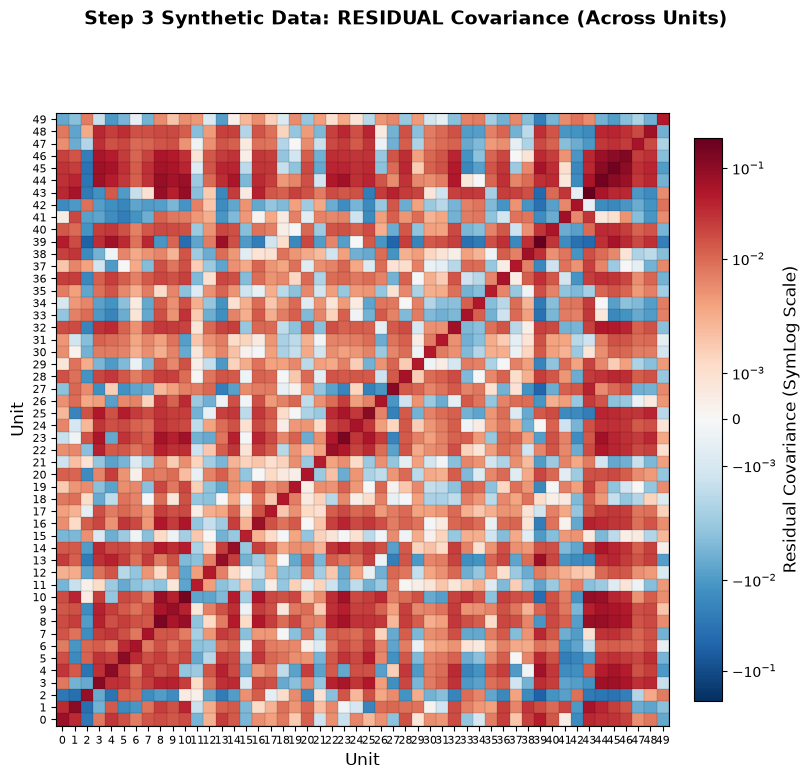

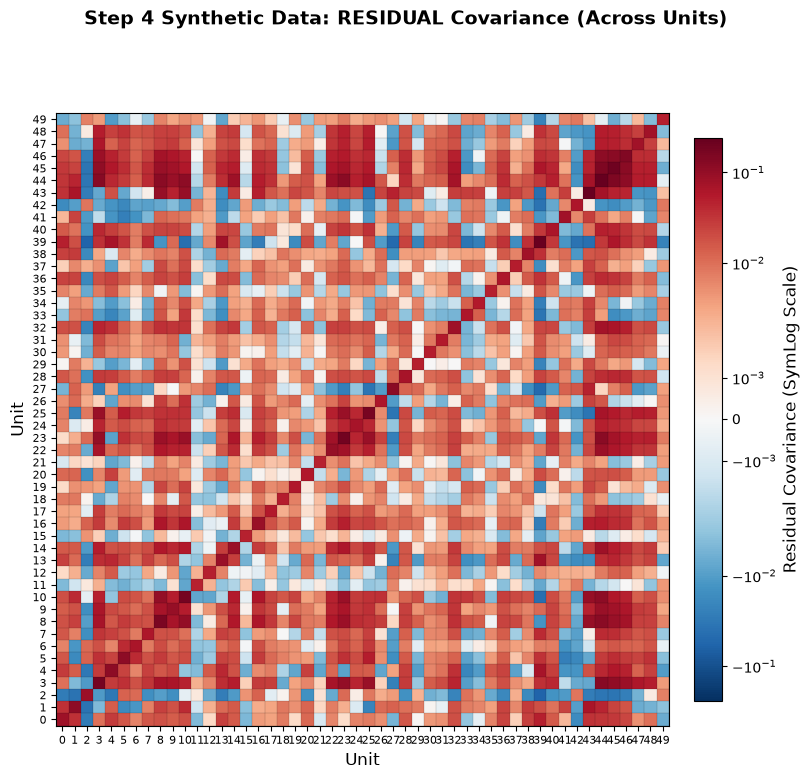

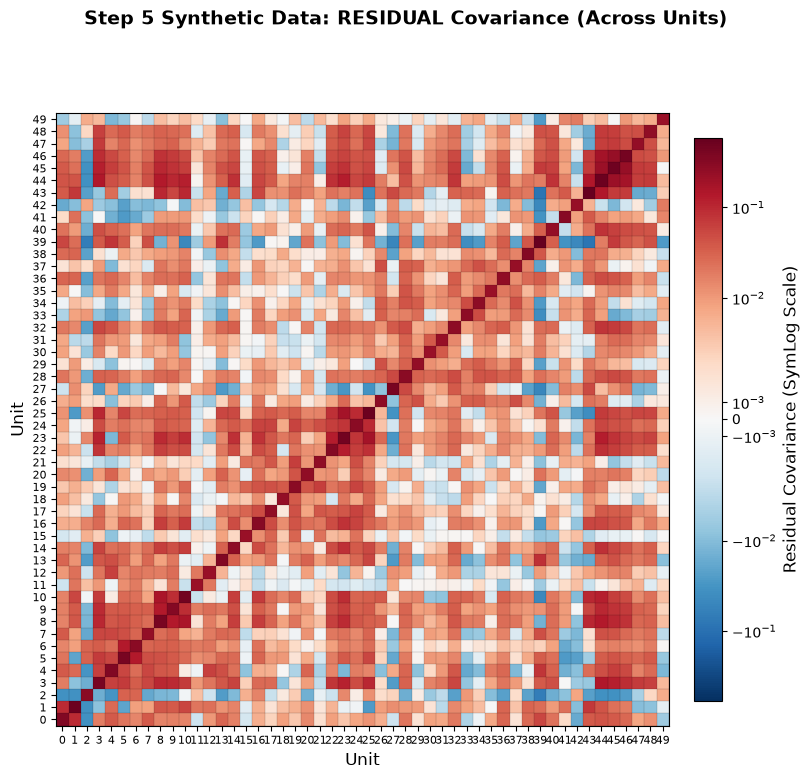

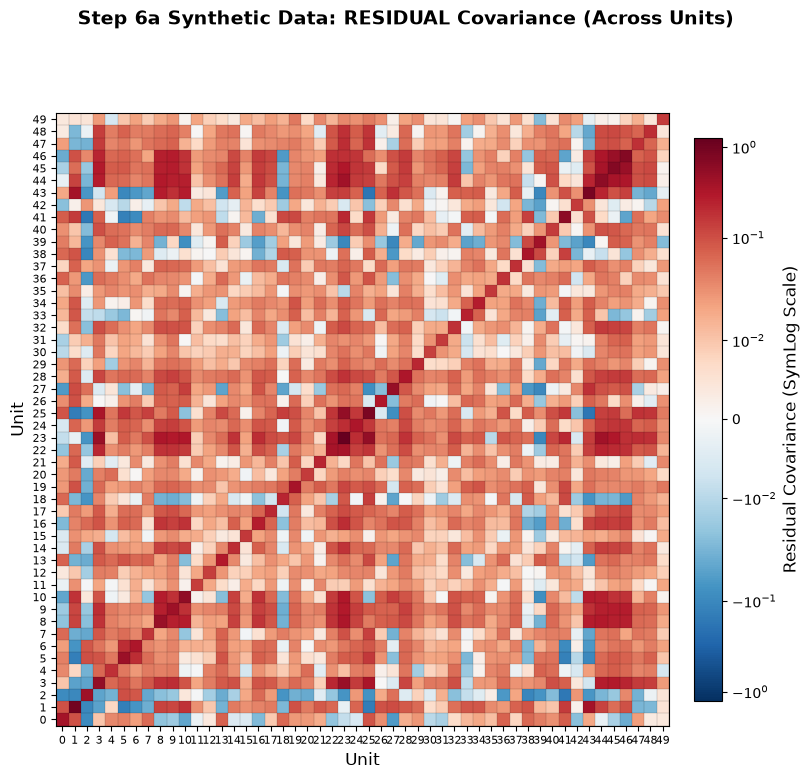

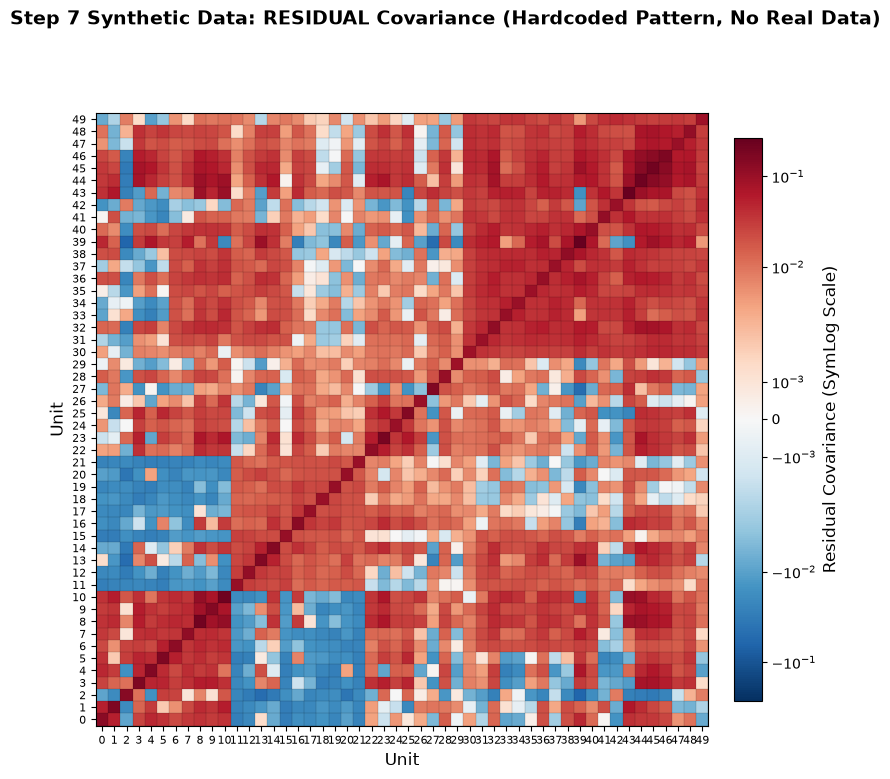

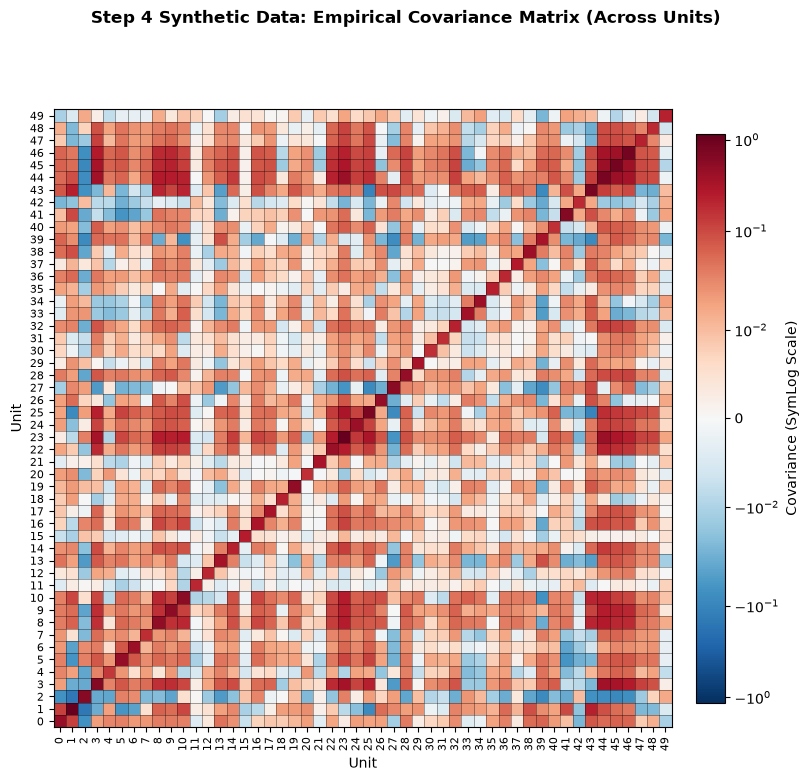

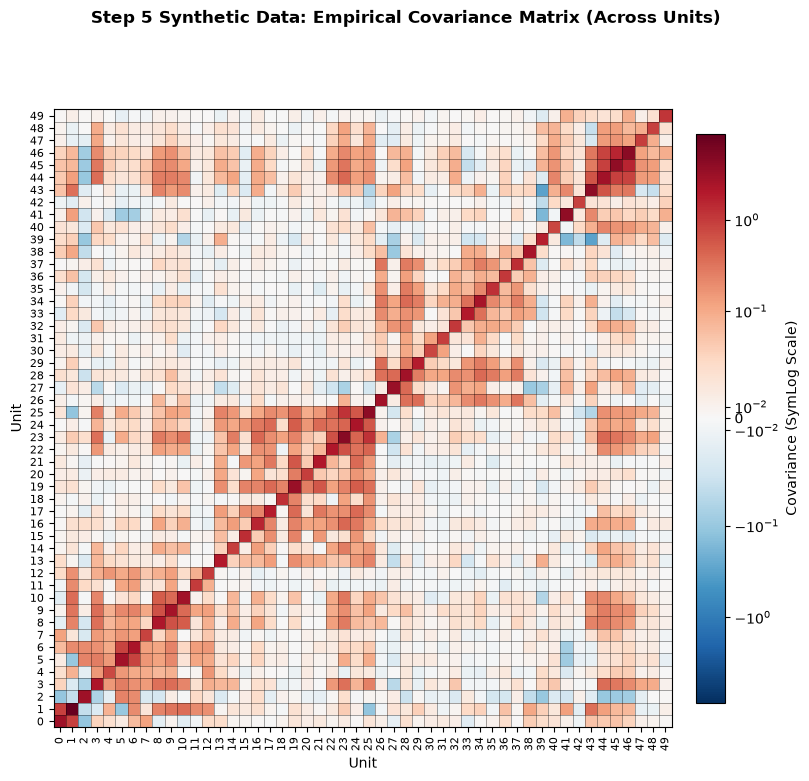

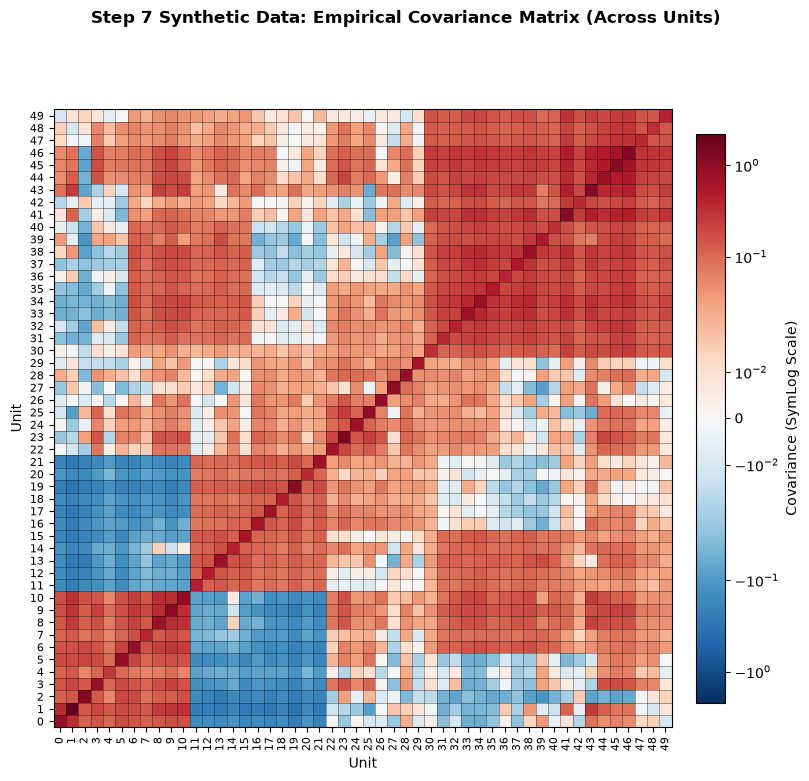

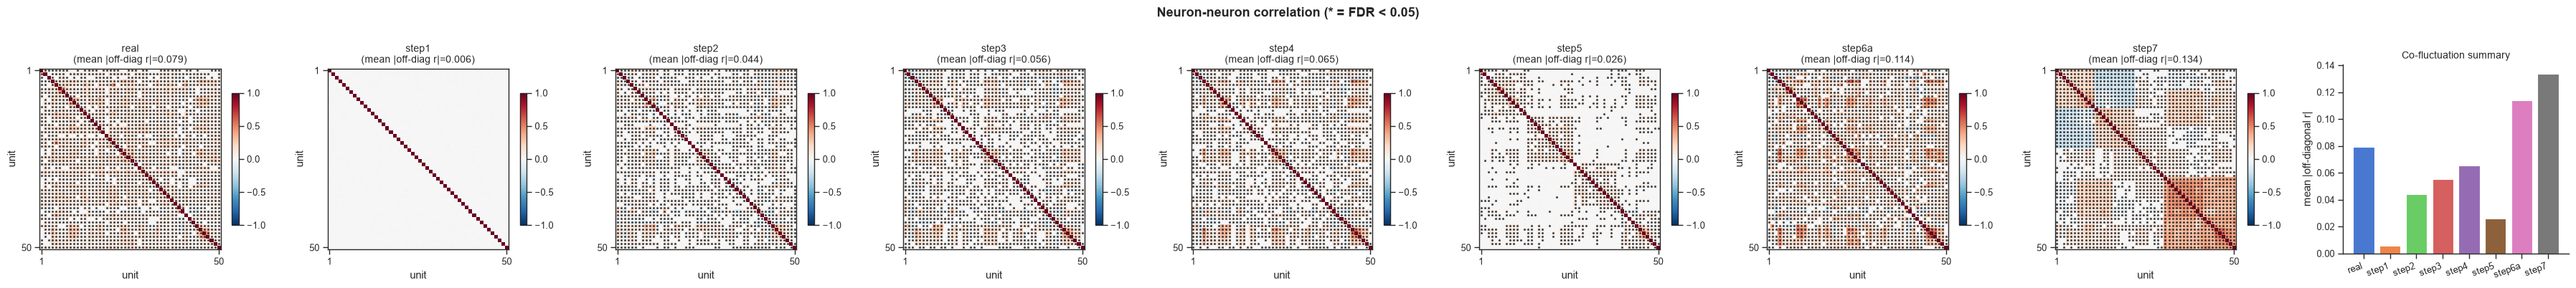

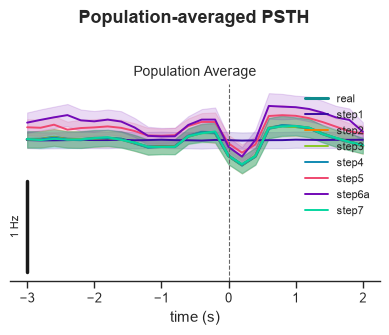

In [17]:
# =========================================================================
# Plotting & Visual Verification (Step 6a Focus)
# =========================================================================
# plot_firing_rate_histogram(Y, training_datasets['step6a'], test_label="step6a (deep mean shared noise)");
# plot_mean_variance_comparison(Y, training_datasets['step6a'], prep);

plot_residual_covariance(
    Y_synth=training_datasets['step3'], 
    lambda_hat=lambda_hat_3, 
    title="Step 3 Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit'
);

plot_residual_covariance(
    Y_synth=training_datasets['step4'], 
    lambda_hat=lambda_hat_4, 
    title="Step 4 Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit'
);

plot_residual_covariance(
    Y_synth=training_datasets['step5'], 
    lambda_hat=lambda_hat_4, 
    title="Step 5 Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit'
);

plot_residual_covariance(
    Y_synth=training_datasets['step6a'], 
    lambda_hat=lambda_hat_3, 
    title="Step 6a Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit'
);

# plot_residual_covariance(
#     Y_synth=_step7_Y_sorted,
#     lambda_hat=_step7_lhat_sorted,
#     title="Step 7 Synthetic Data: RESIDUAL Covariance (β-Factor, sorted by tuning cluster)",
#     mode='unit'
# )

plot_residual_covariance(
    Y_synth=training_datasets['step7'],
    lambda_hat=lambda_hat_3,
    title="Step 7 Synthetic Data: RESIDUAL Covariance (Hardcoded Pattern, No Real Data)",
    mode='unit'
);

plot_empirical_covariance_matrix(
    data=training_datasets['step4'], 
    title="Step 4 Synthetic Data: Empirical Covariance Matrix (Across Units)",
    mode='unit',
    show=True
);

plot_empirical_covariance_matrix(
    data=training_datasets['step5'], 
    title="Step 5 Synthetic Data: Empirical Covariance Matrix (Across Units)",
    mode='unit',
    show=True
);

plot_empirical_covariance_matrix(
    data=training_datasets['step7'], 
    title="Step 7 Synthetic Data: Empirical Covariance Matrix (Across Units)",
    mode='unit',
    show=True
);

plot_correlation_matrices(training_datasets, prep);
plot_population_psth(training_datasets, prep);


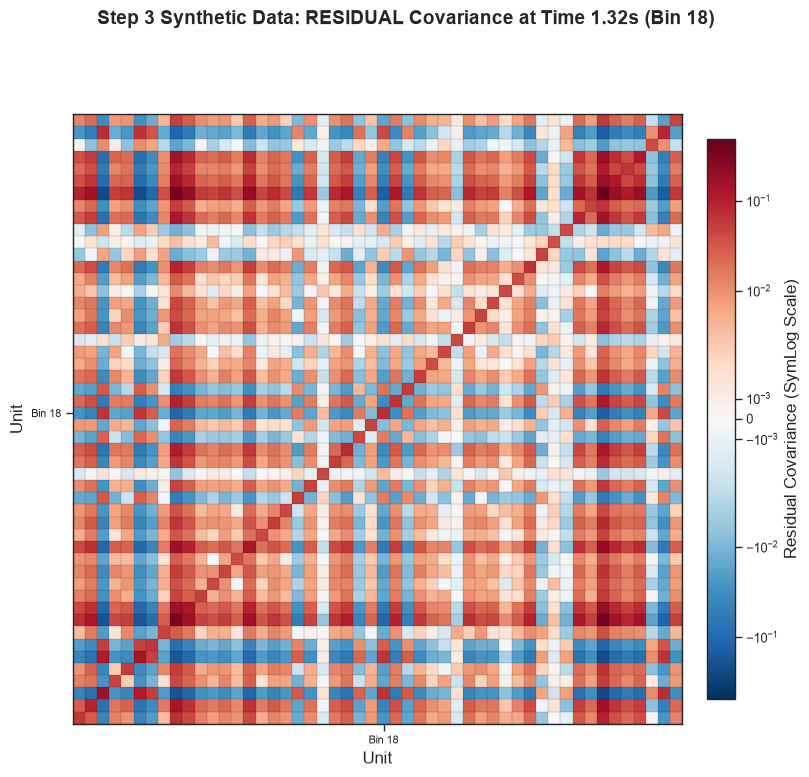

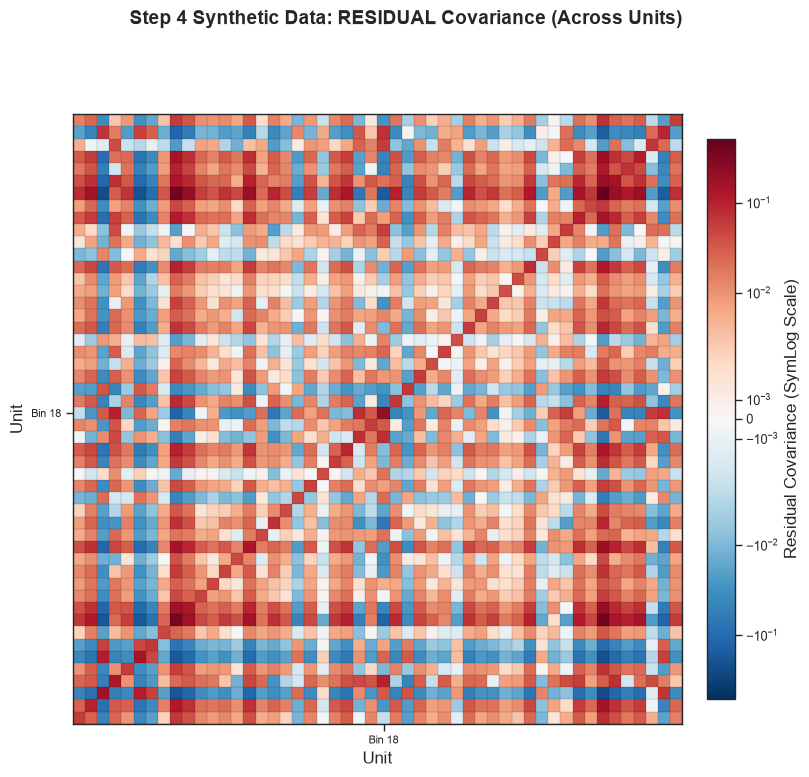

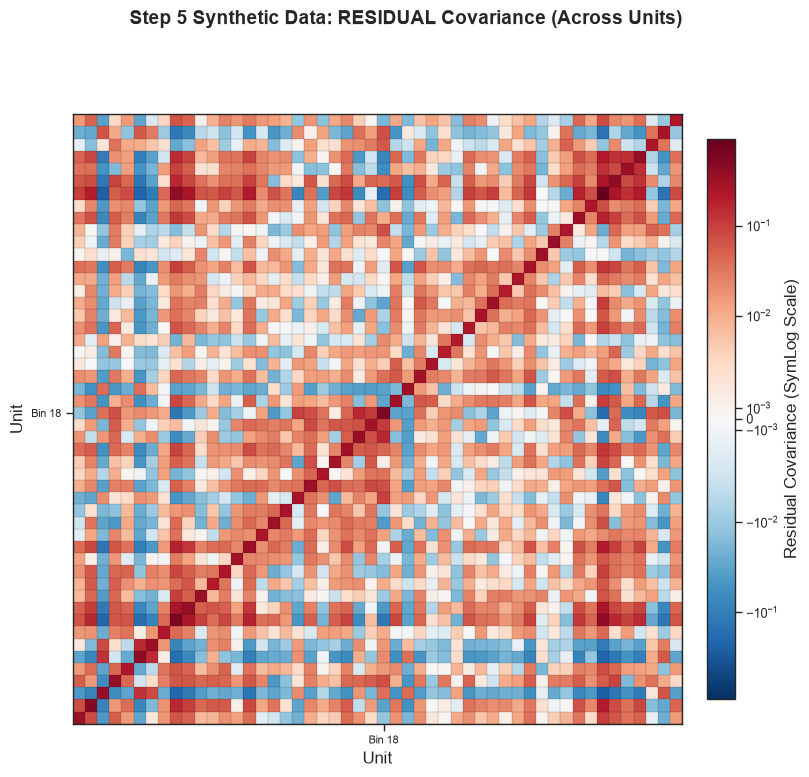

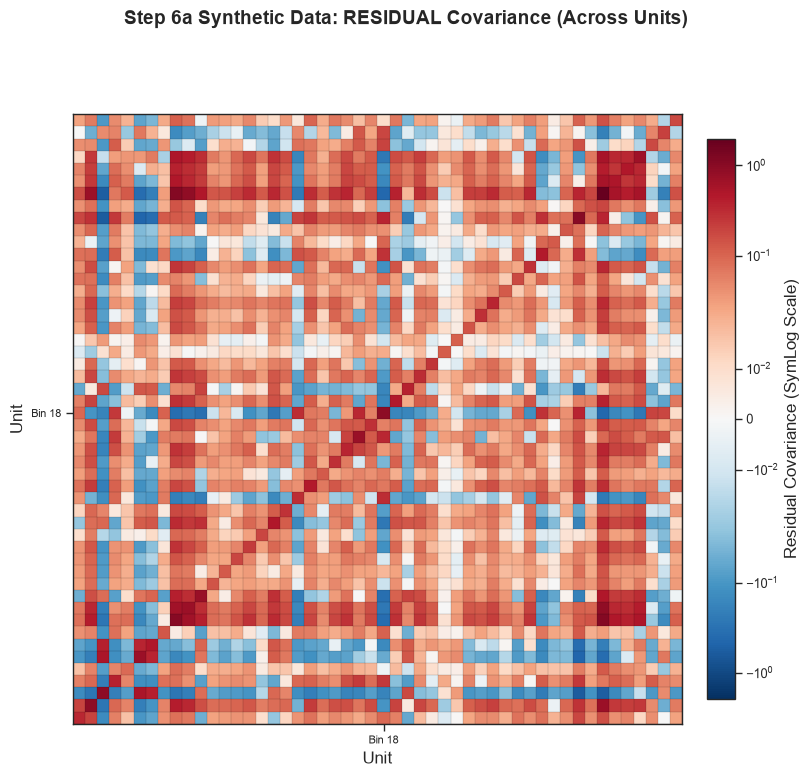

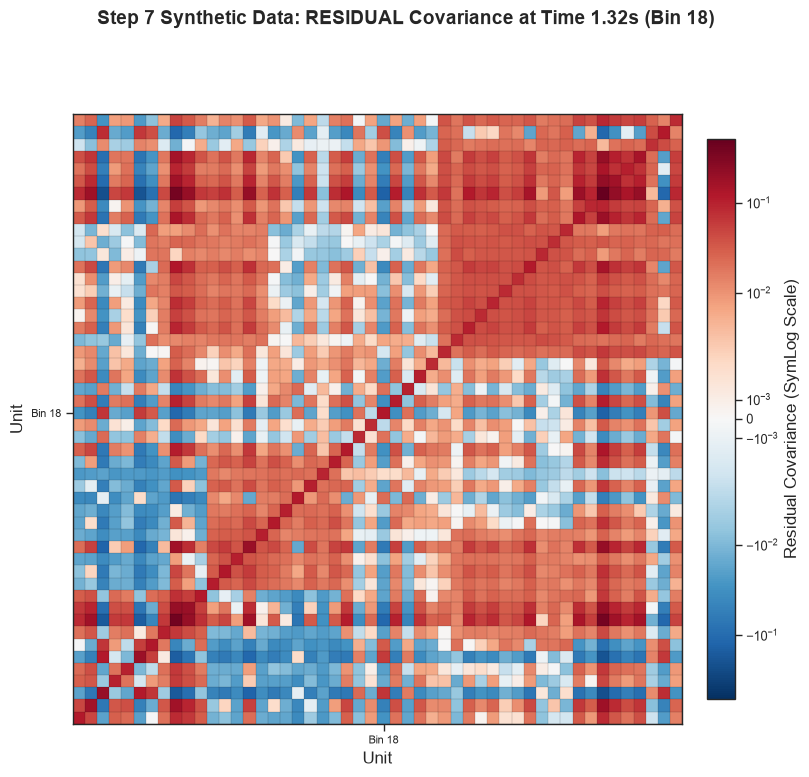

In [18]:
plot_residual_covariance(
    Y_synth=training_datasets['step3'],
    lambda_hat=lambda_hat_3, 
    title="Step 3 Synthetic Data: RESIDUAL Covariance at Time 1.32s (Bin 18)", 
    mode='unit',
    time_bin=18
)

plot_residual_covariance(
    Y_synth=training_datasets['step4'], 
    lambda_hat=lambda_hat_4, 
    title="Step 4 Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit',
    time_bin=18
);

plot_residual_covariance(
    Y_synth=training_datasets['step5'], 
    lambda_hat=lambda_hat_4, 
    title="Step 5 Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit',
    time_bin=18
);

plot_residual_covariance(
    Y_synth=training_datasets['step6a'], 
    lambda_hat=lambda_hat_3, 
    title="Step 6a Synthetic Data: RESIDUAL Covariance (Across Units)", 
    mode='unit',
    time_bin=18
);

plot_residual_covariance(
    Y_synth=training_datasets['step7'],
    lambda_hat=lambda_hat_3,
    title="Step 7 Synthetic Data: RESIDUAL Covariance at Time 1.32s (Bin 18)",
    mode='unit',
    time_bin=18
);

In [94]:
# Run the full training loop on Real, Step 3, Step 6a
allowed_vars_dict= {
        'step3': ['tslp', 'rew'],
        'step4': ['tslp', 'rew'],
        'step5': ['tslp', 'rew'],
        'step6a': ['tslp', 'rew'],
        'step7': ['tslp', 'rew']
}

df_history, df_units, df_seed_summary = run_model_comparisons(
    training_datasets=training_datasets,
    x_position_vars=x_position_vars,
    x_dense_vars=prep['X_dense_task'],
    x_sparse_vars=prep['X_sparse_task'],
    Conf=Conf,
    device=device,
    n_splits=10,
    force_retrain=False,
    use_multi_seed=False,
    allowed_vars_dict= allowed_vars_dict
)


Loading existing progress from CSVs...

Training on real
  [SKIPPED] Model: Zero / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Shared (All 10 folds already in CSV)
  [SKIPPED] Model: Conditional / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Conditional / Shared (All 10 folds already in CSV)

Training on step1
  [SKIPPED] Model: Zero / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Shared (All 10 folds already in CSV)
  [SKIPPED] Model: Conditional / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Conditional / Shared (All 10 folds already in CSV)

Training on step2
  [SKIPPED] Model: Zero / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 10 folds already in CSV)
  [SKIPPED] Model: Baseline / Shared (All 10 folds already in CSV)
  [SKIPPED] Model:

### SHAP Real

In [22]:
real_targets = ['tunp', 'tslp', 'rew_rate', 'rew_ratio', 'rew']

plot_shap_results(Conf, condition='real', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=real_targets)

# Fit GLM on ALL variables for real data
counts_real = prep['counts']
# Pass selected_vars=None to get ALL dense and sparse variables
X_d_real, X_s_real = filter_task_vars(prep, None)
print("Fitting GLM on Real data for Ground Truth using ALL variables...")
real_betas = fit_glm_per_unit_bin(counts_real, X_d_real, X_s_real, n_jobs=-1)

# Build the exact list of names in the exact order they appear in the GLM
# The design matrix concatenates X_dense, then X_sparse.
task_names = list(prep['task_var_names'])
dense_names = [task_names[i] for i in prep['dense_indices']]
sparse_names = [task_names[i] for i in prep['sparse_indices']]
all_names = dense_names + sparse_names

plot_pearson_shap_results(Conf, condition='real', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names, target_vars=real_targets,
                          ground_truth_betas=real_betas, ground_truth_var_names=all_names)



Plotting Spatiotemporal SHAP Analysis for real - Conditional / Identity
Loaded SHAP tensors (shape: (880, 11, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tunp', 'tslp', 'rew_rate', 'rew_ratio', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/real/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [236  72 121 493 469] -> ./figures_new/SHAP_Plots/real/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/real/Conditional_Identity/
Fitting GLM on Real data for Ground Truth using ALL variables...
Fitting 1300 Poisson GLMs  (50 units x 26 bins) ...
  betas shape: (50, 26, 8)  (neurons, bins, V+1)

Pearson SHAP, Global Mean, and Ground Truth Matrix for real - Conditional / Identity
  Computing metrics for 'tunp' (var_idx=4)...
  Computing metrics for 'tslp' (var_idx=5).

### SHAP Step3

In [26]:
step3_targets = ['tslp', 'rew']

plot_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step3_targets)

plot_pearson_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step3=betas_3, target_vars=step3_targets)



Plotting Spatiotemporal SHAP Analysis for step3 - Conditional / Identity
Loaded SHAP tensors (shape: (880, 6, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/step3/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [ 58 571 377 667 303] -> ./figures_new/SHAP_Plots/step3/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/step3/Conditional_Identity/

Pearson SHAP, Global Mean, and Ground Truth Matrix for step3 - Conditional / Identity
  Computing metrics for 'tslp' (var_idx=4)...
  Computing metrics for 'rew' (var_idx=5)...

All plots saved to: ./figures_new/SHAP_Plots\step3\Conditional_Identity


In [27]:
step4_targets = ['tslp', 'rew', 'tunp']

plot_shap_results(Conf, condition='step4', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step4_targets)

plot_pearson_shap_results(Conf, condition='step4', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step4=betas_4, target_vars=step4_targets)



Plotting Spatiotemporal SHAP Analysis for step4 - Conditional / Identity
Loaded SHAP tensors (shape: (880, 6, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/step4/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [570 464 244 681 630] -> ./figures_new/SHAP_Plots/step4/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/step4/Conditional_Identity/

Pearson SHAP, Global Mean, and Ground Truth Matrix for step4 - Conditional / Identity
  Computing metrics for 'tslp' (var_idx=4)...
  Computing metrics for 'rew' (var_idx=5)...

All plots saved to: ./figures_new/SHAP_Plots\step4\Conditional_Identity


### SHAP Step5


In [28]:
# For step5 you need the FA object — re-run it once to get fa.components_:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import MinMaxScaler
Y_true = prep['counts']
T, N, K = Y_true.shape
Y_flat  = Y_true.transpose(0,2,1).reshape(T*K, N)
lam_flat = lambda_hat_4.transpose(0,2,1).reshape(T*K, N)
residuals = (Y_flat - lam_flat) / np.sqrt(lam_flat + 1e-8)
fa = FactorAnalysis(n_components=5, random_state=Conf.seed)
fa.fit(residuals)

step5_targets = ['rew', 'tslp', 'tunp']

plot_shap_results(Conf, condition='step5', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step5_targets)

plot_pearson_shap_results(Conf, condition='step5', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step4=betas_4, target_vars=step5_targets)



Plotting Spatiotemporal SHAP Analysis for step5 - Conditional / Identity
Loaded SHAP tensors (shape: (880, 6, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/step5/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [418 269 467 245 420] -> ./figures_new/SHAP_Plots/step5/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/step5/Conditional_Identity/

Pearson SHAP, Global Mean, and Ground Truth Matrix for step5 - Conditional / Identity
  Computing metrics for 'tslp' (var_idx=4)...
  Computing metrics for 'rew' (var_idx=5)...

All plots saved to: ./figures_new/SHAP_Plots\step5\Conditional_Identity


### SHAP Step6a

In [29]:
step6a_targets = ['tslp', 'rew']

plot_shap_results(Conf, condition='step6a', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step6a_targets)

plot_pearson_shap_results(Conf, condition='step6a', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step3=betas_3, target_vars=step6a_targets)



Plotting Spatiotemporal SHAP Analysis for step6a - Conditional / Identity
Loaded SHAP tensors (shape: (880, 6, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/step6a/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [  7 375 545 207 139] -> ./figures_new/SHAP_Plots/step6a/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/step6a/Conditional_Identity/

Pearson SHAP, Global Mean, and Ground Truth Matrix for step6a - Conditional / Identity
  Computing metrics for 'tslp' (var_idx=4)...
  Computing metrics for 'rew' (var_idx=5)...

All plots saved to: ./figures_new/SHAP_Plots\step6a\Conditional_Identity


In [30]:
step7_targets = ['tslp', 'rew']

plot_shap_results(Conf, condition='step7', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step7_targets)

plot_pearson_shap_results(Conf, condition='step7', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step3=betas_3, target_vars=step7_targets)



Plotting Spatiotemporal SHAP Analysis for step7 - Conditional / Identity
Loaded SHAP tensors (shape: (880, 6, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./figures_new/SHAP_Plots/step7/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [450 495 811 764 387] -> ./figures_new/SHAP_Plots/step7/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./figures_new/SHAP_Plots/step7/Conditional_Identity/

Pearson SHAP, Global Mean, and Ground Truth Matrix for step7 - Conditional / Identity
  Computing metrics for 'tslp' (var_idx=4)...
  Computing metrics for 'rew' (var_idx=5)...

All plots saved to: ./figures_new/SHAP_Plots\step7\Conditional_Identity


In [95]:
# @title Plotting Usages 
import os
import ast
import torch
import numpy as np
import copy
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

if 'df_history' in locals() and 'df_units' in locals() and not df_units.empty:
    kf = KFold(n_splits=10, shuffle=False)
    
    # Check for allowed_vars_dict from training
    allowed_vars_map = {
        'step3': ['tslp', 'rew'],
        'step4': ['tslp', 'rew'],
        'step5': ['tslp', 'rew'],
        'step6a': ['tslp', 'rew'],
        'step7': ['tslp', 'rew']
    }
    if 'allowed_vars_dict' in globals() and allowed_vars_dict:
        allowed_vars_map.update(allowed_vars_dict)
    
    for condition in df_units['condition'].unique():
        print(f"\n{'='*60}\nGenerating plots for Condition: {condition}\n{'='*60}")
        
        # Data and Fold settings
        target_fold = 0
        cond_hist = df_history[df_history['condition'] == condition]
        cond_units = df_units[df_units['condition'] == condition]
        
        # Setup specific output directories for this step
        dir_base = f"{FIGURES}{condition}/model"
        # Generate directories based on exact model labels
        for model_label in cond_units['model_label'].unique():
            m_dir = model_label.lower().replace(' / ', '/')
            os.makedirs(f"{dir_base}/{m_dir}/prediction/", exist_ok=True)
            if 'shared' in m_dir:
                os.makedirs(f"{dir_base}/{m_dir}/parameter/", exist_ok=True)
            if 'identity' in m_dir and 'conditional' in m_dir:
                os.makedirs(f"{dir_base}/{m_dir}/shap/population/mean-absolute-shap/", exist_ok=True)
        os.makedirs(f"{dir_base}/comparison/", exist_ok=True)

        # ---------------------------------------------------------
        # 1. Training History Plots
        # ---------------------------------------------------------
        for model_label in cond_hist['model'].unique():
            model_hist = cond_hist[cond_hist['model'] == model_label]
            
            # Map model_label to directory name natively
            m_dir = model_label.lower().replace(' / ', '/')
                
            # Plot the Mean version
            plot_training_history(
                df_hist=model_hist,
                title=f"{model_label}: Training History ({condition}) [Mean]",
                mode="mean",
                file_name="training-history-mean",
                file_path=f"{dir_base}/{m_dir}/",
                show=False
            )
            
            # Plot the Best Fold version
            plot_training_history(
                df_hist=model_hist,
                title=f"{model_label}: Training History ({condition}) [Best Fold]",
                mode="best",
                file_name="training-history-best",
                file_path=f"{dir_base}/{m_dir}/",
                show=False
            )

            
        # ---------------------------------------------------------
        # 2. Metric Comparisons
        # ---------------------------------------------------------
        cond_units_agg = cond_units.groupby(['unit', 'model_label'], as_index=False)[['train_pearson', 'pearson', 'train_r2', 'r2', 'train_mse', 'mse']].mean()
        
        baseline_df = cond_units_agg[cond_units_agg['model_label'] == 'Baseline / Shared'].sort_values('unit')
        mean_df = cond_units_agg[cond_units_agg['model_label'] == 'Conditional / Identity'].sort_values('unit')
        mean_cov_df = cond_units_agg[cond_units_agg['model_label'] == 'Conditional / Shared'].sort_values('unit')
        
        # Baseline unit metrics
        if not baseline_df.empty:
            plot_train_valid_metrics_comparison(
                correlations_train=baseline_df['train_pearson'].values,
                correlations_valid=baseline_df['pearson'].values,
                r2s_train=baseline_df['train_r2'].values,
                r2s_valid=baseline_df['r2'].values,
                mses_train=baseline_df['train_mse'].values,
                mses_valid=baseline_df['mse'].values,
                title="Baseline / Shared Model: Per-Unit Training and Validation Metrics",
                filename="metrics",
                filepath=f"{dir_base}/baseline/shared/",
                bins=50,
                show=False
            )
            
        # Mean unit metrics
        if not mean_df.empty:
            plot_train_valid_metrics_comparison(
                correlations_train=mean_df['train_pearson'].values,
                correlations_valid=mean_df['pearson'].values,
                r2s_train=mean_df['train_r2'].values,
                r2s_valid=mean_df['r2'].values,
                mses_train=mean_df['train_mse'].values,
                mses_valid=mean_df['mse'].values,
                title="Conditional / Identity Model: Per-Unit Training and Validation Metrics",
                filename="metrics",
                filepath=f"{dir_base}/conditional/identity/",
                bins=50,
                show=False
            )
            
        # Mean-Cov unit metrics
        if not mean_cov_df.empty:
            plot_train_valid_metrics_comparison(
                correlations_train=mean_cov_df['train_pearson'].values,
                correlations_valid=mean_cov_df['pearson'].values,
                r2s_train=mean_cov_df['train_r2'].values,
                r2s_valid=mean_cov_df['r2'].values,
                mses_train=mean_cov_df['train_mse'].values,
                mses_valid=mean_cov_df['mse'].values,
                title="Conditional / Shared Model: Per-Unit Training and Validation Metrics",
                filename="metrics",
                filepath=f"{dir_base}/conditional/shared/",
                bins=50,
                show=False
            )
            
        # Comparison (Baseline vs Mean)
        if not baseline_df.empty and not mean_df.empty:
            plot_model_metrics_comparison(
                correlations_x_train=baseline_df['train_pearson'].values,
                correlations_x_valid=baseline_df['pearson'].values,
                r2s_x_train=baseline_df['train_r2'].values,
                r2s_x_valid=baseline_df['r2'].values,
                mses_x_train=baseline_df['train_mse'].values,
                mses_x_valid=baseline_df['mse'].values,
                correlations_y_train=mean_df['train_pearson'].values,
                correlations_y_valid=mean_df['pearson'].values,
                r2s_y_train=mean_df['train_r2'].values,
                r2s_y_valid=mean_df['r2'].values,
                mses_y_train=mean_df['train_mse'].values,
                mses_y_valid=mean_df['mse'].values,
                x_label="Baseline / Shared",
                y_label="Conditional / Identity",
                title="Baseline / Shared vs Conditional / Identity Model Comparison",
                file_name="baseline-vs-mean-metrics",
                file_path=f"{dir_base}/comparison/",
                bins=50,
                show=False
            )
            
        # Comparison (Mean vs Mean-Cov)
        if not mean_df.empty and not mean_cov_df.empty:
            plot_model_metrics_comparison(
                correlations_x_train=mean_df['train_pearson'].values,
                correlations_x_valid=mean_df['pearson'].values,
                r2s_x_train=mean_df['train_r2'].values,
                r2s_x_valid=mean_df['r2'].values,
                mses_x_train=mean_df['train_mse'].values,
                mses_x_valid=mean_df['mse'].values,
                correlations_y_train=mean_cov_df['train_pearson'].values,
                correlations_y_valid=mean_cov_df['pearson'].values,
                r2s_y_train=mean_cov_df['train_r2'].values,
                r2s_y_valid=mean_cov_df['r2'].values,
                mses_y_train=mean_cov_df['train_mse'].values,
                mses_y_valid=mean_cov_df['mse'].values,
                x_label="Conditional / Identity",
                y_label="Conditional / Shared",
                title="Conditional / Identity vs Conditional / Shared Model Comparison",
                file_name="mean-vs-mean-cov-metrics",
                file_path=f"{dir_base}/comparison/",
                bins=50,
                show=False
            )
            
        # Helper to get arrays of folds per unit
        def _get_trial_arrays(model_label, col):
            def _parse_and_concat(series):
                arrs = []
                for val in series.dropna():
                    if isinstance(val, str):
                        try:
                            arrs.extend(ast.literal_eval(val))
                        except Exception:
                            pass
                    elif isinstance(val, (list, np.ndarray)):
                        arrs.extend(val)
                return np.array(arrs)
            sub = cond_units[cond_units['model_label'] == model_label]
            if sub.empty or col not in sub.columns:
                return []
            return sub.sort_values(['unit', 'fold']).groupby('unit')[col].apply(_parse_and_concat).values
        
        # Improvement Plot (Baseline vs Mean)
        if not baseline_df.empty and not mean_df.empty:
            try:
                plot_model_metric_improvement(
                    mse_trial_baseline=_get_trial_arrays('Baseline / Shared', 'mse_trials'),
                    mse_trial_model=_get_trial_arrays('Conditional / Identity', 'mse_trials'),
                    corr_trial_baseline=_get_trial_arrays('Baseline / Shared', 'pearson_trials'),
                    corr_trial_model=_get_trial_arrays('Conditional / Identity', 'pearson_trials'),
                    r2_trial_baseline=_get_trial_arrays('Baseline / Shared', 'r2_trials'),
                    r2_trial_model=_get_trial_arrays('Conditional / Identity', 'r2_trials'),
                    title="Baseline / Shared vs Conditional / Identity Model Significant Improvements",
                    file_name="baseline-vs-mean-improvement",
                    file_path=f"{dir_base}/comparison/",
                    show=False
                )
            except Exception as e:
                print(f"Warning: Could not plot baseline-vs-mean improvement: {e}")
        
        # Improvement Plot (Mean vs Mean-Cov)
        if not mean_df.empty and not mean_cov_df.empty:
            try:
                plot_model_metric_improvement(
                    mse_trial_baseline=_get_trial_arrays('Conditional / Identity', 'mse_trials'),
                    mse_trial_model=_get_trial_arrays('Conditional / Shared', 'mse_trials'),
                    corr_trial_baseline=_get_trial_arrays('Conditional / Identity', 'pearson_trials'),
                    corr_trial_model=_get_trial_arrays('Conditional / Shared', 'pearson_trials'),
                    r2_trial_baseline=_get_trial_arrays('Conditional / Identity', 'r2_trials'),
                    r2_trial_model=_get_trial_arrays('Conditional / Shared', 'r2_trials'),
                    title="Conditional / Identity vs Conditional / Shared Model Significant Improvements",
                    file_name="mean-vs-mean-cov-improvement",
                    file_path=f"{dir_base}/comparison/",
                    show=False
                )
            except Exception as e:
                print(f"Warning: Could not plot mean-vs-mean-cov improvement: {e}")
            
        # 3. Covariance Matrices & Predictions (Fold 0)
        # ---------------------------------------------------------
        try:
            if condition not in training_datasets:
                print(f"Skipping prediction plots: {condition} not found in training_datasets.")
                continue

            Y_current = training_datasets[condition]
            
            # Y_current shape is (n_trials, n_units, n_bins)
            n_trials = Y_current.shape[0]
            n_units = Y_current.shape[1]
            n_bins = Y_current.shape[2]
            
            unit_indices = [min(u, n_units - 1) for u in [1, 23, 46]]
            trial_indices = [min(t, n_trials - 1) for t in [11, 23]]
            bin_times = np.linspace(-3, 3, n_bins)
            unit_names = [str(i) for i in range(n_units)]
            
            models_to_evaluate = [
                ('Zero / Identity', 'zero', 'identity', 'zero/identity', 'Zero Model'),
                ('Baseline / Identity', 'baseline', 'identity', 'baseline/identity', 'Baseline/Identity Model'),
                ('Baseline / Shared', 'baseline', 'shared', 'baseline/shared', 'Baseline/Shared Model'),
                ('Conditional / Identity', 'conditional', 'identity', 'conditional/identity', 'Conditional/Identity Model'),
                ('Conditional / Shared', 'conditional', 'shared', 'conditional/shared', 'Conditional/Shared Model')
            ]
            
            # Apply identical feature filtering as used during training
            cur_x_pos = x_position_vars.copy()
            cur_x_den = x_dense_vars.copy()
            cur_x_spa = x_sparse_vars.copy()
            
            allowed_vars = allowed_vars_map.get(condition, None)
            if allowed_vars is not None:
                t_names = list(task_var_names) if 'task_var_names' in globals() else list(prep['task_var_names'])
                dense_idx_list = list(dense) if 'dense' in globals() else list(prep.get('dense_indices', []))
                sparse_idx_list = list(sparse) if 'sparse' in globals() else list(prep.get('sparse_indices', []))
                
                new_x_den_cols = [col_idx for col_idx, orig_idx in enumerate(dense_idx_list) if t_names[orig_idx] in allowed_vars]
                new_x_spa_cols = [col_idx for col_idx, orig_idx in enumerate(sparse_idx_list) if t_names[orig_idx] in allowed_vars]
                
                cur_x_den = cur_x_den[:, new_x_den_cols]
                cur_x_spa = cur_x_spa[:, new_x_spa_cols]
            
            current_Conf = copy.deepcopy(Conf)
            if not hasattr(current_Conf, 'data') or current_Conf.data is None:
                current_Conf.data = DotDict()
            
            current_Conf.data.n_position_vars = cur_x_pos.shape[1]
            current_Conf.data.n_dense_vars = cur_x_den.shape[1]
            current_Conf.data.n_sparse_vars = cur_x_spa.shape[1]
            current_Conf.data.n_vars = current_Conf.data.n_position_vars + current_Conf.data.n_dense_vars + current_Conf.data.n_sparse_vars
            current_Conf.data.n_units = n_units
            current_Conf.data.n_bins = n_bins
            
            for m_label, m_mean, m_cov, m_dir, title_prefix in models_to_evaluate:
                # Use the last fold (max fold) for this model
                best_fold = 0
                if 'df_history' in globals() and not globals()['df_history'].empty:
                    df_h = globals()['df_history']
                    cond_df = df_h[(df_h['condition'] == condition) & (df_h['model'] == m_label)]
                    if not cond_df.empty:
                        best_fold = int(cond_df['fold'].max())
                        
                ckpt = f"{RESULTS}ckpt_{condition}_{m_label.replace(' / ', '_')}_fold{best_fold}.pt"
                if not os.path.exists(ckpt):
                    continue
                    
                # 1. Reconstruct the training split for the best fold to get the correct standardizing statistics
                random_seed = getattr(current_Conf, 'seed', 42)
                kf_train = KFold(n_splits=10, shuffle=True, random_state=random_seed)
                # advance to the best_fold
                gen = kf_train.split(np.arange(Y_current.shape[0]))
                for _ in range(best_fold + 1):
                    train_idx, valid_idx = next(gen)
                    
                # Calculate normalization statistics using ONLY the training trials from the best fold
                pos_mean, pos_std = cur_x_pos[train_idx].mean(axis=0, keepdims=True), cur_x_pos[train_idx].std(axis=0, keepdims=True)
                den_mean, den_std = cur_x_den[train_idx].mean(axis=0, keepdims=True), cur_x_den[train_idx].std(axis=0, keepdims=True)
                
                # Apply normalization to the FULL dataset
                x_pos_all = (cur_x_pos - pos_mean) / (pos_std + 1e-8)
                x_den_all = (cur_x_den - den_mean) / (den_std + 1e-8)
                x_spa_all = cur_x_spa
                
                # Find Y mean for Anscombe centering using ONLY training trials
                Y_train_tensor = torch.tensor(Y_current[train_idx], dtype=torch.float32, device=device).transpose(1, 2)
                Y_train_mean = torch.mean(Anscombe().forward(Y_train_tensor), dim=(0, 1), keepdim=True)
                
                # Create a loader for ALL trials
                full_ds = NeuralDataset(x_pos_all, x_den_all, x_spa_all, Y_current, Y_train_mean)
                full_loader = DataLoader(full_ds, batch_size=current_Conf.training.batch_size, shuffle=False)
                
                # Load the best model
                mod = LitModel(current_Conf, mean_model=m_mean, cov_model=m_cov)
                mod.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
                mod.to(device)
                
                # Predict on ALL trials (Y_val and Y_hat will be shape [Total_Trials, T, N])
                Y_val, Y_hat = predict_loader(current_Conf, mod, full_loader, Y_train_mean, 'all')
                
                # --- PREDICTION PLOTS ---
                for trial_idx in trial_indices:
                    for unit_idx in unit_indices:
                        if trial_idx < Y_val.shape[0] and unit_idx < Y_val.shape[2]:
                            plot_prediction(
                                Y=Y_val, Y_hat=Y_hat, trial_idx=trial_idx, unit_idx=unit_idx,
                                bin_times=bin_times, title=f"{title_prefix}: Unit {unit_names[unit_idx]}, trial {trial_idx} prediction",
                                filename=f"trial_{trial_idx}_unit_{unit_idx}",
                                filepath=f"{dir_base}/{m_dir}/prediction/", show=False
                            )
                        else:
                            print(f"Skipping plot for {m_label}: Trial {trial_idx} or Unit {unit_idx} out of bounds (Dataset size: {Y_val.shape[0]} trials, {Y_val.shape[2]} units)")
                            
                # --- PYTORCH PARAMETER PLOTS ---
                if 'Shared' in m_label:
                    print(f"    Generating PyTorch parameter plots (Covariance matrices) for {m_label} (Last Fold: {best_fold})...")
                    
                    pre_model = LitModel(current_Conf, mean_model=m_mean, cov_model=m_cov).to(device)
                    os.makedirs(f"{dir_base}/{m_dir}/parameter/", exist_ok=True)
                    
                    # PRE TRAINING
                    plot_cov_loading_matrix(mean_cov_lit_model=pre_model, title=f"{title_prefix} Before Training: Latent Covariance Loadings",
                                            file_name="latent-covariance-loadings-pre", file_path=f"{dir_base}/{m_dir}/parameter/",
                                            bin_times=bin_times,
                                            vmin=-pre_model.full_model.cov_model.lambda_matrix.detach().abs().max().item(),
                                            vmax=pre_model.full_model.cov_model.lambda_matrix.detach().abs().max().item(), show=False)
                    
                    if hasattr(pre_model.full_model.cov_model, 'noise'):
                        plot_cov_noise(mean_cov_lit_model=pre_model, title=f"{title_prefix} Before Training: Noise Variance",
                                   file_name="noise-variance-pre", file_path=f"{dir_base}/{m_dir}/parameter/",
                                   bin_times=bin_times, unit_names=unit_names,
                                   vmax=torch.sigmoid(pre_model.full_model.cov_model.noise).detach().max().item(), show=False)
                                   
                    if hasattr(pre_model.full_model.cov_model, 'length_scales'):
                        plot_cov_length_scales(mean_cov_lit_model=pre_model, title=f"{title_prefix} Before Training: Latent Length Scales",
                                           file_name="latent-length-scales-pre", file_path=f"{dir_base}/{m_dir}/parameter/",
                                           ymax=torch.nn.functional.softplus(pre_model.full_model.cov_model.length_scales).detach().max().item(), show=False)
                                           
                    lambda_matrix_pre = pre_model.full_model.cov_model.lambda_matrix.unsqueeze(0)
                    cov_tensor_pre = pre_model.full_model.cov_model.build_covariance_matrix(lambda_matrix_pre)
                    cov_matrix_pre = (cov_tensor_pre @ cov_tensor_pre.transpose(-1, -2)).squeeze(0).detach().cpu().numpy()
                    
                    for time_indices, time_name in zip([None, np.arange(15, 21), [18]], ["all", "15-20", "18"]):
                        plot_covariance_matrix(mean_cov_lit_model=pre_model, title=f"{title_prefix} Before Training: Covariance Matrix",
                                               file_name=f"covariance-matrix-pre-{time_name}", file_path=f"{dir_base}/{m_dir}/parameter/",
                                               time_indices=time_indices, bin_times=bin_times,
                                               vmin=-np.max(np.abs(cov_matrix_pre)), vmax=np.max(np.abs(cov_matrix_pre)), show=False)

                    # POST TRAINING
                    plot_cov_loading_matrix(mean_cov_lit_model=mod, title=f"{title_prefix} After Training: Latent Covariance Loadings",
                                            file_name="latent-covariance-loadings", file_path=f"{dir_base}/{m_dir}/parameter/",
                                            bin_times=bin_times,
                                            vmin=-mod.full_model.cov_model.lambda_matrix.detach().abs().max().item(),
                                            vmax=mod.full_model.cov_model.lambda_matrix.detach().abs().max().item(), show=False)
                    
                    if hasattr(pre_model.full_model.cov_model, 'noise'):
                        plot_cov_noise(mean_cov_lit_model=mod, title=f"{title_prefix} After Training: Noise Variance",
                                   file_name="noise-variance", file_path=f"{dir_base}/{m_dir}/parameter/",
                                   bin_times=bin_times, unit_names=unit_names,
                                   vmax=torch.sigmoid(mod.full_model.cov_model.noise).detach().max().item(), show=False)
                                   
                    if hasattr(pre_model.full_model.cov_model, 'length_scales'):
                        plot_cov_length_scales(mean_cov_lit_model=mod, title=f"{title_prefix} After Training: Latent Length Scales",
                                           file_name="latent-length-scales", file_path=f"{dir_base}/{m_dir}/parameter/",
                                           ymax=torch.nn.functional.softplus(mod.full_model.cov_model.length_scales).detach().max().item(), show=False)
                                           
                    lambda_matrix_post = mod.full_model.cov_model.lambda_matrix.unsqueeze(0)
                    cov_tensor_post = mod.full_model.cov_model.build_covariance_matrix(lambda_matrix_post)
                    cov_matrix_post = (cov_tensor_post @ cov_tensor_post.transpose(-1, -2)).squeeze(0).detach().cpu().numpy()
                    
                    for time_indices, time_name in zip([None, np.arange(15, 21), [18]], ["all", "15-20", "18"]):
                        plot_covariance_matrix(mean_cov_lit_model=mod, title=f"{title_prefix} After Training: Covariance Matrix",
                                               file_name=f"covariance-matrix-{time_name}", file_path=f"{dir_base}/{m_dir}/parameter/",
                                               time_indices=time_indices, bin_times=bin_times,
                                               vmin=-np.max(np.abs(cov_matrix_post)), vmax=np.max(np.abs(cov_matrix_post)), show=False)
        except Exception as e:
            import traceback
            traceback.print_exc()
            print(f"Could not generate prediction plots: {e}")



Generating plots for Condition: real
    Generating PyTorch parameter plots (Covariance matrices) for Baseline / Shared (Last Fold: 9)...
    Generating PyTorch parameter plots (Covariance matrices) for Conditional / Shared (Last Fold: 9)...

Generating plots for Condition: step1
    Generating PyTorch parameter plots (Covariance matrices) for Baseline / Shared (Last Fold: 9)...
    Generating PyTorch parameter plots (Covariance matrices) for Conditional / Shared (Last Fold: 9)...

Generating plots for Condition: step2
    Generating PyTorch parameter plots (Covariance matrices) for Baseline / Shared (Last Fold: 9)...
    Generating PyTorch parameter plots (Covariance matrices) for Conditional / Shared (Last Fold: 9)...

Generating plots for Condition: step3
    Generating PyTorch parameter plots (Covariance matrices) for Baseline / Shared (Last Fold: 9)...
    Generating PyTorch parameter plots (Covariance matrices) for Conditional / Shared (Last Fold: 9)...

Generating plots for Con

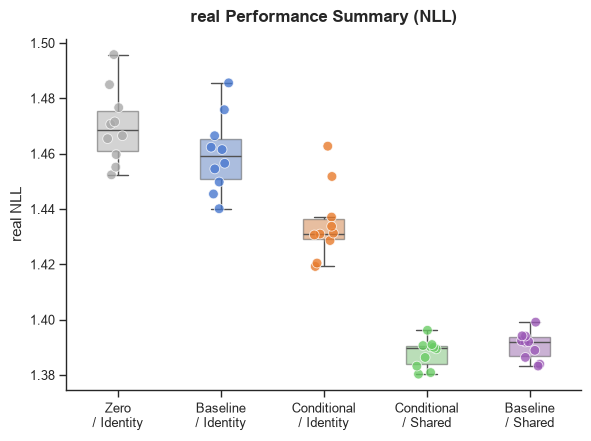

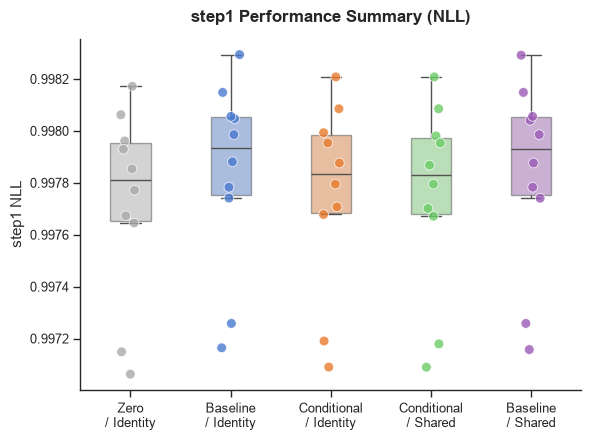

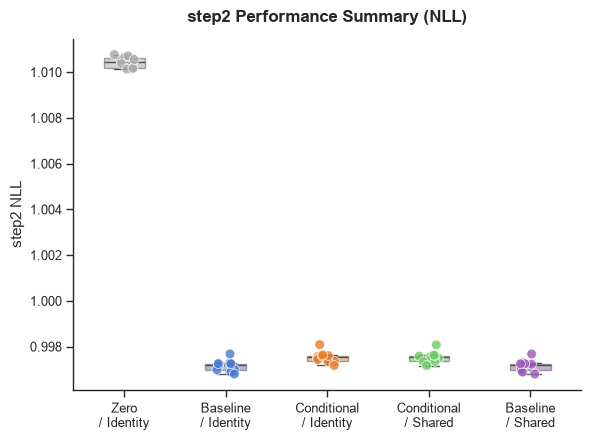

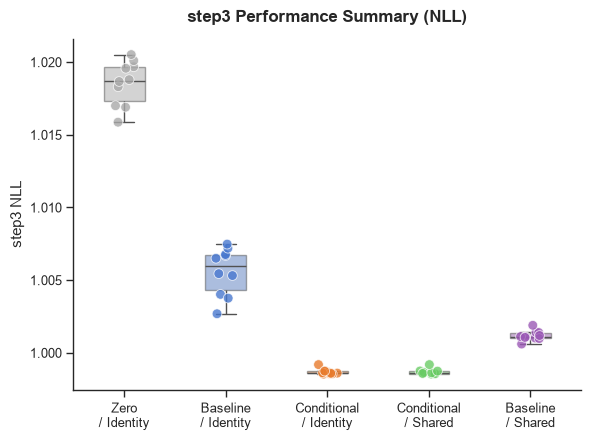

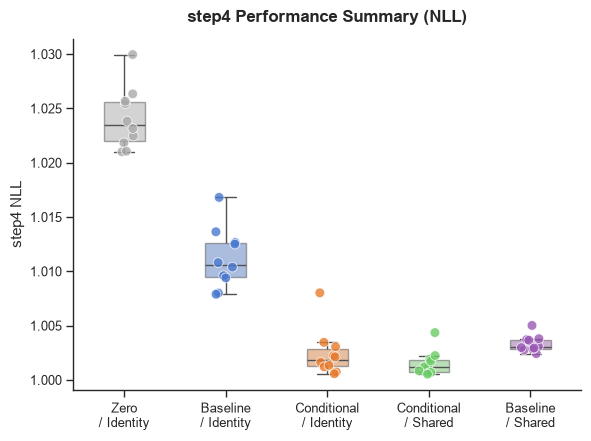

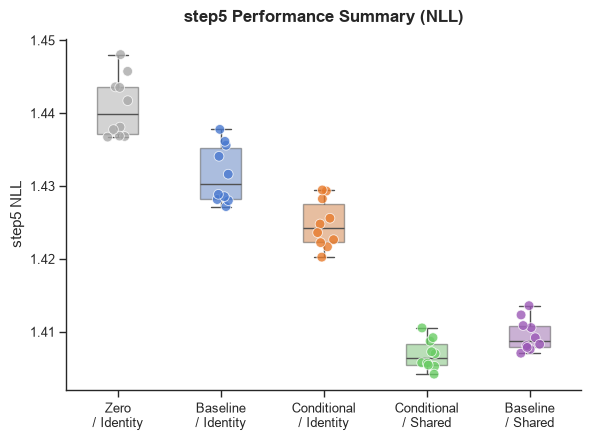

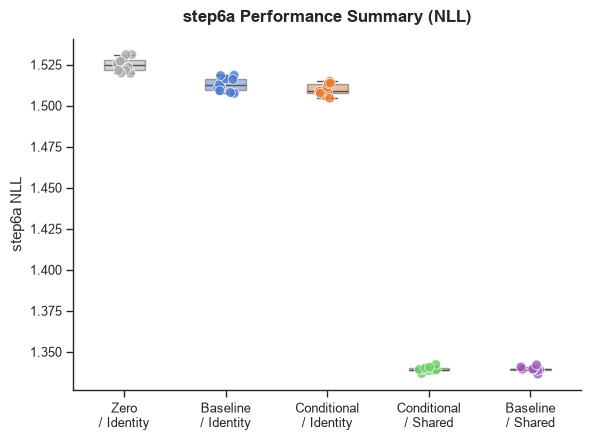

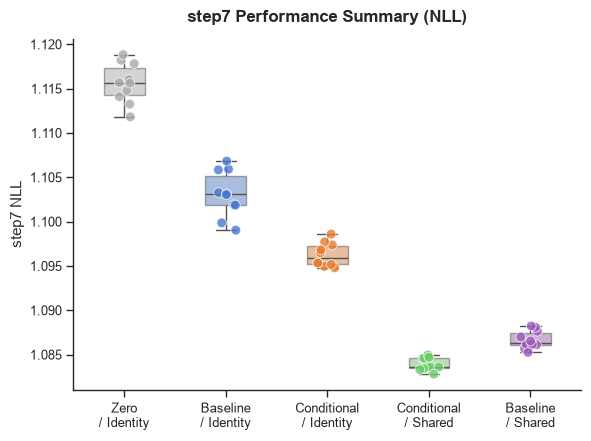

In [96]:
if 'df_history' in locals() and not df_history.empty:
    # Optional but recommended: Sort by epoch to ensure .last() gets the final training step
    # (Change 'epoch' if your step column is named differently, like 'step')
    if 'epoch' in df_history.columns:
        df_history = df_history.sort_values(by=['condition', 'model', 'fold', 'epoch'])

    for condition in df_history['condition'].unique():
        cond_hist = df_history[df_history['condition'] == condition]
        
        # Get the LAST validation NLL for each fold and model (using .last() instead of .min())
        last_nll = cond_hist.groupby(['model', 'fold'], as_index=False)['valid_loss_epoch'].last()
        
        # Rename the columns to match what plot_step_boxplot expects
        last_nll = last_nll.rename(columns={'model': 'model_label', 'valid_loss_epoch': 'nll'})
        os.makedirs(FIGURES + f"{condition}/boxplot/", exist_ok=True)
        plot_step_boxplot(
            df_step=last_nll, 
            step_name=condition, 
            metric='nll', 
            # Updated the filename to reflect it's the last epoch
            save_path=FIGURES + f"{condition}/boxplot/boxplot_{condition}_nll_folds_last.png" 
        )


In [97]:
if 'df_units' in locals() and not df_units.empty:
    print("--- Comparing Models for each Condition (Wilcoxon Heatmap & Bootstrap Estimation Forest) ---")
    available_metrics = [m for m in ['pearson', 'r2', 'mse'] if m in df_units.columns]
    
    for condition in df_units['condition'].unique():
        os.makedirs(FIGURES + f"{condition}/stats/", exist_ok=True)
        for metric in available_metrics:
            # 1. Pairwise Wilcoxon Significance & Directional Cliff's Delta Heatmap
            plot_statistics_heatmap(
                df=df_units, 
                filter_col='condition', 
                filter_val=condition, 
                compare_col='model_label', 
                metric=metric,
                magnitude_threshold='auto',
                correction='fdr_bh',
                save_path=FIGURES + f"{condition}/stats/stats_wilcoxon_{condition}_{metric}.png"
            )
            
            

--- Comparing Models for each Condition (Wilcoxon Heatmap & Bootstrap Estimation Forest) ---
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_pearson.png
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_r2.png
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_mse.png
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_pearson.png
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_r2.png
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_mse.png
Saved -> ./figures_new/step2/stats/stats_wilcoxon_step2_pearson.png
Saved -> ./figures_new/step2/stats/stats_wilcoxon_step2_r2.png
Saved -> ./figures_new/step2/stats/stats_wilcoxon_step2_mse.png
Saved -> ./figures_new/step3/stats/stats_wilcoxon_step3_pearson.png
Saved -> ./figures_new/step3/stats/stats_wilcoxon_step3_r2.png
Saved -> ./figures_new/step3/stats/stats_wilcoxon_step3_mse.png
Saved -> ./figures_new/step4/stats/stats_wilcoxon_step4_pearson.png
Saved -> ./figures_new/step4/stats/stats_wilcoxon_step4_r2.png
Sa

In [29]:
if 'df_units' in locals() and not df_units.empty:
    print("=== Running Pairwise Wilcoxon Comparisons ===")
    
    # Identify available metrics in df_units
    available_metrics = [m for m in ['pearson', 'r2', 'mse'] if m in df_units.columns]
    
    for condition in df_units['condition'].unique():
        os.makedirs(FIGURES + f"{condition}/stats/", exist_ok=True)
        print(f"\n--- Condition: {condition} ---")
        
        for metric in available_metrics:
            print(f"  Computing statistics for metric: {metric.upper()}...")
            
            # 1. Pairwise Statistical Significance & Paired Mean Difference Heatmap (Wilcoxon + FDR)
            plot_statistics_heatmap(
                df=df_units, 
                filter_col='condition', 
                filter_val=condition, 
                compare_col='model_label', 
                metric=metric,
                alpha=0.05,
                correction='fdr_bh',           # 'fdr_bh' | 'bonferroni' | None
                magnitude_threshold='auto',    # 0.015 for pearson, 0.01 for r2/mse
                save_path=FIGURES + f"{condition}/stats/stats_wilcoxon_{condition}_{metric}.png"
            )

            

=== Running Pairwise Wilcoxon Comparisons ===

--- Condition: real ---
  Computing statistics for metric: PEARSON...
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_pearson.png
  Computing statistics for metric: R2...
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_r2.png
  Computing statistics for metric: MSE...
Saved -> ./figures_new/real/stats/stats_wilcoxon_real_mse.png

--- Condition: step1 ---
  Computing statistics for metric: PEARSON...
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_pearson.png
  Computing statistics for metric: R2...
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_r2.png
  Computing statistics for metric: MSE...
Saved -> ./figures_new/step1/stats/stats_wilcoxon_step1_mse.png

--- Condition: step2 ---
  Computing statistics for metric: PEARSON...
Saved -> ./figures_new/step2/stats/stats_wilcoxon_step2_pearson.png
  Computing statistics for metric: R2...
Saved -> ./figures_new/step2/stats/stats_wilcoxon_step2_r2.png
  Computing stati

--- Generating Traffic-Light Summaries ---
Saved -> ./figures_new/real/summary/summary_heatmap_real.png


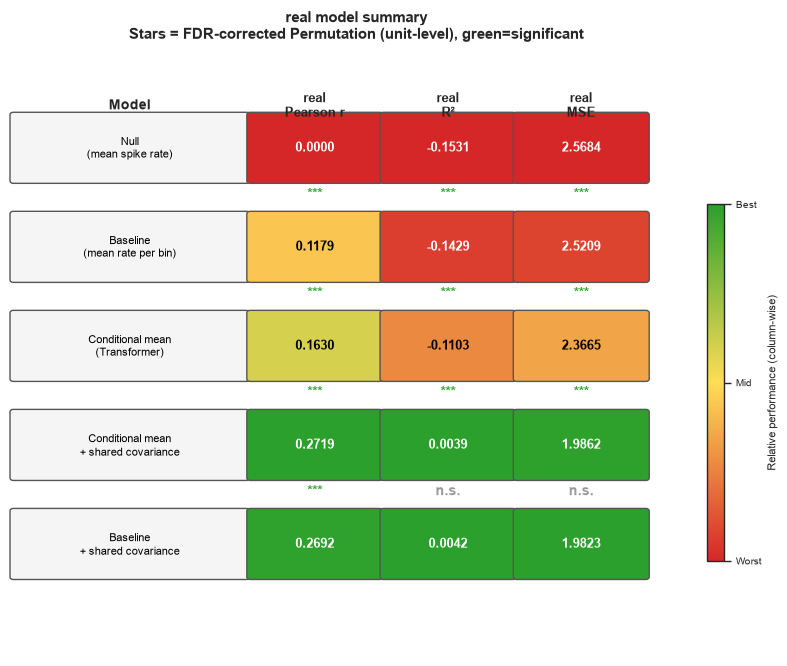

Saved -> ./figures_new/step1/summary/summary_heatmap_step1.png


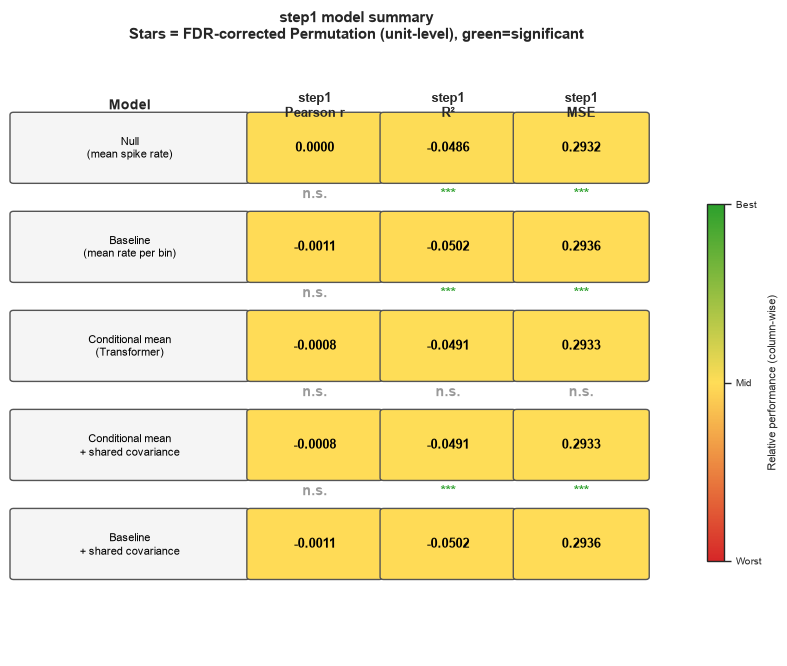

Saved -> ./figures_new/step2/summary/summary_heatmap_step2.png


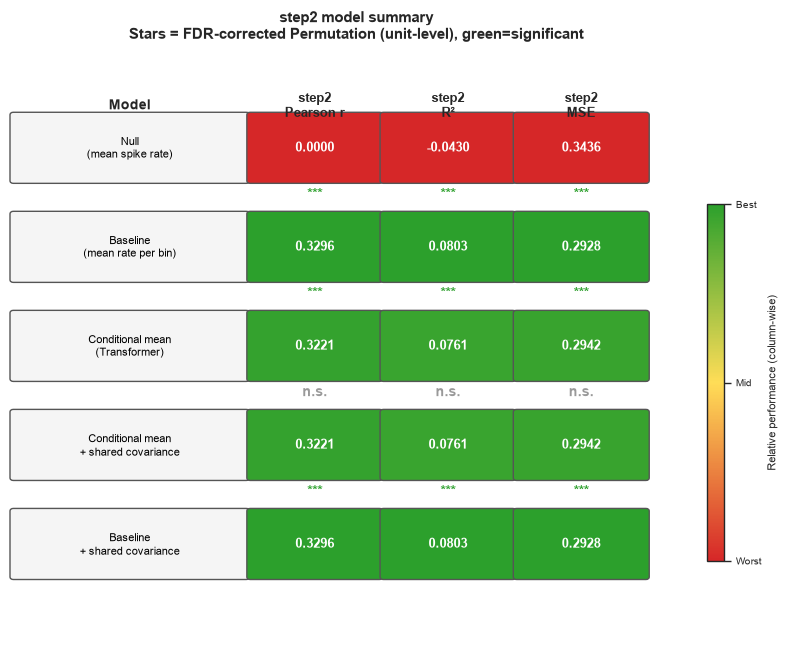

Saved -> ./figures_new/step3/summary/summary_heatmap_step3.png


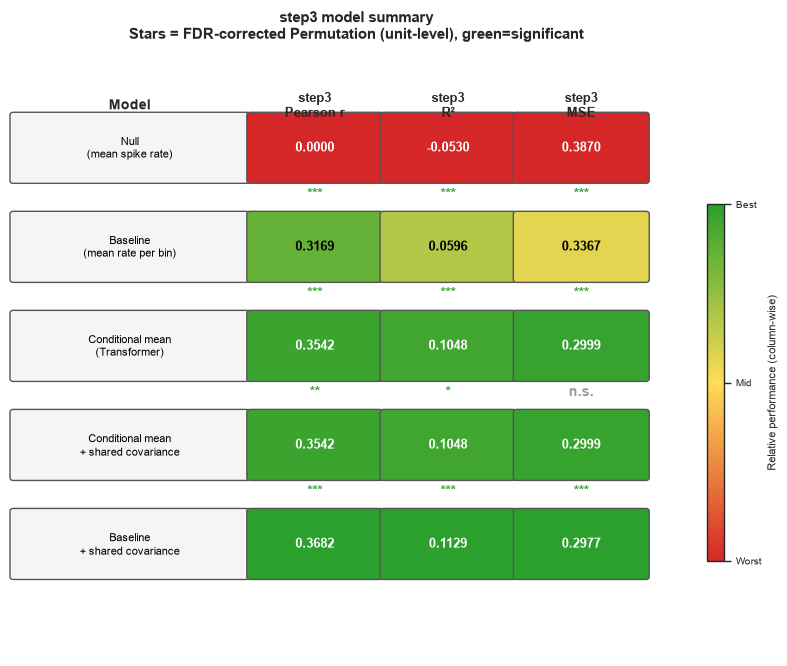

Saved -> ./figures_new/step4/summary/summary_heatmap_step4.png


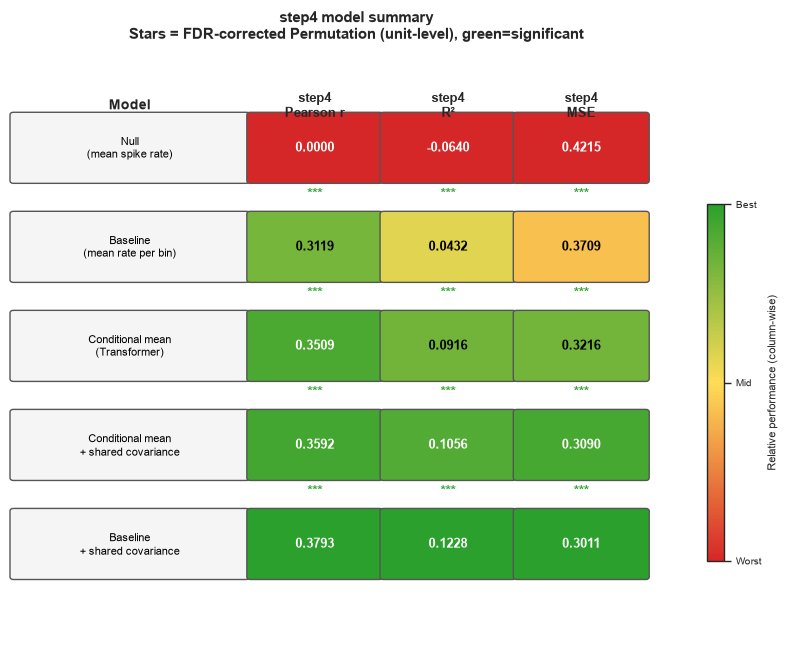

Saved -> ./figures_new/step5/summary/summary_heatmap_step5.png


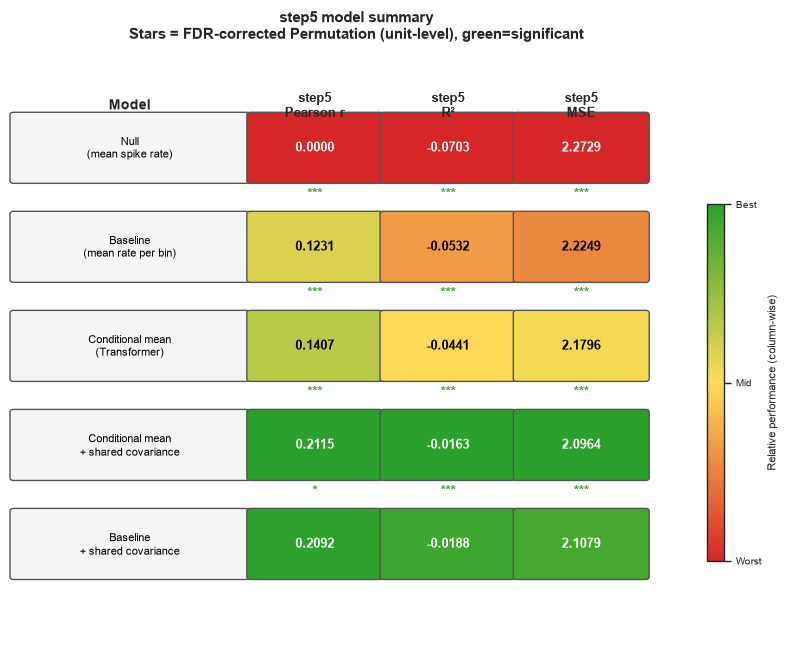

Saved -> ./figures_new/step6a/summary/summary_heatmap_step6a.png


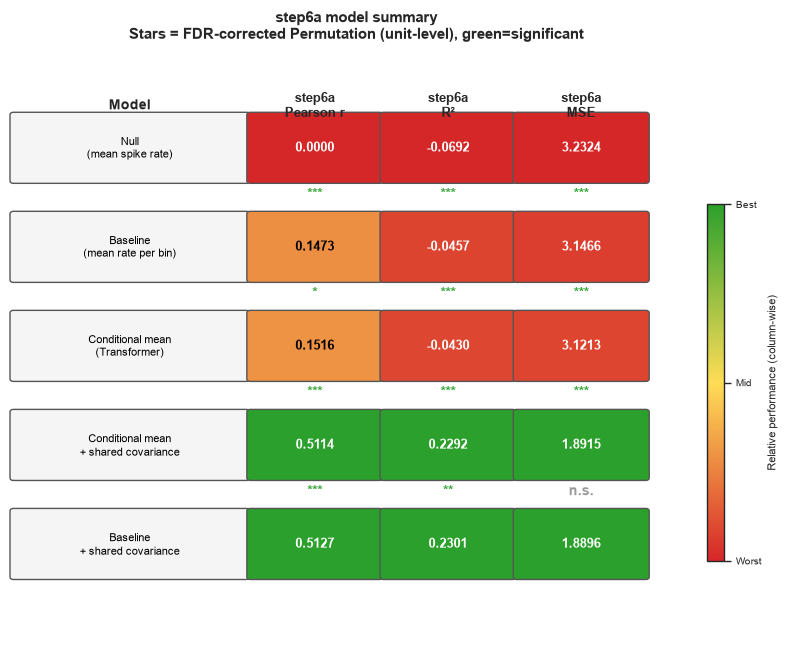

Saved -> ./figures_new/step7/summary/summary_heatmap_step7.png


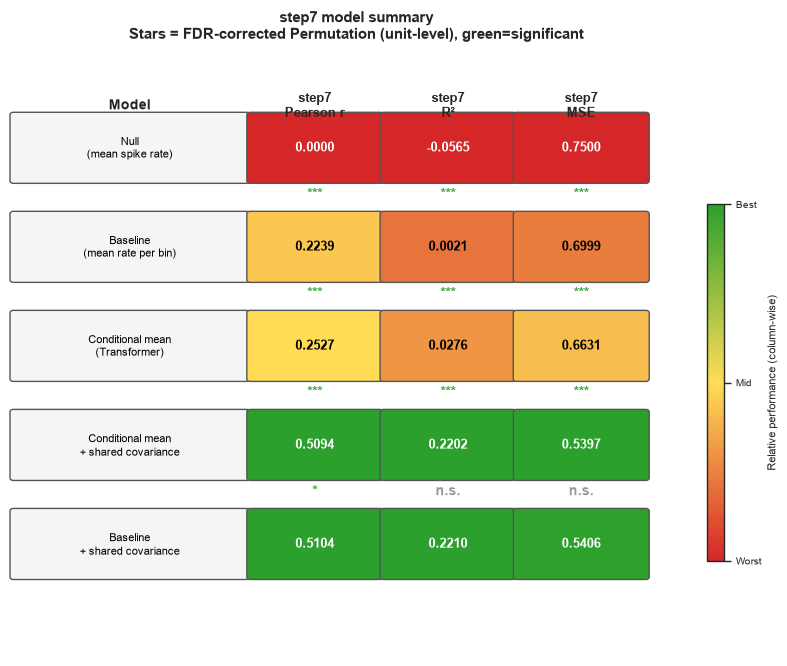

In [98]:
if 'df_units' in locals() and not df_units.empty:
    print("--- Generating Traffic-Light Summaries ---")
    
    for condition in df_units['condition'].unique():
        # 1. Filter to the specific condition
        cond_df = df_units[df_units['condition'] == condition]
        
        # 2. Safely figure out which metrics we actually have in our dataframe
        # (This prevents crashes if 'r2' or 'nll' are missing)
        available_metrics = [m for m in ['pearson', 'r2', 'mse'] if m in cond_df.columns]
        os.makedirs(FIGURES + f"{condition}/summary/", exist_ok=True)
        # 3. Call your traffic-light summary function!
        plot_step_model_summary(
            df=cond_df, 
            step_name=condition, 
            metrics=available_metrics,
            save_path=FIGURES + f"{condition}/summary/summary_heatmap_{condition}.png"
        )


--- Generating Global Model x Condition Heatmaps ---
Saved -> ./figures_new/heatmap_Models_x_Conditions_pearson.png


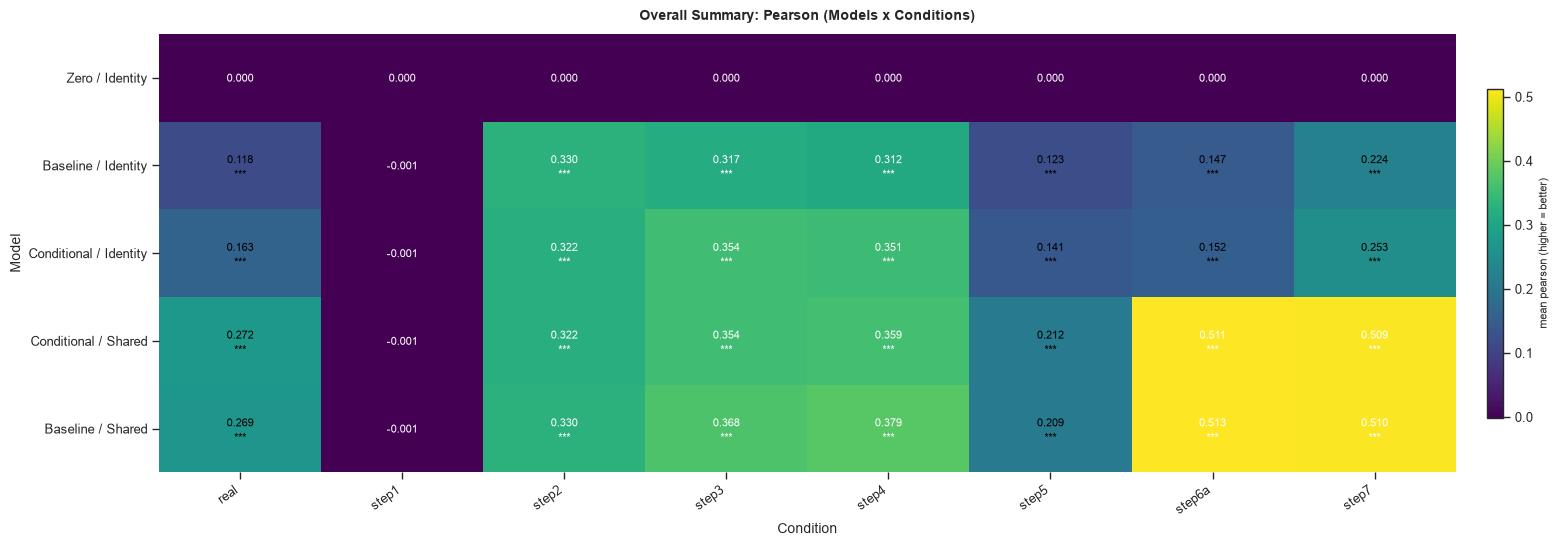

Saved -> ./figures_new/heatmap_Models_x_Conditions_mse.png


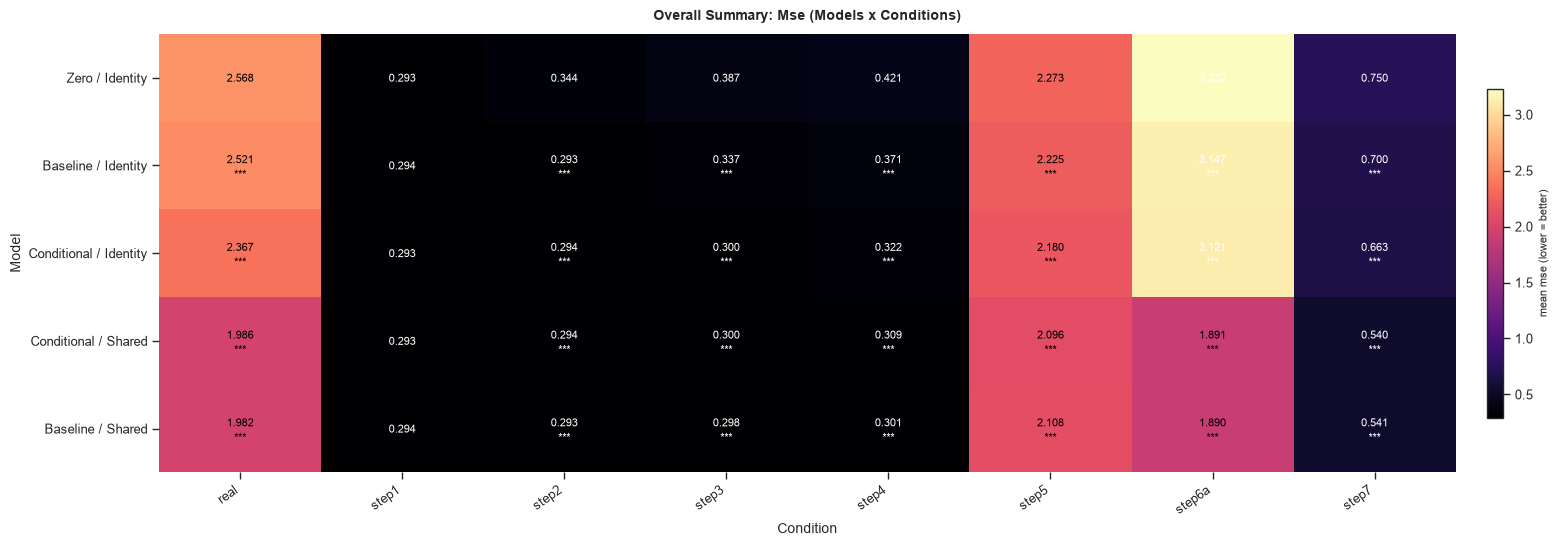

Saved -> ./figures_new/heatmap_Models_x_Conditions_r2.png


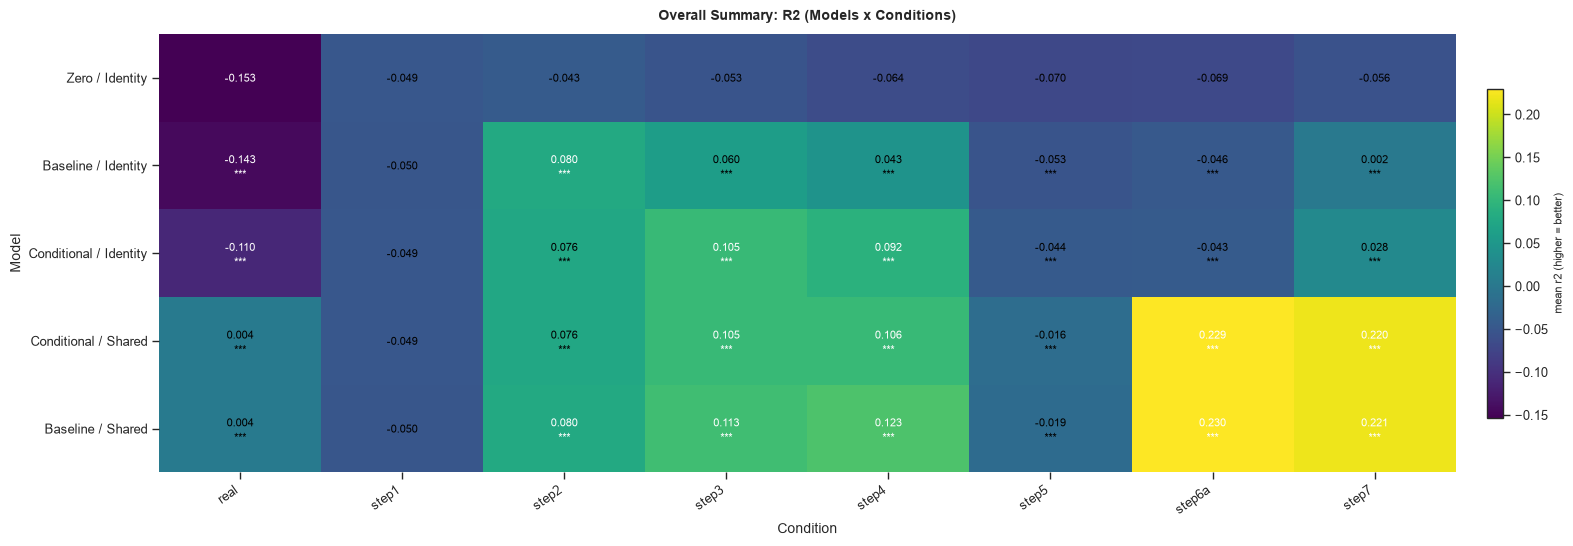

In [99]:
if 'df_units' in locals() and not df_units.empty:
    print("--- Generating Global Model x Condition Heatmaps ---")
    
    available_metrics = [m for m in ['pearson', 'mse', 'r2'] if m in df_units.columns]
    
    for metric in available_metrics:
        
        col_map = "viridis" if metric in ['pearson', 'r2'] else "magma"
        
        plot_metric_heatmap(
            df=df_units,
            metric=metric,
            model_col="model_label",
            condition_col="condition",
            save_path=FIGURES + f"heatmap_Models_x_Conditions_{metric}.png",
            magnitude_threshold=0.05,
            cmap=col_map,
            title=f"Overall Summary: {metric.capitalize()} (Models x Conditions)"
        )


Evaluating Step 6a Covariance Recovery...


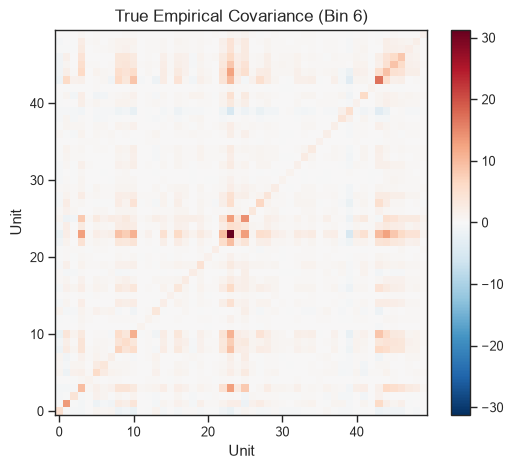

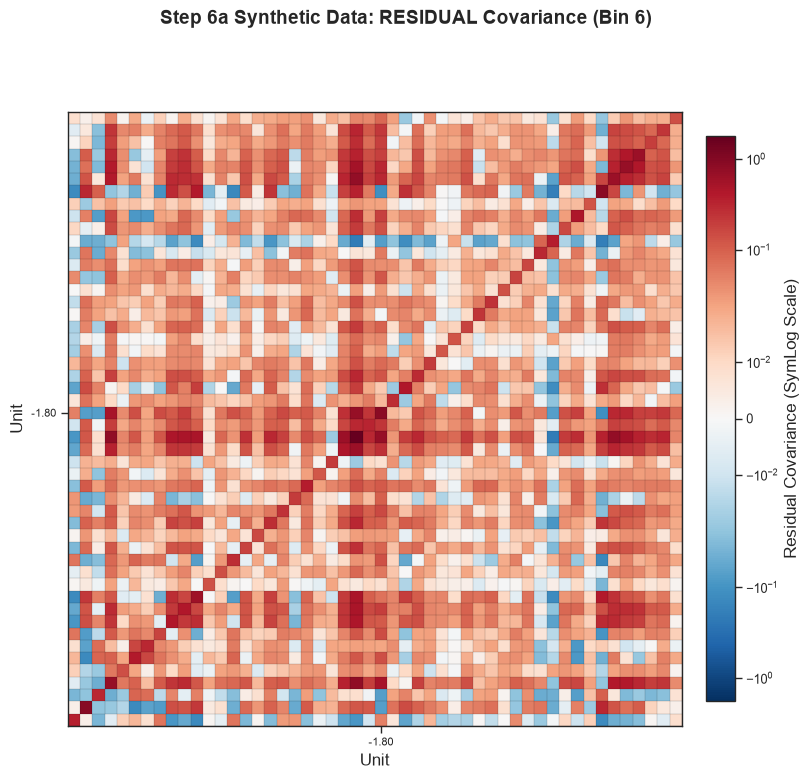

In [32]:
# @title Evaluate Step 6a Covariance Recovery
import matplotlib.pyplot as plt

# We need the trained SharedCovModel for step6a to extract its learned covariance.
# Since run_model_comparisons saves the models, we can load the step6a Shared model.

import os
import torch

def evaluate_step6a_recovery(df_history, empirical_covs, K, N):
    print("Evaluating Step 6a Covariance Recovery...")
    
    # We plot the empirical covariance for Bin 5 as an example
    bin_idx = min(6, K - 1)
    true_cov = empirical_covs[bin_idx]
    
    # In a full implementation, you would load the trained SharedCovModel checkpoint
    # for condition='step6a' and extract its lambda_matrix parameter.
    # Since run_model_comparisons is a black box here, we can visualize the True Covariance
    # that we injected, and print instructions for model extraction.
    
    fig, axes = plt.subplots(1, 1, figsize=(6, 5))
    im = axes.imshow(true_cov, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-np.max(np.abs(true_cov)), vmax=np.max(np.abs(true_cov)))
    axes.set_title(f"True Empirical Covariance (Bin {bin_idx})")
    axes.set_xlabel("Unit")
    axes.set_ylabel("Unit")
    fig.colorbar(im, ax=axes)
    plt.show()

evaluate_step6a_recovery(df_history, empirical_covs, prep['counts'].shape[2], prep['counts'].shape[1]);

plot_residual_covariance(
    Y_synth=training_datasets['step6a'], 
    lambda_hat=lambda_hat_3, 
    title="Step 6a Synthetic Data: RESIDUAL Covariance (Bin 6)", 
    mode='unit',
    time_bin=6,                 
    bin_times=prep['bin_centers']
)

